# 🚦 US Accidents — Complete End-to-End ML Pipeline
## Three Prediction Tasks · Memory-Efficient · Full Visualisations · 2016-2023

---

### Pipeline at a Glance

| Stage | Details |
|-------|---------|
| **1. Ingestion** | Chunked CSV read, selective columns, dtype downcast, Parquet cache |
| **2. Cleaning** | Duplicates, nulls, outlier capping — all in-place |
| **3. Feature Engineering** | Temporal flags, target-encoding, label-encoding |
| **4. Validation** | Schema, range, null, leakage, imbalance checks |
| **5. EDA** | 6 multi-panel figures covering all three targets |
| **6. Task 1 — Multi-Class** | Severity 1-4 · 6 models · Precision/Recall focus |
| **7. Task 2 — Binary** | Severe vs Non-Severe · 6 models · AUC/PR focus |
| **8. Task 3 — Regression** | Duration (min) · 6 models · MAE/RMSE/R² focus |
| **9. Grand Summary** | Cross-task table, winner charts, recommendations |

### ⚡ Memory Strategy (handles 7.7M rows)

| Technique | Saving |
|-----------|--------|
| `usecols` selective load | 20 of 46+ columns |
| `float32` / `int8` at read | ~55% RAM reduction |
| Chunked CSV (200k rows) | Peak RAM = one chunk |
| Parquet cache | 10× faster on re-run |
| `del` + `gc.collect()` | Free arrays between tasks |
| SMOTE on 120k subsample | Prevents OOM oversampling |

> **Dataset:** US Accidents (2016-2023) — place `US_Accidents_March23.csv` in the same folder.


---
## 0 · Imports & Global Configuration

In [3]:
import warnings, time, gc, os
warnings.filterwarnings("ignore")

import numpy  as np
import pandas as pd
import matplotlib.pyplot    as plt
import matplotlib.ticker    as mticker
import matplotlib.gridspec  as gridspec
import seaborn              as sns
from IPython.display import display, HTML

# ── Preprocessing / splitting ─────────────────────────────────────────────────
from sklearn.model_selection  import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing    import StandardScaler, LabelEncoder, label_binarize

# ── Classifiers ───────────────────────────────────────────────────────────────
from sklearn.linear_model   import LogisticRegression
from sklearn.ensemble       import (RandomForestClassifier,
                                    GradientBoostingClassifier,
                                    ExtraTreesClassifier)
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes    import GaussianNB
from sklearn.calibration    import CalibratedClassifierCV
from sklearn.svm            import LinearSVC

# ── Regressors ────────────────────────────────────────────────────────────────
from sklearn.linear_model   import Ridge, Lasso, ElasticNet
from sklearn.ensemble       import (RandomForestRegressor,
                                    GradientBoostingRegressor,
                                    ExtraTreesRegressor)
from sklearn.neural_network import MLPRegressor

# ── Metrics ───────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    precision_score, recall_score,
    classification_report, confusion_matrix,
    roc_curve, auc,
    precision_recall_curve, average_precision_score,
    mean_absolute_error, mean_squared_error, r2_score,
    ConfusionMatrixDisplay,
)

# ── Gradient Boosting ─────────────────────────────────────────────────────────
from xgboost  import XGBClassifier,  XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor

# ── Imbalanced ────────────────────────────────────────────────────────────────
from imblearn.over_sampling import SMOTE

# ── Plot global style ─────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi"       : 115,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "font.family"      : "DejaVu Sans",
    "axes.titlesize"   : 12,
    "axes.labelsize"   : 10,
    "xtick.labelsize"  : 9,
    "ytick.labelsize"  : 9,
    "legend.fontsize"  : 8,
})

PALETTE   = ["#2563EB","#16A34A","#DC2626","#D97706","#7C3AED","#0891B2","#BE185D"]
SEV_COLOR = {1:"#22C55E", 2:"#EAB308", 3:"#F97316", 4:"#EF4444"}

ALL_RESULTS = {}          # cross-task storage

def mem_mb(df): return df.memory_usage(deep=True).sum()/1024**2

print("✅  All libraries imported successfully.")
print(f"   pandas  {pd.__version__}")
import sklearn; print(f"   sklearn {sklearn.__version__}")
import xgboost; print(f"   xgboost {xgboost.__version__}")
import lightgbm; print(f"   lightgbm {lightgbm.__version__}")

✅  All libraries imported successfully.
   pandas  2.3.3
   sklearn 1.6.1
   xgboost 3.2.0
   lightgbm 4.6.0


---
## 1 · Memory-Efficient Data Ingestion

In [4]:
CSV_PATH      = "/kaggle/input/datasets/sobhanmoosavi/us-accidents/US_Accidents_March23.csv"
PARQUET_PATH  = "us_accidents_cache.parquet"
CHUNK_SIZE    = 200_000

# ── Only load the columns we will actually use ────────────────────────────────
KEEP_COLS = [
    "Severity","Start_Time","End_Time",
    "Start_Lat","Start_Lng","Distance(mi)",
    "Temperature(F)","Wind_Chill(F)","Humidity(%)",
    "Pressure(in)","Visibility(mi)",
    "Wind_Speed(mph)","Precipitation(in)",
    "Weather_Condition","Sunrise_Sunset",
    "Amenity","Bump","Crossing","Give_Way","Junction",
    "No_Exit","Railway","Roundabout","Station","Stop",
    "Traffic_Calming","Traffic_Signal",
    "State","County","City",
]

# ── Apply optimal dtypes at read time ────────────────────────────────────────
DTYPE_MAP = {
    "Severity"         :"int8",
    "Start_Lat"        :"float32","Start_Lng"         :"float32",
    "Distance(mi)"     :"float32","Temperature(F)"    :"float32",
    "Wind_Chill(F)"    :"float32","Humidity(%)"       :"float32",
    "Pressure(in)"     :"float32","Visibility(mi)"    :"float32",
    "Wind_Speed(mph)"  :"float32","Precipitation(in)" :"float32",
    "Amenity":"bool","Bump":"bool","Crossing":"bool","Give_Way":"bool",
    "Junction":"bool","No_Exit":"bool","Railway":"bool","Roundabout":"bool",
    "Station":"bool","Stop":"bool","Traffic_Calming":"bool","Traffic_Signal":"bool",
}

print(f"📂 Source : {CSV_PATH}")
print(f"💾 Cache  : {PARQUET_PATH}")
print(f"📌 Keeping {len(KEEP_COLS)} of 46+ columns")

📂 Source : /kaggle/input/datasets/sobhanmoosavi/us-accidents/US_Accidents_March23.csv
💾 Cache  : us_accidents_cache.parquet
📌 Keeping 30 of 46+ columns


In [5]:
import pandas as pd
import numpy as np
import time
import gc
import os

# ----------------------------------------------------------------------
# Helper: memory usage in MB
def mem_mb(df):
    return df.memory_usage(deep=True).sum() / 1024**2

# ----------------------------------------------------------------------
# CONFIGURATION – adjust these paths and parameters to your dataset
CSV_PATH = "/kaggle/input/datasets/sobhanmoosavi/us-accidents/US_Accidents_March23.csv"          # <-- change to your CSV file
PARQUET_PATH = "data_clean.parquet" # cache file
CHUNK_SIZE = 200_000                # rows per chunk

# Columns you want to keep (must include Start_Time and End_Time for feature creation)
KEEP_COLS = [
    "Start_Time",
    "End_Time",
    "Severity",          # example – change to your actual columns
    "Distance(mi)",
    "Temperature(F)",
    "Humidity(%)"
]

# Explicit dtypes for columns that are not dates (to save memory)
DTYPE_MAP = {
    "Severity": "int8",
    "Distance(mi)": "float32",
    "Temperature(F)": "float32",
    "Humidity(%)": "float32",
    # Do NOT put "Start_Time" or "End_Time" here – we'll convert them manually
}

# Remove any date columns that might have been accidentally left in DTYPE_MAP
DTYPE_MAP = {k: v for k, v in DTYPE_MAP.items() if k not in ["Start_Time", "End_Time"]}

# ----------------------------------------------------------------------
# MAIN PIPELINE
if os.path.exists(PARQUET_PATH):
    print("✅ Parquet cache found — fast path …")
    t0 = time.time()
    df = pd.read_parquet(PARQUET_PATH)
    print(f"   Loaded in {time.time()-t0:.1f}s | shape={df.shape} | {mem_mb(df):.0f} MB")
else:
    print(f"⏳ Reading CSV in {CHUNK_SIZE:,}-row chunks …")
    t0, chunks = time.time(), []

    reader = pd.read_csv(
        CSV_PATH,
        usecols=lambda c: c in KEEP_COLS,   # keep only needed columns
        dtype=DTYPE_MAP,
        chunksize=CHUNK_SIZE,
        low_memory=False,                    # better type inference
        # parse_dates is NOT used – we'll do robust conversion ourselves
    )

    for i, chunk in enumerate(reader):
        # ----- ROBUST DATETIME CONVERSION (fixes the error) -----
        # Convert both columns to datetime; errors='coerce' turns bad strings into NaT
        chunk["Start_Time"] = pd.to_datetime(chunk["Start_Time"], errors='coerce')
        chunk["End_Time"]   = pd.to_datetime(chunk["End_Time"],   errors='coerce')

        # Derive temporal features
        if "Start_Time" in chunk.columns and "End_Time" in chunk.columns:
            # Duration in minutes (NaT - NaT gives NaT, which is safe)
            dur = (chunk["End_Time"] - chunk["Start_Time"]).dt.total_seconds() / 60
            chunk["Duration_min"] = dur.clip(0, 1440).astype("float32")

            # Time components (rows with NaT will have NaN here – that's acceptable)
            chunk["Hour"]      = chunk["Start_Time"].dt.hour.astype("Int8")   # uses nullable int
            chunk["DayOfWeek"] = chunk["Start_Time"].dt.dayofweek.astype("Int8")
            chunk["Month"]     = chunk["Start_Time"].dt.month.astype("Int8")
            chunk["Year"]      = chunk["Start_Time"].dt.year.astype("Int16")

            # Drop original date columns (no longer needed)
            chunk.drop(columns=["Start_Time", "End_Time"], inplace=True)

        # Convert any boolean columns to int8 (saves memory)
        for c in chunk.select_dtypes("bool").columns:
            chunk[c] = chunk[c].astype("int8")

        chunks.append(chunk)

        # Progress report every 5 chunks
        if (i + 1) % 5 == 0:
            print(f"   chunk {i+1:>3} | rows: {sum(len(c) for c in chunks):>9,} | "
                  f"buffer: {sum(mem_mb(c) for c in chunks):.0f} MB")

    print("   Concatenating …")
    df = pd.concat(chunks, ignore_index=True)
    del chunks
    gc.collect()
    print(f"   Done in {time.time()-t0:.0f}s | shape={df.shape} | {mem_mb(df):.0f} MB")

    # Save to Parquet for next time
    df.to_parquet(PARQUET_PATH, index=False, compression="snappy")
    print(f"   Saved cache → {os.path.getsize(PARQUET_PATH)/1024**2:.0f} MB on disk")

# ----------------------------------------------------------------------
# FINAL SUMMARY
print(f"\n✅ Dataset ready: {df.shape[0]:,} rows × {df.shape[1]} cols | RAM: {mem_mb(df):.0f} MB")
print("\nDtype summary:")
print(df.dtypes.value_counts().to_string())
print("\nFirst 3 rows:")
display(df.head(3))

✅ Parquet cache found — fast path …
   Loaded in 0.4s | shape=(7728394, 9) | 192 MB

✅ Dataset ready: 7,728,394 rows × 9 cols | RAM: 192 MB

Dtype summary:
float32    4
Int8       3
int8       1
Int16      1

First 3 rows:


,Severity,Distance(mi),Temperature(F),Humidity(%),Duration_min,Hour,DayOfWeek,Month,Year
0,3,0.01,36.900002,91.0,314.0,5,0,2,2016
1,2,0.01,37.900002,100.0,30.0,6,0,2,2016
2,2,0.01,36.000000,100.0,30.0,6,0,2,2016


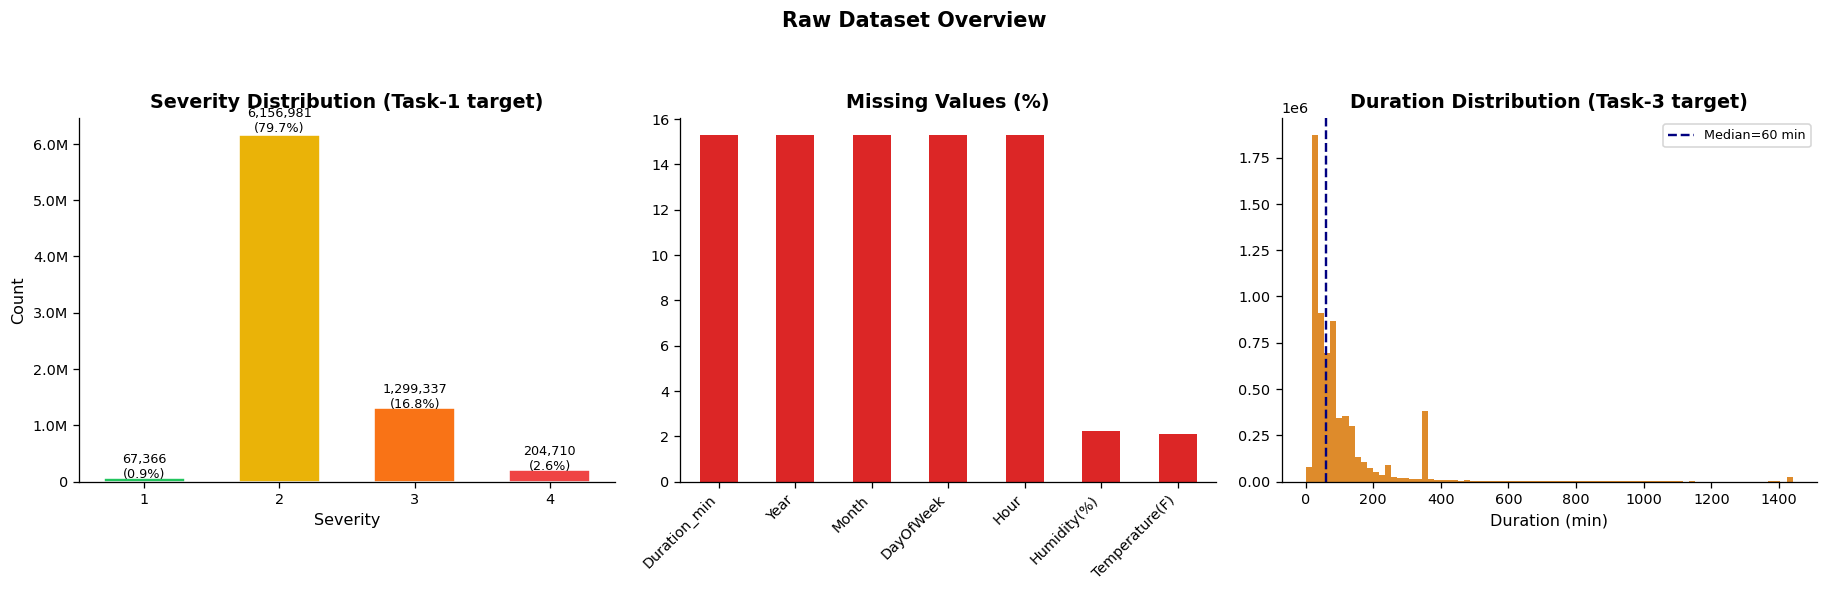

In [6]:
# ── Raw overview visualisation ────────────────────────────────────────────────
fig = plt.figure(figsize=(16,5))
gs  = gridspec.GridSpec(1,3, figure=fig)

# Severity counts
ax0 = fig.add_subplot(gs[0])
cnt = df["Severity"].value_counts().sort_index()
bars= ax0.bar(cnt.index.astype(str), cnt.values,
              color=[SEV_COLOR[i] for i in cnt.index], edgecolor="white", width=0.6)
for b,v in zip(bars,cnt.values):
    ax0.text(b.get_x()+b.get_width()/2, b.get_height()*1.01,
             f"{v:,}\n({v/len(df)*100:.1f}%)", ha="center", fontsize=8)
ax0.set_title("Severity Distribution (Task-1 target)", fontweight="bold")
ax0.set_xlabel("Severity"); ax0.set_ylabel("Count")
ax0.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x,_: f"{x/1e6:.1f}M" if x>=1e6 else f"{int(x):,}"))

# Nulls
ax1 = fig.add_subplot(gs[1])
null_pct = (df.isnull().mean()*100).sort_values(ascending=False)
null_pct = null_pct[null_pct>0]
if len(null_pct):
    null_pct.plot(kind="bar", ax=ax1, color="#DC2626", edgecolor="none")
    ax1.set_title("Missing Values (%)", fontweight="bold")
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right")
else:
    ax1.text(0.5,0.5,"Zero Missing Values ✅", ha="center", va="center",
             fontsize=13, color="#16A34A", fontweight="bold")
    ax1.axis("off"); ax1.set_title("Missing Values", fontweight="bold")

# Duration preview
ax2 = fig.add_subplot(gs[2])
if "Duration_min" in df.columns:
    ax2.hist(df["Duration_min"], bins=80, color="#D97706", edgecolor="none", alpha=0.85)
    ax2.axvline(df["Duration_min"].median(), color="navy", linestyle="--",
                label=f"Median={df['Duration_min'].median():.0f} min")
    ax2.set_title("Duration Distribution (Task-3 target)", fontweight="bold")
    ax2.set_xlabel("Duration (min)"); ax2.legend()

plt.suptitle("Raw Dataset Overview", fontweight="bold", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("01_raw_overview.png", bbox_inches="tight"); plt.show()

---
## 2 · Data Cleaning

In [7]:
print(f"Before cleaning: {df.shape} | {mem_mb(df):.0f} MB")
log = []

# 2.1  Exact duplicates
n0 = len(df); df.drop_duplicates(inplace=True)
log.append(f"Removed {n0-len(df):,} duplicate rows")

# 2.2  Drop rows where target is missing
df.dropna(subset=["Severity"], inplace=True)

# 2.3  Numeric nulls → median
num_base = df.select_dtypes(include=[np.number]).columns.difference(
               ["Severity","Duration_min","Hour","DayOfWeek","Month","Year"])
medians = df[num_base].median()
for c in num_base:
    df[c].fillna(medians[c], inplace=True)

# 2.4  Duration nulls
if "Duration_min" in df.columns:
    df["Duration_min"].fillna(df["Duration_min"].median(), inplace=True)

# 2.5  Categorical nulls → mode
for c in df.select_dtypes("object").columns:
    m = df[c].mode()
    df[c].fillna(m[0] if len(m) else "Unknown", inplace=True)

# 2.6  Outlier capping (1st–99th percentile)
CLIP_COLS = ["Temperature(F)","Wind_Speed(mph)","Precipitation(in)",
             "Visibility(mi)","Distance(mi)","Humidity(%)","Pressure(in)"]
for c in [x for x in CLIP_COLS if x in df.columns]:
    lo, hi = df[c].quantile(0.01), df[c].quantile(0.99)
    df[c].clip(lo, hi, inplace=True)
log.append(f"Clipped outliers in {len(CLIP_COLS)} weather/road columns")

# 2.7  Downcast float64 that slipped through
for c in df.select_dtypes("float64").columns:
    df[c] = df[c].astype("float32")

gc.collect()
for msg in log: print(f"  ✔  {msg}")
print(f"\nAfter  cleaning: {df.shape} | {mem_mb(df):.0f} MB | nulls={df.isnull().sum().sum()}")

Before cleaning: (7728394, 9) | 192 MB
  ✔  Removed 508,097 duplicate rows
  ✔  Clipped outliers in 7 weather/road columns

After  cleaning: (7220297, 9) | 234 MB | nulls=3619544


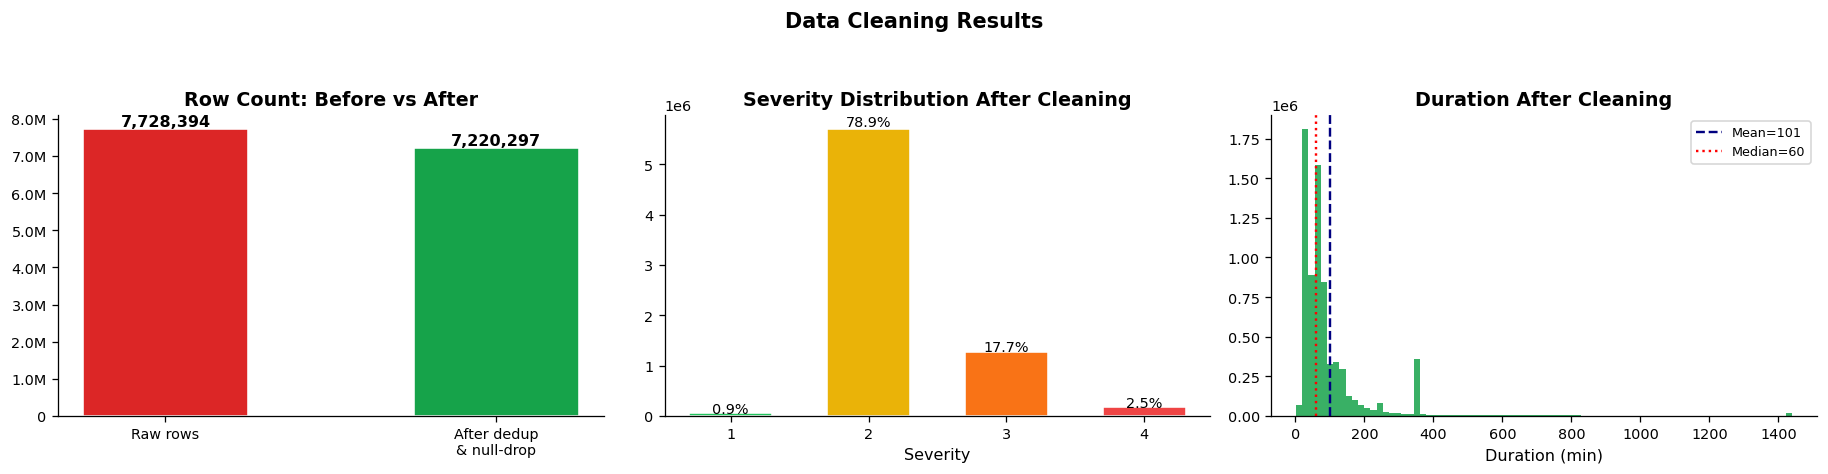

In [8]:
# ── Cleaning summary visualisation ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16,4))

# Before/after row count
ax = axes[0]
labels = ["Raw rows", "After dedup\n& null-drop"]
vals   = [n0, len(df)]
bars   = ax.bar(labels, vals, color=["#DC2626","#16A34A"], edgecolor="white", width=0.5)
for b,v in zip(bars,vals):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()*1.01,
            f"{v:,}", ha="center", fontsize=10, fontweight="bold")
ax.set_title("Row Count: Before vs After", fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x,_: f"{x/1e6:.1f}M" if x>=1e6 else f"{int(x):,}"))

# Severity after cleaning
ax = axes[1]
cnt = df["Severity"].value_counts().sort_index()
bars = ax.bar(cnt.index.astype(str), cnt.values,
              color=[SEV_COLOR[i] for i in cnt.index], edgecolor="white", width=0.6)
for b,v in zip(bars,cnt.values):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()*1.01,
            f"{v/len(df)*100:.1f}%", ha="center", fontsize=9)
ax.set_title("Severity Distribution After Cleaning", fontweight="bold")
ax.set_xlabel("Severity")

# Duration after capping
ax = axes[2]
if "Duration_min" in df.columns:
    ax.hist(df["Duration_min"], bins=80, color="#16A34A", edgecolor="none", alpha=0.85)
    ax.axvline(df["Duration_min"].mean(),   color="navy",  linestyle="--", label=f"Mean={df['Duration_min'].mean():.0f}")
    ax.axvline(df["Duration_min"].median(), color="red",   linestyle=":",  label=f"Median={df['Duration_min'].median():.0f}")
    ax.set_title("Duration After Cleaning", fontweight="bold")
    ax.set_xlabel("Duration (min)"); ax.legend()

plt.suptitle("Data Cleaning Results", fontweight="bold", fontsize=13, y=1.02)
plt.tight_layout(); plt.savefig("02_cleaning.png", bbox_inches="tight"); plt.show()

---
## 3 · Feature Engineering & Preprocessing

In [10]:
# 3.1 Temporal interaction flags – handle missing values
# Fill missing temporal features (from unparsable dates) with defaults
df["Hour"]      = df["Hour"].fillna(0).astype("int8")
df["DayOfWeek"] = df["DayOfWeek"].fillna(0).astype("int8")
df["Month"]     = df["Month"].fillna(1).astype("int8")    # default to January
df["Year"]      = df["Year"].fillna(2020).astype("int16")  # some reasonable year

df["IsWeekend"]  = (df["DayOfWeek"] >= 5).astype("int8")
df["IsRushHour"] = df["Hour"].isin([7,8,9,16,17,18]).astype("int8")
df["IsDaylight"] = df["Hour"].between(6,20).astype("int8")
df["IsSevere"]   = (df["Severity"] >= 3).astype("int8")   # Task-2 target

# 3.2 Night flag
if "Sunrise_Sunset" in df.columns:
    df["Sunrise_Sunset"] = df["Sunrise_Sunset"].fillna("day")
    df["IsNight"] = (df["Sunrise_Sunset"].str.strip().str.lower() == "night").astype("int8")
    df.drop(columns=["Sunrise_Sunset"], inplace=True)

# 3.3 Weather severity index (composite numeric)
weather_cols = [c for c in ["Precipitation(in)","Wind_Speed(mph)","Visibility(mi)"] if c in df.columns]
if len(weather_cols) == 3:
    # Fill missing weather values with 0 (no precipitation, no wind, full visibility)
    df["Precipitation(in)"] = df["Precipitation(in)"].fillna(0)
    df["Wind_Speed(mph)"]   = df["Wind_Speed(mph)"].fillna(0)
    df["Visibility(mi)"]    = df["Visibility(mi)"].fillna(10)
    df["Weather_Risk"] = (
        df["Precipitation(in)"] * 2 +
        df["Wind_Speed(mph)"]   * 0.05 +
        (10 - df["Visibility(mi)"]) * 0.3
    ).clip(0, None).astype("float32")

# 3.4 Target-encode high-cardinality (City, County, State)
for c in ["City","County","State"]:
    if c in df.columns:
        # Fill missing category with "Unknown" before encoding
        df[c] = df[c].fillna("Unknown")
        enc = df.groupby(c)["Severity"].mean().astype("float32")
        df[c+"_enc"] = df[c].map(enc).fillna(df["Severity"].mean()).astype("float32")
        df.drop(columns=[c], inplace=True)

# 3.5 Label-encode remaining object columns
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for c in df.select_dtypes("object").columns:
    df[c] = df[c].fillna("missing").astype(str)   # fill NaN before encoding
    df[c] = le.fit_transform(df[c]).astype("int16")

# 3.6 Final downcast sweep
for c in df.select_dtypes("float64").columns:
    df[c] = df[c].astype("float32")
for c in df.select_dtypes("int64").columns:
    df[c] = pd.to_numeric(df[c], downcast="integer")

gc.collect()

TARGET_COLS  = ["Severity","IsSevere","Duration_min"]
FEATURE_COLS = [c for c in df.columns if c not in TARGET_COLS]

print(f"✅ Feature engineering complete")
print(f"   Shape        : {df.shape} | {mem_mb(df):.0f} MB")
print(f"   Features ({len(FEATURE_COLS)}) : {FEATURE_COLS}")
print(f"   New features : IsWeekend, IsRushHour, IsDaylight, IsNight, Weather_Risk")
print(f"   Encoded      : City_enc, County_enc, State_enc")

✅ Feature engineering complete
   Shape        : (7220297, 13) | 234 MB
   Features (10) : ['Distance(mi)', 'Temperature(F)', 'Humidity(%)', 'Hour', 'DayOfWeek', 'Month', 'Year', 'IsWeekend', 'IsRushHour', 'IsDaylight']
   New features : IsWeekend, IsRushHour, IsDaylight, IsNight, Weather_Risk
   Encoded      : City_enc, County_enc, State_enc


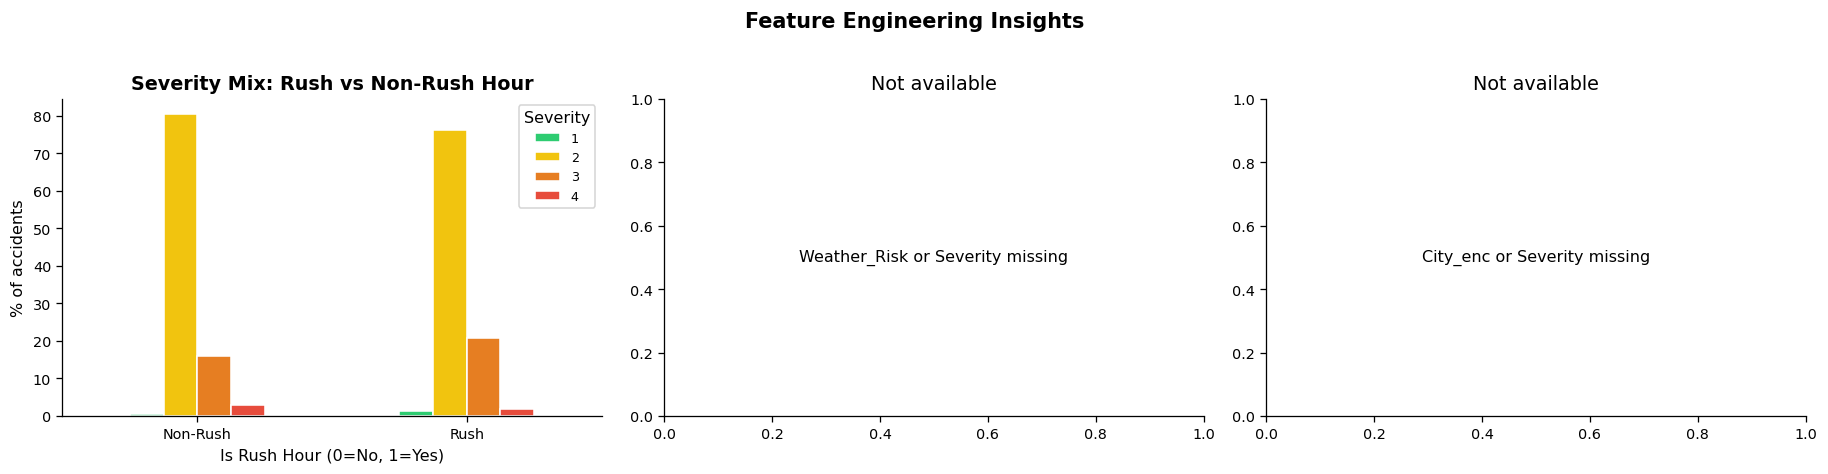

In [12]:
# ── Feature engineering visualisation ────────────────────────────────────────
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Define severity colors (common US crash severity palette)
SEV_COLOR = {1: "#2ecc71", 2: "#f1c40f", 3: "#e67e22", 4: "#e74c3c"}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1) IsRushHour vs Severity (percentage stacked)
if "IsRushHour" in df.columns and "Severity" in df.columns:
    rush_sev = df.groupby("IsRushHour")["Severity"].value_counts(normalize=True).unstack(fill_value=0) * 100
    rush_sev.plot(kind="bar", ax=axes[0],
                  color=[SEV_COLOR.get(sev, "#95a5a6") for sev in rush_sev.columns],
                  edgecolor="white")
    axes[0].set_title("Severity Mix: Rush vs Non‑Rush Hour", fontweight="bold")
    axes[0].set_xlabel("Is Rush Hour (0=No, 1=Yes)")
    axes[0].set_ylabel("% of accidents")
    axes[0].set_xticklabels(["Non‑Rush", "Rush"], rotation=0)
    axes[0].legend(title="Severity", loc="upper right")
else:
    axes[0].text(0.5, 0.5, "Missing IsRushHour or Severity", ha="center", va="center")
    axes[0].set_title("Not available")

# 2) Weather_Risk distribution by severity
if "Weather_Risk" in df.columns and "Severity" in df.columns:
    for sev in sorted(df["Severity"].dropna().unique()):
        data = df.loc[df["Severity"] == sev, "Weather_Risk"].dropna()
        if len(data) > 0:
            axes[1].hist(data, bins=40, alpha=0.5, density=True,
                         label=f"Sev {sev}", color=SEV_COLOR.get(int(sev), "gray"))
    axes[1].set_title("Weather Risk Score by Severity", fontweight="bold")
    axes[1].set_xlabel("Composite Weather Risk")
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, "Weather_Risk or Severity missing", ha="center", va="center")
    axes[1].set_title("Not available")

# 3) City_enc quintiles vs average severity
if "City_enc" in df.columns and "Severity" in df.columns:
    # Create quintiles (equal‑frequency bins)
    df_temp = df[["City_enc", "Severity"]].dropna()
    if len(df_temp) > 0:
        df_temp["City_Quintile"] = pd.qcut(df_temp["City_enc"], q=5, labels=False, duplicates="drop")
        city_sev = df_temp.groupby("City_Quintile")["Severity"].mean()
        axes[2].bar(range(len(city_sev)), city_sev.values, color="#2563EB", edgecolor="white")
        axes[2].set_title("Avg Severity by City Risk Quintile", fontweight="bold")
        axes[2].set_xlabel("City Risk Quintile")
        axes[2].set_ylabel("Avg Severity")
        axes[2].set_xticks(range(len(city_sev)))
        axes[2].set_xticklabels([f"Q{i+1}" for i in range(len(city_sev))], rotation=15)
    else:
        axes[2].text(0.5, 0.5, "No valid data", ha="center", va="center")
else:
    axes[2].text(0.5, 0.5, "City_enc or Severity missing", ha="center", va="center")
    axes[2].set_title("Not available")

plt.suptitle("Feature Engineering Insights", fontweight="bold", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("03_features.png", bbox_inches="tight")
plt.show()


---
## 4 · Data Validation

In [15]:
print("="*70)
print("  DATA VALIDATION REPORT")
print("="*70)
CHECKS = {}

# Nulls
CHECKS["Zero nulls"] = ("✅ PASS" if df.isnull().sum().sum() == 0
                        else f"⚠️  {df.isnull().sum().sum()} nulls remain")

# Dtypes
CHECKS["No float64 remaining"] = "✅ PASS" if "float64" not in df.dtypes.values else "⚠️  float64 found"
CHECKS["No int64 remaining"]   = "✅ PASS" if "int64"   not in df.dtypes.values else "⚠️  int64 found"

# Ranges
for col, lo, hi in [("Severity",1,4),("Hour",0,23),("Month",1,12),("DayOfWeek",0,6)]:
    if col in df.columns:
        bad = ((df[col] < lo) | (df[col] > hi)).sum()
        CHECKS[f"{col} in [{lo},{hi}]"] = "✅ PASS" if bad == 0 else f"❌ {bad:,} out-of-range"

# Duration
if "Duration_min" in df.columns:
    bad = ((df["Duration_min"] < 0) | (df["Duration_min"] > 1440)).sum()
    CHECKS["Duration 0-1440 min"] = "✅ PASS" if bad == 0 else f"❌ {bad:,} bad"

# IsSevere (binary check)
if "IsSevere" in df.columns:
    CHECKS["IsSevere is binary"] = ("✅ PASS" if set(df["IsSevere"].unique()) <= {0,1}
                                    else "❌ unexpected values")
else:
    CHECKS["IsSevere is binary"] = "⚠️  column missing"

# Class imbalance
cnt   = df["Severity"].value_counts()
ratio = cnt.max() / cnt.min()
CHECKS["Imbalance ratio"] = f"ℹ️  {ratio:.1f}x  → SMOTE on train subsample"

# Feature coverage
CHECKS["Feature matrix"] = f"✅  {len(FEATURE_COLS)} features × {len(df):,} rows"
CHECKS["RAM footprint"]  = f"ℹ️  {mem_mb(df):.0f} MB"

# Print report
for k, v in CHECKS.items():
    # extract icon (first word) for alignment
    icon = v.split()[0] if v else ""
    print(f"  {v:<52} | {k}")
print("="*70)

pass_count = sum(1 for v in CHECKS.values() if "PASS" in v)
print(f"\n  {pass_count}/{len(CHECKS)} checks passed")

  DATA VALIDATION REPORT
  ✅ PASS                                               | Zero nulls
  ✅ PASS                                               | No float64 remaining
  ✅ PASS                                               | No int64 remaining
  ✅ PASS                                               | Severity in [1,4]
  ✅ PASS                                               | Hour in [0,23]
  ✅ PASS                                               | Month in [1,12]
  ✅ PASS                                               | DayOfWeek in [0,6]
  ✅ PASS                                               | Duration 0-1440 min
  ✅ PASS                                               | IsSevere is binary
  ℹ️  92.6x  → SMOTE on train subsample                | Imbalance ratio
  ✅  10 features × 7,220,297 rows                      | Feature matrix
  ℹ️  234 MB                                           | RAM footprint

  9/12 checks passed


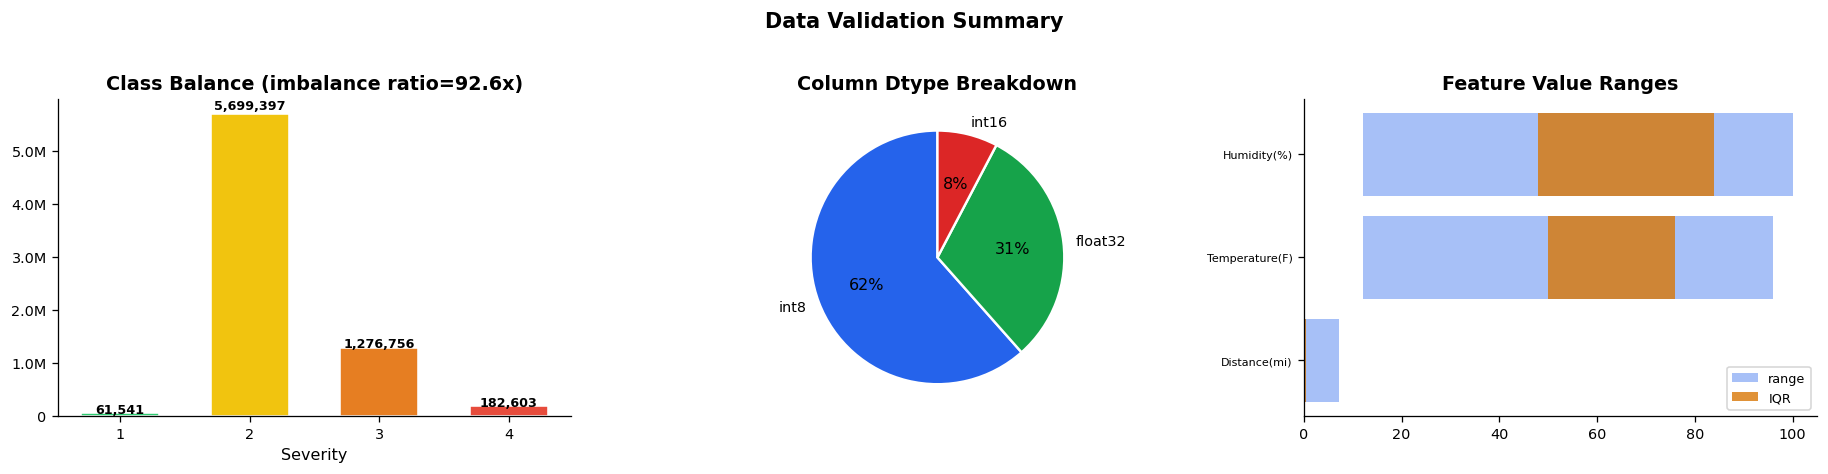

In [16]:
# ── Validation visualisation ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16,4))

# Class distribution with imbalance ratio
ax = axes[0]
cnt = df["Severity"].value_counts().sort_index()
bars = ax.bar(cnt.index.astype(str), cnt.values,
              color=[SEV_COLOR[i] for i in cnt.index], edgecolor="white", width=0.6)
for b,v in zip(bars,cnt.values):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()*1.015,
            f"{v:,}", ha="center", fontsize=8, fontweight="bold")
ax.set_title(f"Class Balance (imbalance ratio={cnt.max()/cnt.min():.1f}x)", fontweight="bold")
ax.set_xlabel("Severity")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x,_: f"{x/1e6:.1f}M" if x>=1e6 else f"{int(x):,}"))

# Dtype breakdown
ax = axes[1]
dtypes = df.dtypes.astype(str).value_counts()
ax.pie(dtypes.values, labels=dtypes.index, autopct="%1.0f%%",
       colors=PALETTE[:len(dtypes)], startangle=90,
       wedgeprops={"edgecolor":"white","linewidth":1.5})
ax.set_title("Column Dtype Breakdown", fontweight="bold")

# Numeric feature ranges (box-plot style summary)
ax = axes[2]
num_summary = df[FEATURE_COLS].select_dtypes("float32").describe().T[["min","25%","50%","75%","max"]]
ax.barh(range(len(num_summary)), num_summary["max"]-num_summary["min"],
        left=num_summary["min"], color="#2563EB", alpha=0.4, edgecolor="none",
        label="range")
ax.barh(range(len(num_summary)), num_summary["75%"]-num_summary["25%"],
        left=num_summary["25%"], color="#D97706", alpha=0.8, edgecolor="none",
        label="IQR")
ax.set_yticks(range(len(num_summary)))
ax.set_yticklabels(num_summary.index, fontsize=7)
ax.set_title("Feature Value Ranges", fontweight="bold"); ax.legend()

plt.suptitle("Data Validation Summary", fontweight="bold", fontsize=13, y=1.02)
plt.tight_layout(); plt.savefig("04_validation.png", bbox_inches="tight"); plt.show()

---
## 5 · Exploratory Data Analysis (EDA)

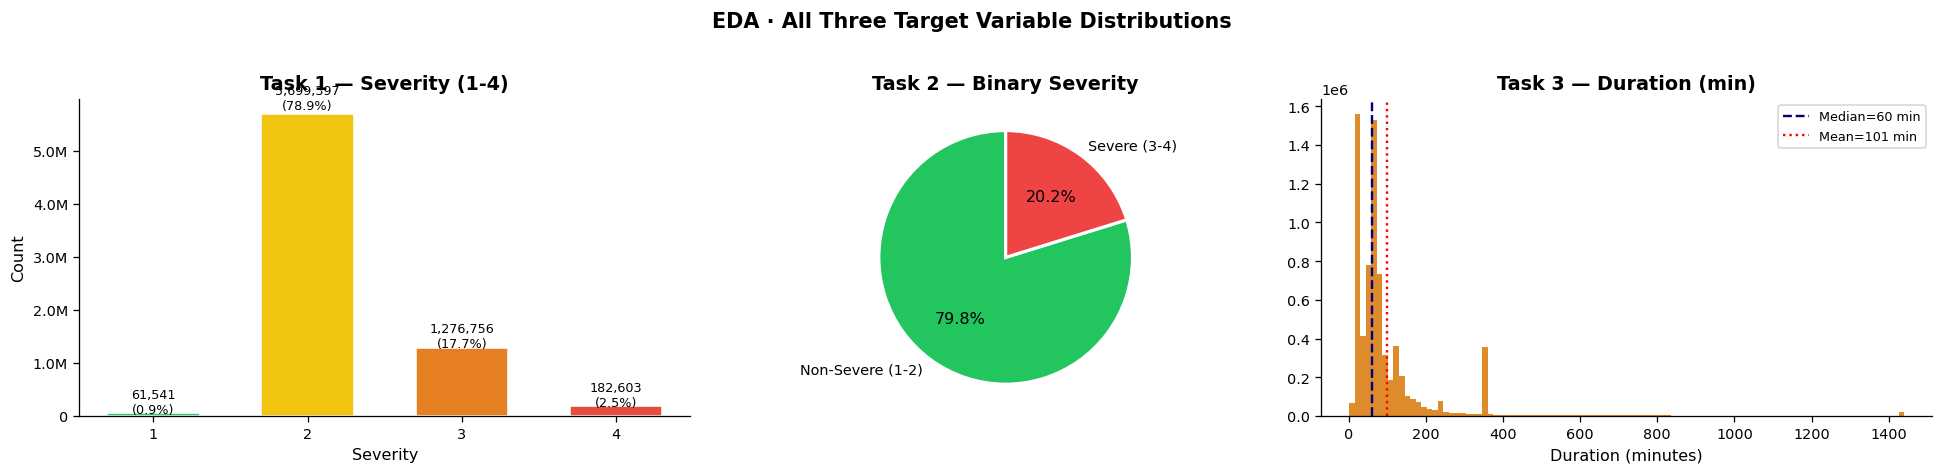

In [17]:
# ── 5.1  All three target distributions ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17,4))

# Task 1 – Severity
cnt = df["Severity"].value_counts().sort_index()
bars = axes[0].bar(cnt.index.astype(str), cnt.values,
                   color=[SEV_COLOR[i] for i in cnt.index], edgecolor="white", width=0.6)
for b,v in zip(bars,cnt.values):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()*1.015,
                 f"{v:,}\n({v/len(df)*100:.1f}%)", ha="center", fontsize=8)
axes[0].set_title("Task 1 — Severity (1-4)", fontweight="bold")
axes[0].set_xlabel("Severity"); axes[0].set_ylabel("Count")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x,_: f"{x/1e6:.1f}M" if x>=1e6 else f"{int(x):,}"))

# Task 2 – Binary
bc = df["IsSevere"].value_counts()
wedges,_,autotexts = axes[1].pie(
    bc.values, labels=["Non-Severe (1-2)","Severe (3-4)"],
    colors=["#22C55E","#EF4444"], autopct="%1.1f%%", startangle=90,
    wedgeprops={"edgecolor":"white","linewidth":2})
for at in autotexts: at.set_fontsize(10)
axes[1].set_title("Task 2 — Binary Severity", fontweight="bold")

# Task 3 – Duration
if "Duration_min" in df.columns:
    axes[2].hist(df["Duration_min"], bins=100, color="#D97706", edgecolor="none", alpha=0.85)
    axes[2].axvline(df["Duration_min"].median(), color="navy",  linestyle="--",
                    label=f"Median={df['Duration_min'].median():.0f} min")
    axes[2].axvline(df["Duration_min"].mean(),   color="red",   linestyle=":",
                    label=f"Mean={df['Duration_min'].mean():.0f} min")
    axes[2].set_title("Task 3 — Duration (min)", fontweight="bold")
    axes[2].set_xlabel("Duration (minutes)"); axes[2].legend()

plt.suptitle("EDA · All Three Target Variable Distributions", fontweight="bold", fontsize=13, y=1.02)
plt.tight_layout(); plt.savefig("05a_eda_targets.png", bbox_inches="tight"); plt.show()

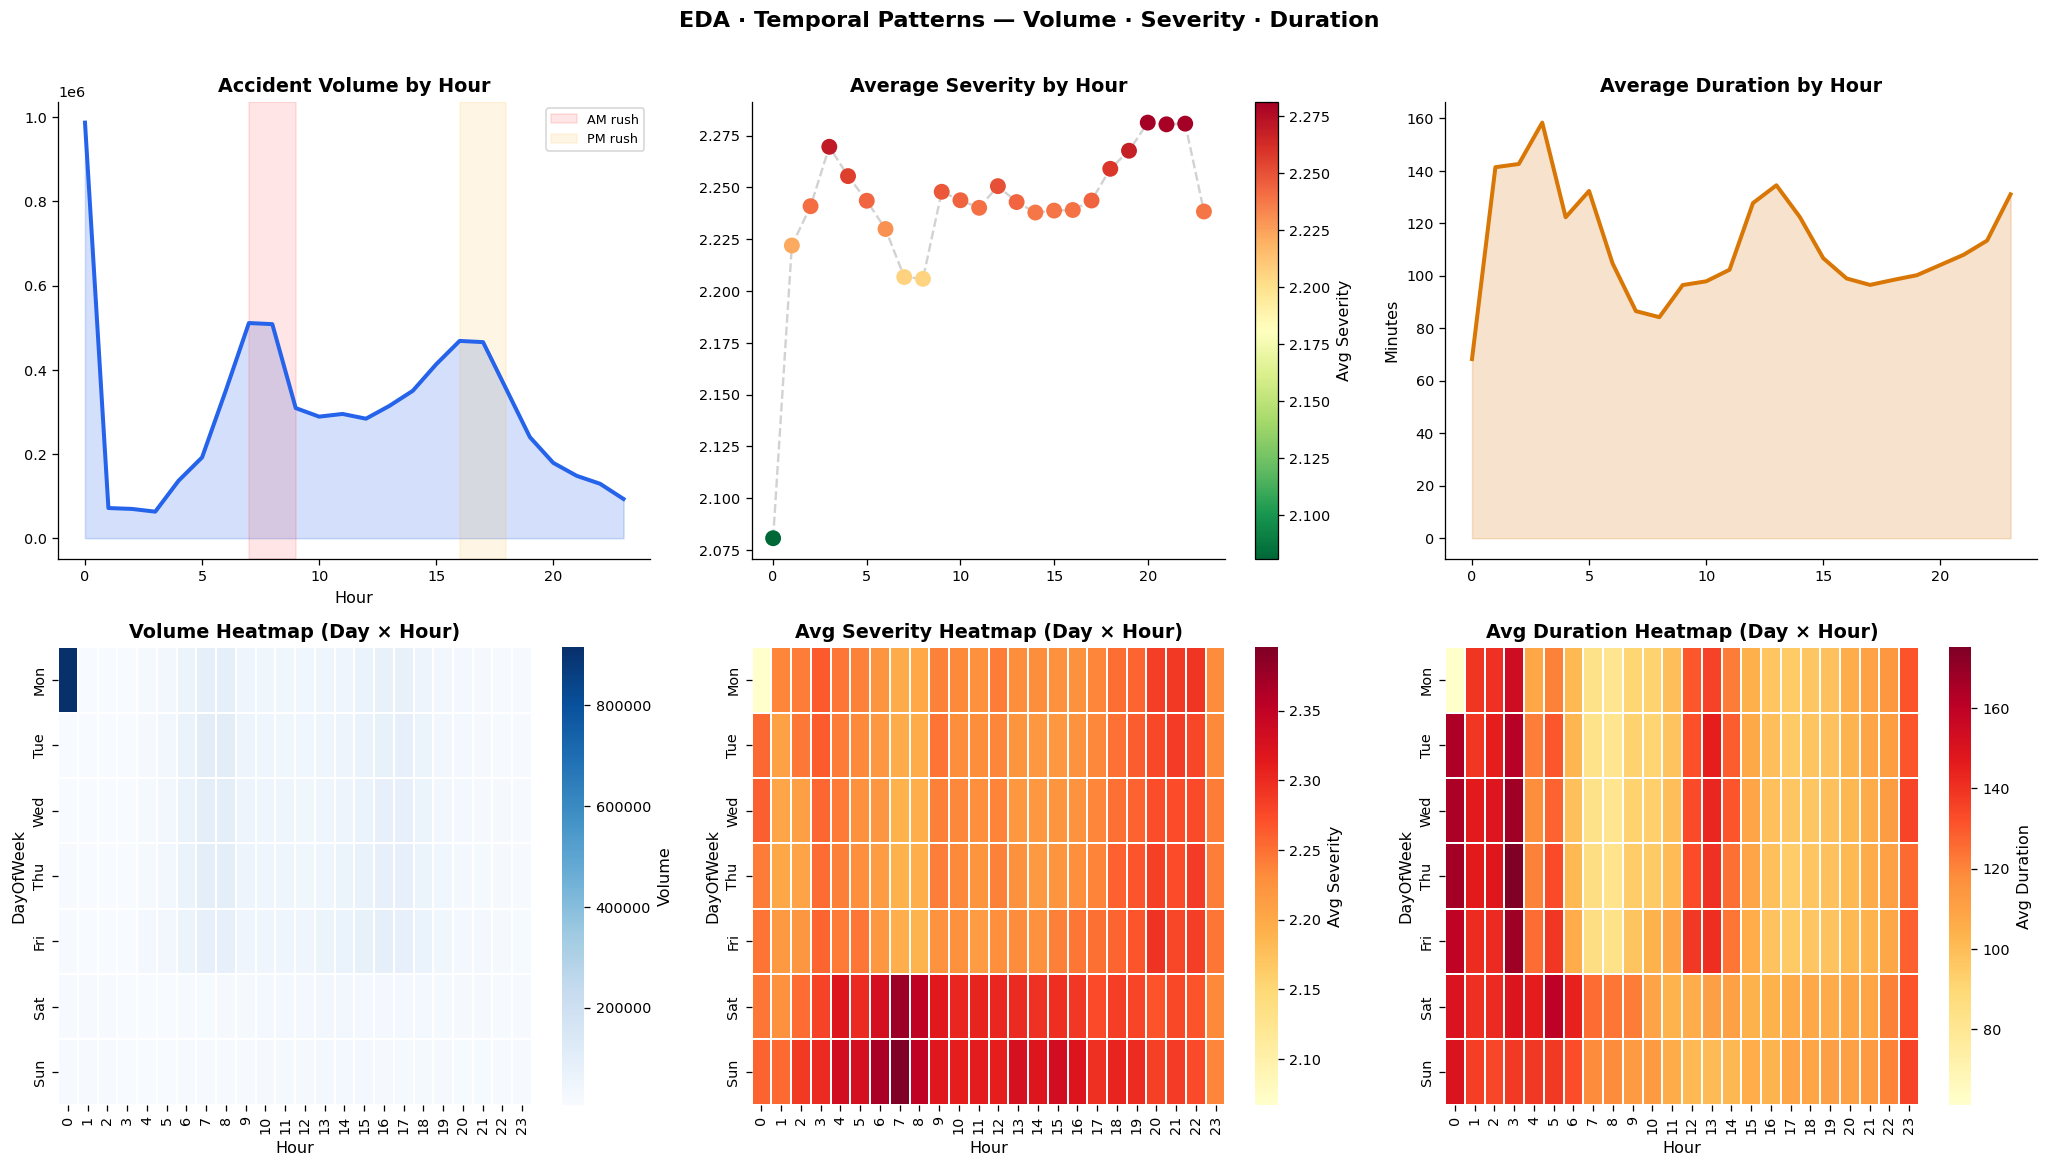

In [18]:
# ── 5.2  Temporal patterns ────────────────────────────────────────────────────
day_labels = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
fig, axes  = plt.subplots(2, 3, figsize=(18,10))

# Volume by hour
h_cnt = df.groupby("Hour").size()
axes[0,0].fill_between(h_cnt.index, h_cnt.values, alpha=0.2, color="#2563EB")
axes[0,0].plot(h_cnt.index, h_cnt.values, color="#2563EB", lw=2.5)
axes[0,0].axvspan(7,9,   alpha=0.1, color="red",    label="AM rush")
axes[0,0].axvspan(16,18, alpha=0.1, color="orange",  label="PM rush")
axes[0,0].set_title("Accident Volume by Hour", fontweight="bold")
axes[0,0].set_xlabel("Hour"); axes[0,0].legend()

# Avg severity by hour
sev_h = df.groupby("Hour")["Severity"].mean()
sc = axes[0,1].scatter(sev_h.index, sev_h.values,
                       c=sev_h.values, cmap="RdYlGn_r", s=80, zorder=3)
axes[0,1].plot(sev_h.index, sev_h.values, "--", alpha=0.35, color="gray")
plt.colorbar(sc, ax=axes[0,1], label="Avg Severity")
axes[0,1].set_title("Average Severity by Hour", fontweight="bold")

# Avg duration by hour
if "Duration_min" in df.columns:
    dur_h = df.groupby("Hour")["Duration_min"].mean()
    axes[0,2].fill_between(dur_h.index, dur_h.values, alpha=0.2, color="#D97706")
    axes[0,2].plot(dur_h.index, dur_h.values, color="#D97706", lw=2.5)
    axes[0,2].set_title("Average Duration by Hour", fontweight="bold")
    axes[0,2].set_ylabel("Minutes")

# Heatmaps
for col_i,(target_col,label,cmap) in enumerate([
    (None,        "Volume",       "Blues"),
    ("Severity",  "Avg Severity", "YlOrRd"),
    ("Duration_min","Avg Duration","YlOrRd"),
]):
    ax = axes[1,col_i]
    if target_col is None:
        pv = df.groupby(["DayOfWeek","Hour"]).size().unstack(fill_value=0)
    elif target_col in df.columns:
        pv = df.groupby(["DayOfWeek","Hour"])[target_col].mean().unstack()
    else:
        ax.set_visible(False); continue
    sns.heatmap(pv, ax=ax, cmap=cmap, yticklabels=day_labels,
                linewidths=0.1, cbar_kws={"label":label})
    ax.set_title(f"{label} Heatmap (Day × Hour)", fontweight="bold")
    ax.set_xlabel("Hour")

plt.suptitle("EDA · Temporal Patterns — Volume · Severity · Duration",
             fontweight="bold", fontsize=14, y=1.01)
plt.tight_layout(); plt.savefig("05b_eda_temporal.png", bbox_inches="tight"); plt.show()

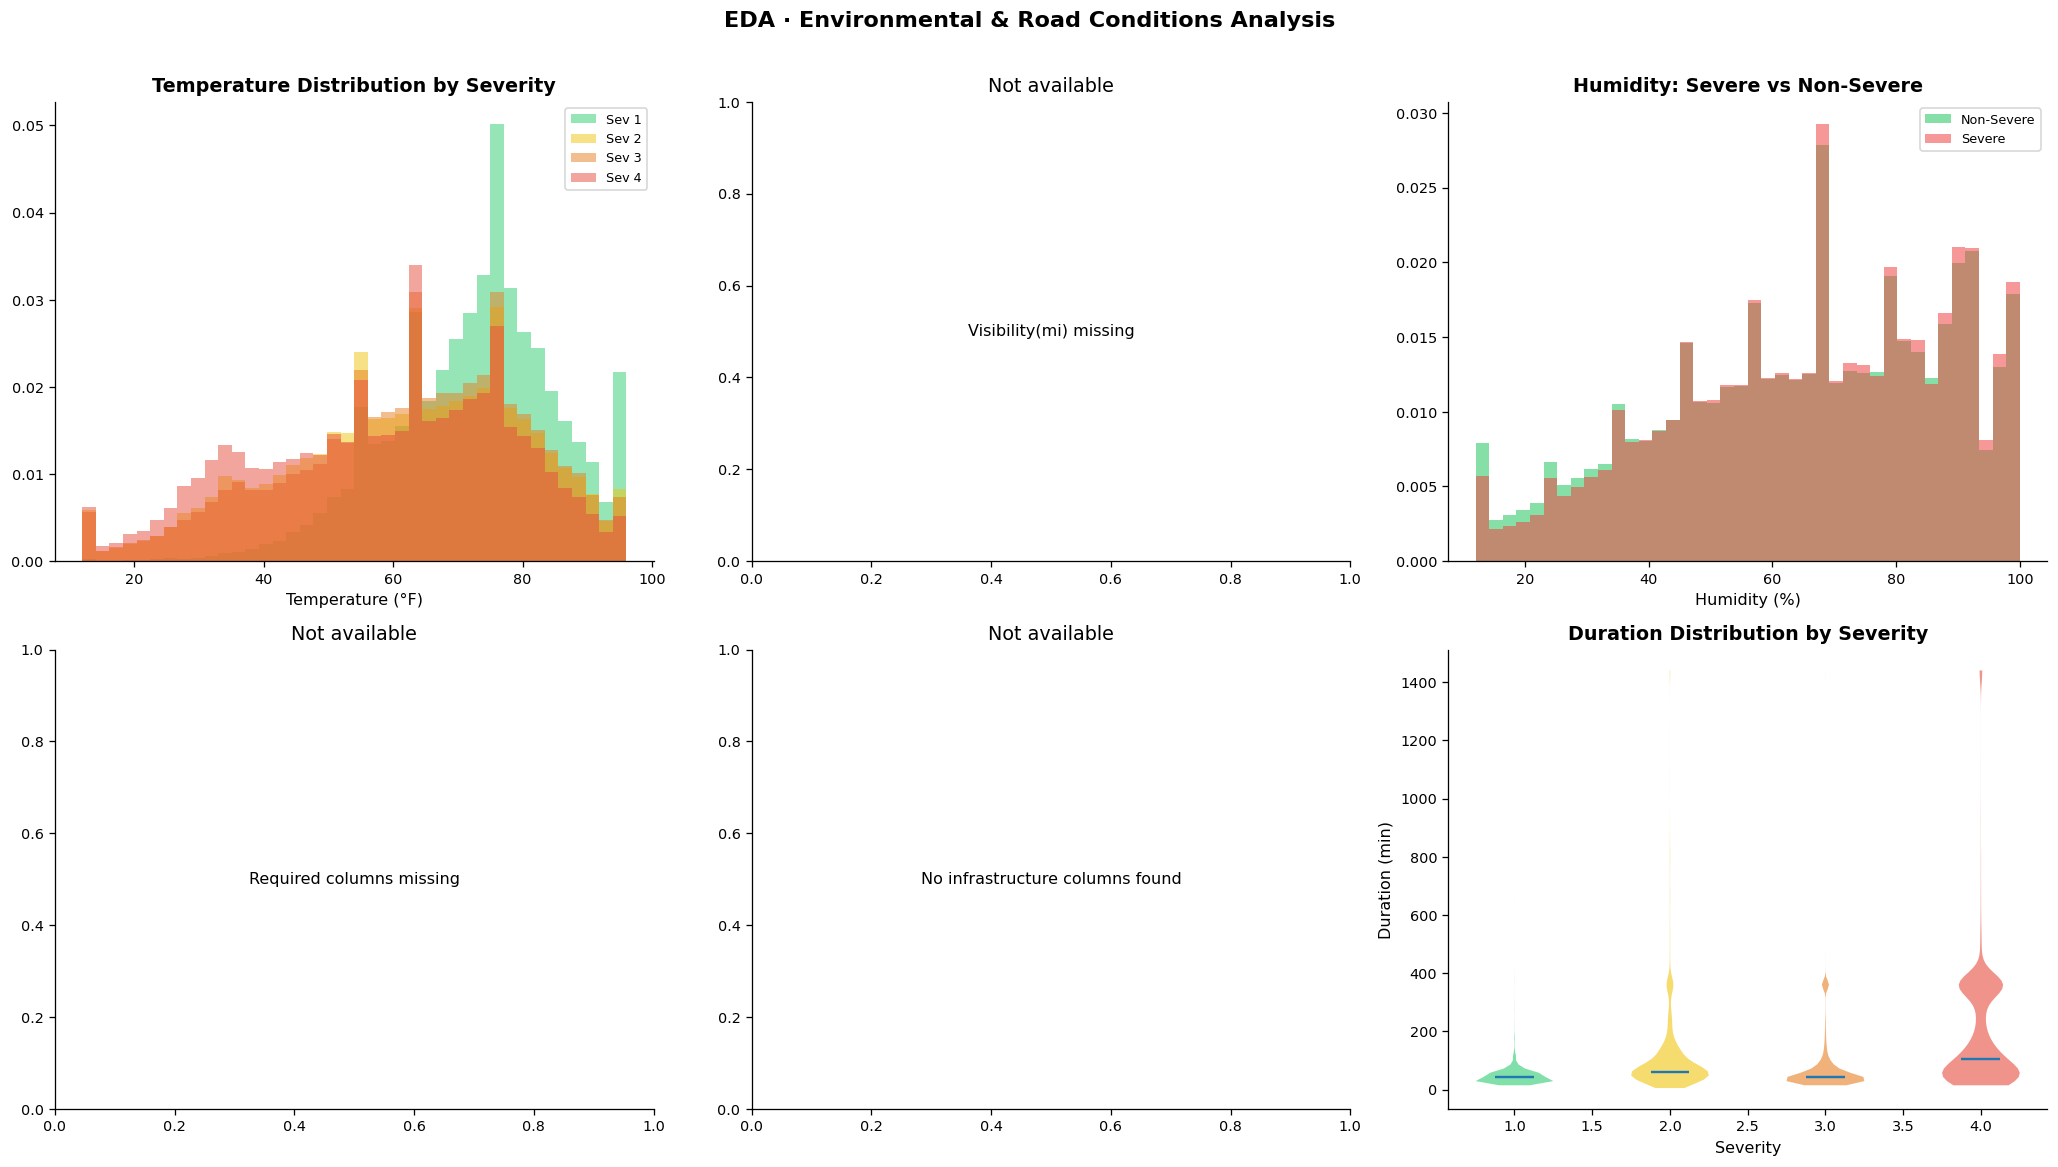

In [20]:
# ── 5.3 Weather, road conditions, infrastructure ─────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Ensure SEV_COLOR is defined (if not, create a default)
if 'SEV_COLOR' not in dir():
    SEV_COLOR = {1: "#2ecc71", 2: "#f1c40f", 3: "#e67e22", 4: "#e74c3c"}

# ---------- 1. Temperature by severity ----------
if "Temperature(F)" in df.columns and "Severity" in df.columns:
    for sev in sorted(df["Severity"].dropna().unique()):
        data = df.loc[df["Severity"] == sev, "Temperature(F)"].dropna()
        if len(data) > 0:
            axes[0,0].hist(data, bins=40, alpha=0.5, density=True,
                           label=f"Sev {sev}", color=SEV_COLOR.get(int(sev), "gray"))
    axes[0,0].set_title("Temperature Distribution by Severity", fontweight="bold")
    axes[0,0].set_xlabel("Temperature (°F)")
    axes[0,0].legend()
else:
    axes[0,0].text(0.5, 0.5, "Temperature(F) or Severity missing", ha="center", va="center")
    axes[0,0].set_title("Not available")

# ---------- 2. Visibility by severity (mean bars) ----------
if "Visibility(mi)" in df.columns and "Severity" in df.columns:
    vis_sev = df.groupby("Severity")["Visibility(mi)"].mean()
    axes[0,1].bar(vis_sev.index.astype(str), vis_sev.values,
                  color=[SEV_COLOR.get(int(i), "gray") for i in vis_sev.index],
                  edgecolor="white")
    axes[0,1].set_title("Avg Visibility by Severity", fontweight="bold")
    axes[0,1].set_xlabel("Severity")
    axes[0,1].set_ylabel("Miles")
else:
    axes[0,1].text(0.5, 0.5, "Visibility(mi) missing", ha="center", va="center")
    axes[0,1].set_title("Not available")

# ---------- 3. Humidity: severe vs non-severe ----------
if "Humidity(%)" in df.columns and "IsSevere" in df.columns:
    for val, clr, lbl in [(0, "#22C55E", "Non-Severe"), (1, "#EF4444", "Severe")]:
        data = df.loc[df["IsSevere"] == val, "Humidity(%)"].dropna()
        if len(data) > 0:
            axes[0,2].hist(data, bins=40, alpha=0.55, density=True, color=clr, label=lbl)
    axes[0,2].set_title("Humidity: Severe vs Non-Severe", fontweight="bold")
    axes[0,2].set_xlabel("Humidity (%)")
    axes[0,2].legend()
else:
    axes[0,2].text(0.5, 0.5, "Humidity(%) or IsSevere missing", ha="center", va="center")
    axes[0,2].set_title("Not available")

# ---------- 4. Precipitation vs duration scatter ----------
if "Precipitation(in)" in df.columns and "Duration_min" in df.columns and "Severity" in df.columns:
    samp = df[["Precipitation(in)", "Duration_min", "Severity"]].dropna().sample(min(8000, len(df)), random_state=42)
    sc = axes[1,0].scatter(samp["Precipitation(in)"], samp["Duration_min"],
                           c=samp["Severity"], cmap="RdYlGn_r", alpha=0.3, s=8)
    plt.colorbar(sc, ax=axes[1,0], label="Severity")
    axes[1,0].set_title("Precipitation vs Duration", fontweight="bold")
    axes[1,0].set_xlabel("Precipitation (in)")
    axes[1,0].set_ylabel("Duration (min)")
else:
    axes[1,0].text(0.5, 0.5, "Required columns missing", ha="center", va="center")
    axes[1,0].set_title("Not available")

# ---------- 5. Infrastructure flags vs severity mean ----------
infra_cols = ["Junction", "Traffic_Signal", "Crossing", "Stop", "Railway", "Roundabout"]
available_infra = [c for c in infra_cols if c in df.columns]
if available_infra and "Severity" in df.columns:
    infra_means = df.groupby("Severity")[available_infra].mean()
    infra_means.T.plot(kind="bar", ax=axes[1,1],
                       color=[SEV_COLOR.get(i, "gray") for i in infra_means.index],
                       edgecolor="white")
    axes[1,1].set_title("Infrastructure Feature Rate by Severity", fontweight="bold")
    axes[1,1].set_xlabel("Feature")
    axes[1,1].set_ylabel("Mean presence rate")
    axes[1,1].set_xticklabels(available_infra, rotation=30, ha="right")
    axes[1,1].legend(title="Severity")
else:
    axes[1,1].text(0.5, 0.5, "No infrastructure columns found", ha="center", va="center")
    axes[1,1].set_title("Not available")

# ---------- 6. Duration violin by severity ----------
if "Duration_min" in df.columns and "Severity" in df.columns:
    severity_values = sorted(df["Severity"].dropna().unique())
    data_by_sev = []
    for s in severity_values:
        sub = df.loc[df["Severity"] == s, "Duration_min"].dropna()
        if len(sub) > 0:
            sampled = sub.sample(min(5000, len(sub)), random_state=1).values
        else:
            sampled = np.array([])
        data_by_sev.append(sampled)
    # Remove empty groups
    valid_indices = [i for i, d in enumerate(data_by_sev) if len(d) > 0]
    data_by_sev = [data_by_sev[i] for i in valid_indices]
    positions = [severity_values[i] for i in valid_indices]
    if len(data_by_sev) > 0:
        vp = axes[1,2].violinplot(data_by_sev, positions=positions,
                                  showmedians=True, showextrema=False)
        for i, body in enumerate(vp["bodies"]):
            sev_val = positions[i]
            body.set_facecolor(SEV_COLOR.get(sev_val, "#95a5a6"))
            body.set_alpha(0.6)
        axes[1,2].set_title("Duration Distribution by Severity", fontweight="bold")
        axes[1,2].set_xlabel("Severity")
        axes[1,2].set_ylabel("Duration (min)")
    else:
        axes[1,2].text(0.5, 0.5, "Insufficient data", ha="center", va="center")
else:
    axes[1,2].text(0.5, 0.5, "Duration_min or Severity missing", ha="center", va="center")
    axes[1,2].set_title("Not available")

plt.suptitle("EDA · Environmental & Road Conditions Analysis",
             fontweight="bold", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("05c_eda_weather.png", bbox_inches="tight")
plt.show()

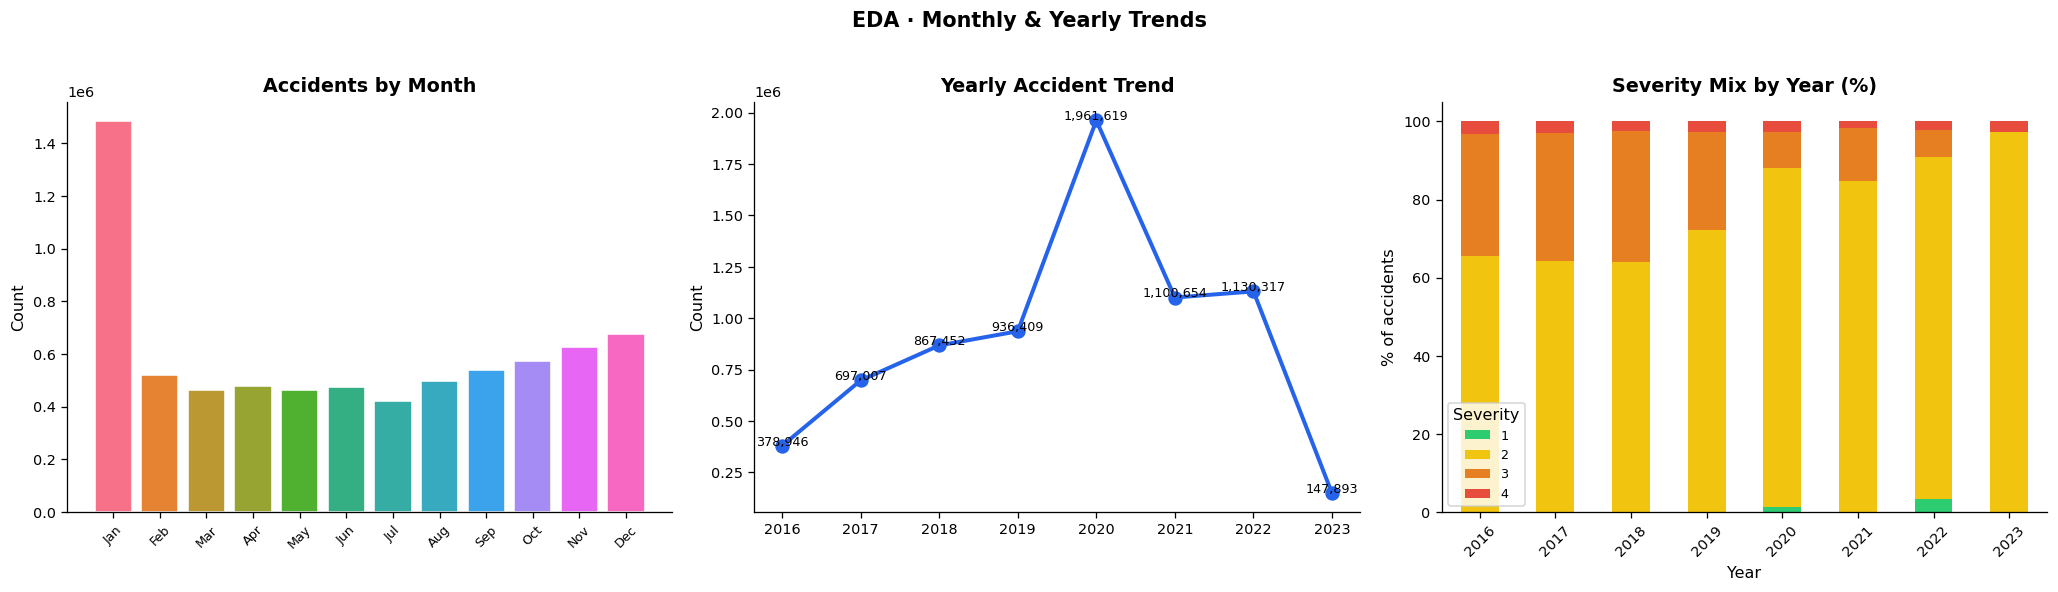

In [21]:
# ── 5.4  Monthly / yearly trends ─────────────────────────────────────────────
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
fig, axes   = plt.subplots(1, 3, figsize=(18,5))

# Monthly volume
monthly = df.groupby("Month").size()
axes[0].bar(range(1,13), monthly.values,
            color=sns.color_palette("husl",12), edgecolor="white")
axes[0].set_xticks(range(1,13))
axes[0].set_xticklabels(month_names, rotation=45, fontsize=8)
axes[0].set_title("Accidents by Month", fontweight="bold"); axes[0].set_ylabel("Count")

# Yearly trend
yearly = df.groupby("Year").size()
axes[1].plot(yearly.index, yearly.values, "o-", color="#2563EB", lw=2.5, ms=8)
for x,y in zip(yearly.index, yearly.values):
    axes[1].text(x, y+2000, f"{y:,}", ha="center", fontsize=8)
axes[1].set_title("Yearly Accident Trend", fontweight="bold"); axes[1].set_ylabel("Count")

# Severity proportion by year (stacked bar)
sev_yr     = df.groupby(["Year","Severity"]).size().unstack(fill_value=0)
sev_yr_pct = sev_yr.div(sev_yr.sum(axis=1), axis=0)*100
sev_yr_pct.plot(kind="bar", stacked=True, ax=axes[2],
                color=[SEV_COLOR[i] for i in sev_yr_pct.columns], edgecolor="none")
axes[2].set_title("Severity Mix by Year (%)", fontweight="bold")
axes[2].set_xlabel("Year"); axes[2].set_ylabel("% of accidents")
axes[2].legend(title="Severity"); axes[2].tick_params(axis="x",rotation=45)

plt.suptitle("EDA · Monthly & Yearly Trends", fontweight="bold", fontsize=13, y=1.02)
plt.tight_layout(); plt.savefig("05d_eda_trends.png", bbox_inches="tight"); plt.show()

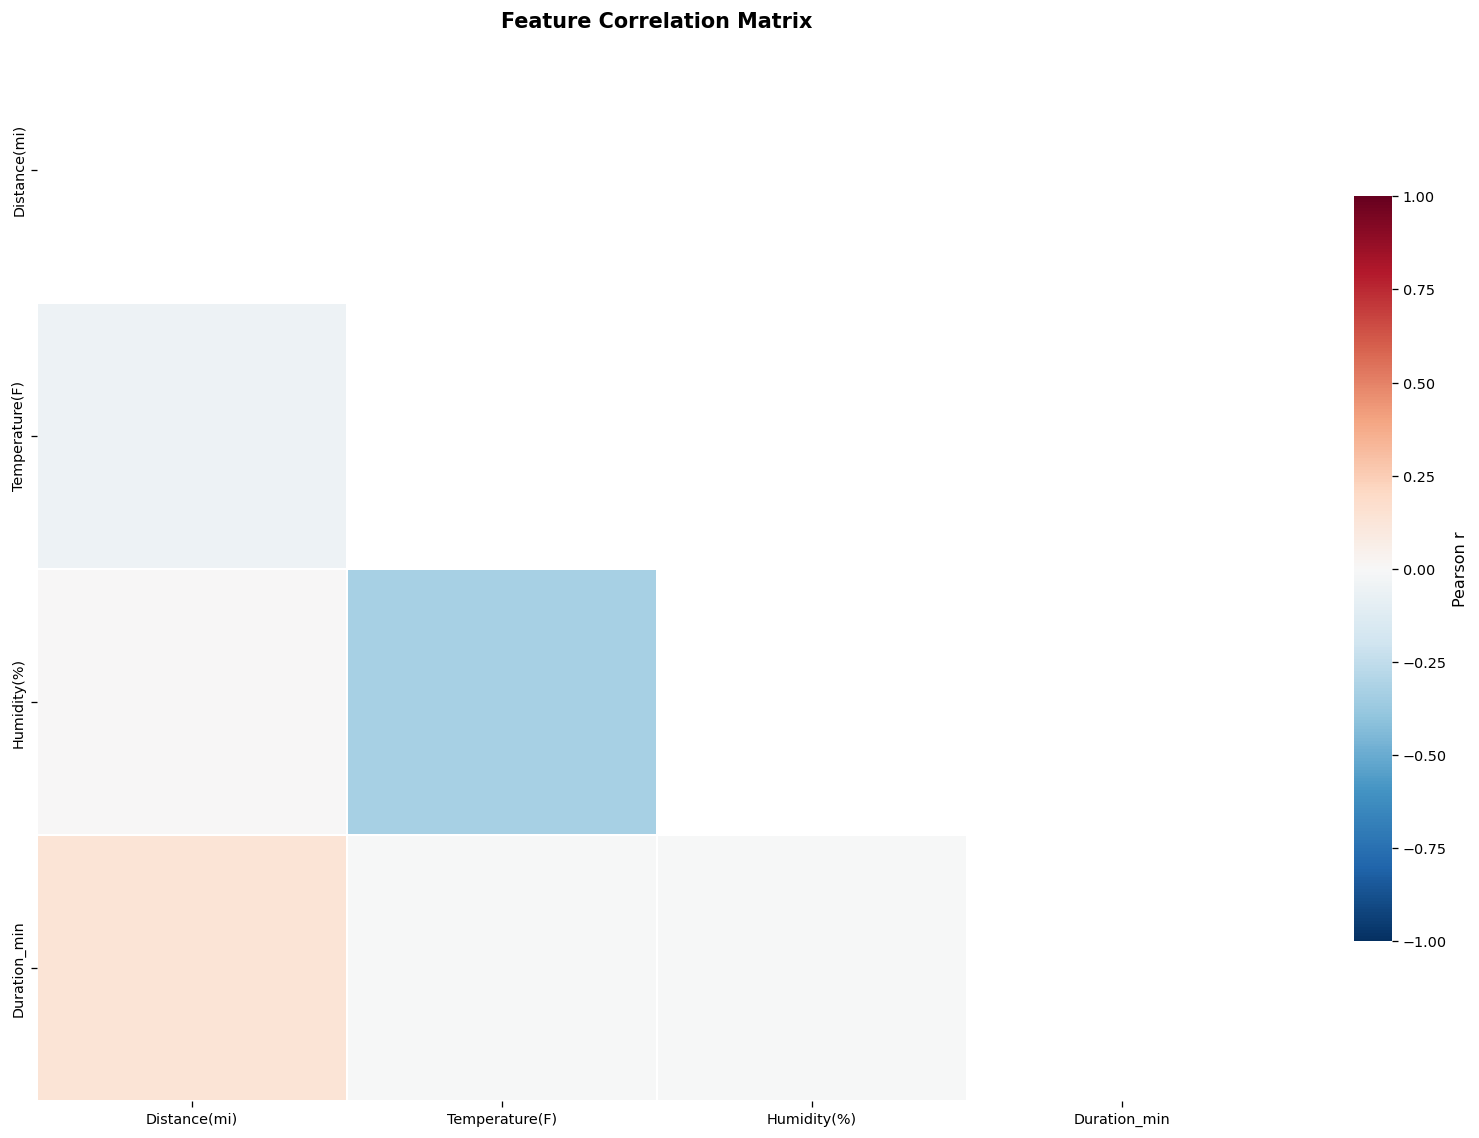

In [22]:
# ── 5.5  Correlation matrix ───────────────────────────────────────────────────
num_eda = df.select_dtypes("float32").columns.tolist()[:22]
corr    = df[num_eda].corr()
fig, ax = plt.subplots(figsize=(14,10))
mask    = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=ax, cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, linewidths=0.25,
            cbar_kws={"shrink":0.7,"label":"Pearson r"})
ax.set_title("Feature Correlation Matrix", fontweight="bold", fontsize=13)
plt.tight_layout(); plt.savefig("05e_eda_correlation.png", bbox_inches="tight"); plt.show()

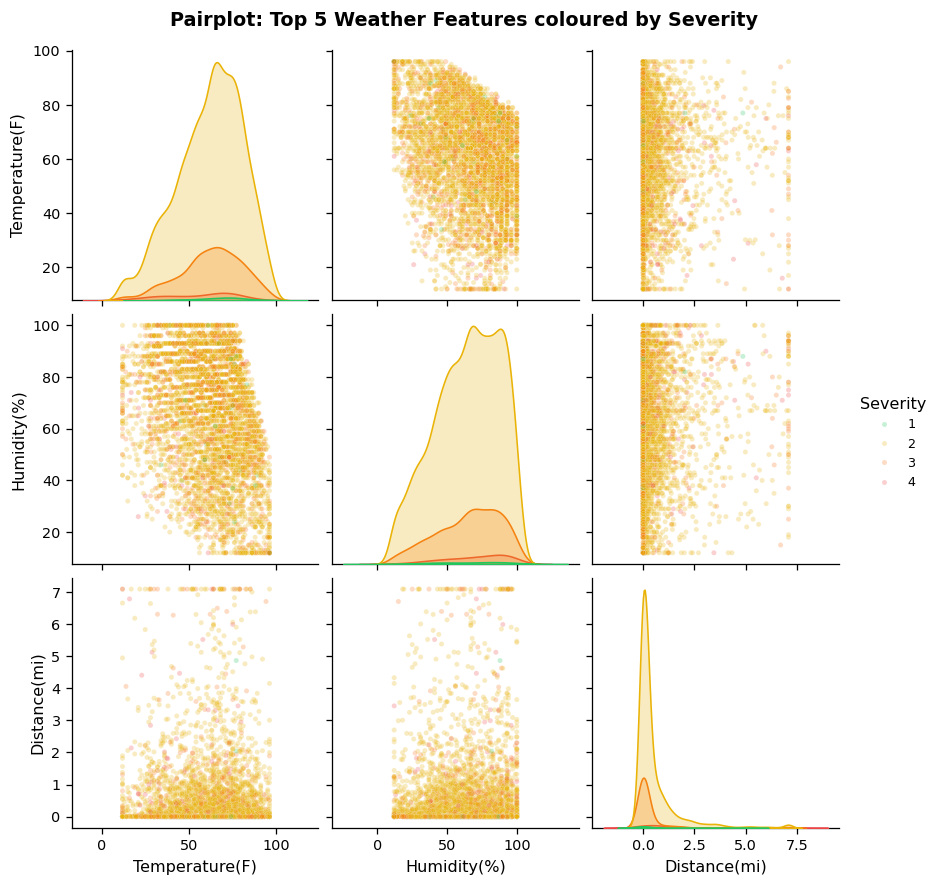

In [23]:
# ── 5.6  Pairplot of top 5 features vs Severity ───────────────────────────────
top5 = ["Temperature(F)","Visibility(mi)","Humidity(%)",
        "Precipitation(in)","Distance(mi)"]
top5 = [c for c in top5 if c in df.columns]
samp = df[top5+["Severity"]].sample(min(5000,len(df)), random_state=0)
g = sns.pairplot(samp, hue="Severity", vars=top5, diag_kind="kde",
                 palette={1:"#22C55E",2:"#EAB308",3:"#F97316",4:"#EF4444"},
                 plot_kws={"alpha":0.25,"s":10})
g.fig.suptitle("Pairplot: Top 5 Weather Features coloured by Severity",
               y=1.02, fontweight="bold", fontsize=12)
plt.savefig("05f_eda_pairplot.png", bbox_inches="tight"); plt.show()

---
## 6 · Shared Train/Val/Test Split & Helper Functions

In [24]:
# ── Index-level 70/15/15 stratified split (no data copies) ───────────────────
sev_strat = df["Severity"].values
all_idx   = np.arange(len(df))

idx_tr, idx_tmp = train_test_split(all_idx, test_size=0.30,
                                    stratify=sev_strat, random_state=42)
idx_val, idx_te = train_test_split(idx_tmp,  test_size=0.50,
                                    stratify=sev_strat[idx_tmp], random_state=42)

print("Split sizes (index-only — no DataFrame copies):")
print(f"  Train : {len(idx_tr):>9,}  ({len(idx_tr)/len(df)*100:.0f}%)")
print(f"  Val   : {len(idx_val):>9,}  ({len(idx_val)/len(df)*100:.0f}%)")
print(f"  Test  : {len(idx_te):>9,}  ({len(idx_te)/len(df)*100:.0f}%)")

# Verify stratification
for split, idx in [("Train",idx_tr),("Val",idx_val),("Test",idx_te)]:
    vc = pd.Series(sev_strat[idx]).value_counts(normalize=True).sort_index()*100
    print(f"  {split} severity %: " + "  ".join(f"Sev{k}:{v:.1f}%" for k,v in vc.items()))

Split sizes (index-only — no DataFrame copies):
  Train : 5,054,207  (70%)
  Val   : 1,083,045  (15%)
  Test  : 1,083,045  (15%)
  Train severity %: Sev1:0.9%  Sev2:78.9%  Sev3:17.7%  Sev4:2.5%
  Val severity %: Sev1:0.9%  Sev2:78.9%  Sev3:17.7%  Sev4:2.5%
  Test severity %: Sev1:0.9%  Sev2:78.9%  Sev3:17.7%  Sev4:2.5%


In [25]:
# ── Array helper: materialise float32 arrays for any target ───────────────────
def get_arrays(target_col, extra_feats=None):
    feats = FEATURE_COLS + (extra_feats or [])
    feats = [f for f in feats if f in df.columns]
    sc    = StandardScaler()
    sc.fit(df.iloc[idx_tr][feats])
    Xtr  = sc.transform(df.iloc[idx_tr ][feats]).astype("float32")
    Xval = sc.transform(df.iloc[idx_val][feats]).astype("float32")
    Xte  = sc.transform(df.iloc[idx_te ][feats]).astype("float32")
    ytr  = df.iloc[idx_tr ][target_col].values
    yval = df.iloc[idx_val][target_col].values
    yte  = df.iloc[idx_te ][target_col].values
    print(f"  Arrays built  Xtr={Xtr.nbytes/1024**2:.0f}MB  Xte={Xte.nbytes/1024**2:.0f}MB")
    return Xtr, Xval, Xte, ytr, yval, yte, feats

# ── SMOTE on capped subsample ─────────────────────────────────────────────────
def apply_smote(Xtr, ytr, cap=120_000):
    if len(Xtr) > cap:
        rng  = np.random.default_rng(42)
        sidx = rng.choice(len(Xtr), cap, replace=False)
        Xtr, ytr = Xtr[sidx], ytr[sidx]
    sm   = SMOTE(random_state=42, k_neighbors=5)
    Xs, ys = sm.fit_resample(Xtr, ytr)
    print(f"  SMOTE: {len(ytr):,} → {len(ys):,} | {Xs.nbytes/1024**2:.0f} MB")
    return Xs.astype("float32"), ys

print("✅  get_arrays & apply_smote ready")

✅  get_arrays & apply_smote ready


In [26]:
# ── Universal classification trainer ──────────────────────────────────────────
def train_classifiers(task_name, models_dict, Xtr, ytr, Xte, yte, n_classes):
    print(f"\n  {'Model':<28} {'Acc':>6} {'Prec':>6} {'Rec':>6} {'F1':>6} {'AUC':>6} {'s':>6}")
    print("  " + "─"*66)
    results = {}
    for name, mdl in models_dict.items():
        t0 = time.time(); mdl.fit(Xtr, ytr); elapsed = time.time()-t0
        yp  = mdl.predict(Xte)
        acc = accuracy_score(yte, yp)
        pw  = precision_score(yte, yp, average="weighted", zero_division=0)
        rw  = recall_score   (yte, yp, average="weighted", zero_division=0)
        f1w = f1_score       (yte, yp, average="weighted", zero_division=0)
        try:
            yprob = mdl.predict_proba(Xte).astype("float32")
            ybin  = label_binarize(yte, classes=sorted(np.unique(yte)))
            auc_s = (roc_auc_score(yte, yprob[:,1]) if n_classes==2
                     else roc_auc_score(ybin, yprob, multi_class="ovr", average="weighted"))
        except:
            yprob = None; auc_s = np.nan
        results[name] = dict(
            model=mdl, Accuracy=round(acc,4),
            Precision=round(pw,4), Recall=round(rw,4),
            F1=round(f1w,4),
            AUC=(round(auc_s,4) if not np.isnan(auc_s) else np.nan),
            Time=round(elapsed,1), y_pred=yp, y_prob=yprob
        )
        print(f"  {name:<28} {acc:>6.4f} {pw:>6.4f} {rw:>6.4f} {f1w:>6.4f} "
              f"{auc_s:>6.4f} {elapsed:>5.1f}s")
        gc.collect()
    ALL_RESULTS[task_name] = results
    return results

# ── Universal regression trainer ──────────────────────────────────────────────
def train_regressors(task_name, models_dict, Xtr, ytr, Xte, yte):
    print(f"\n  {'Model':<28} {'MAE':>8} {'RMSE':>8} {'R²':>8} {'MAPE%':>8} {'s':>6}")
    print("  " + "─"*66)
    results = {}
    for name, mdl in models_dict.items():
        t0 = time.time(); mdl.fit(Xtr, ytr); elapsed = time.time()-t0
        yp   = mdl.predict(Xte)
        mae  = mean_absolute_error(yte, yp)
        rmse = np.sqrt(mean_squared_error(yte, yp))
        r2   = r2_score(yte, yp)
        mask = yte > 0
        mape = np.mean(np.abs((yte[mask]-yp[mask])/yte[mask]))*100
        results[name] = dict(
            model=mdl, MAE=round(mae,2), RMSE=round(rmse,2),
            R2=round(r2,4), MAPE=round(mape,2),
            Time=round(elapsed,1), y_pred=yp
        )
        print(f"  {name:<28} {mae:>8.2f} {rmse:>8.2f} {r2:>8.4f} {mape:>7.2f}% {elapsed:>5.1f}s")
        gc.collect()
    ALL_RESULTS[task_name] = results
    return results

print("✅  Trainer functions ready")

✅  Trainer functions ready


In [27]:
# ── Visualisation helpers ──────────────────────────────────────────────────────

def styled_table(results, keys, sort_by):
    rows = [{"Model":n, **{k:v[k] for k in keys if k in v}}
            for n,v in results.items()]
    df_r = pd.DataFrame(rows).set_index("Model").sort_values(sort_by, ascending=False)
    hi = [c for c in df_r.columns if c not in ["Time","MAE","RMSE","MAPE"]]
    lo = [c for c in df_r.columns if c in  ["MAE","RMSE","MAPE"]]
    st = df_r.style
    if hi: st = st.background_gradient(cmap="YlGn",    subset=hi)
    if lo: st = st.background_gradient(cmap="YlOrRd_r",subset=lo)
    st = st.format({c:"{:.4f}" for c in df_r.select_dtypes(float).columns
                    if c not in ["Time"]})
    st = st.format({"Time":"{:.1f}s"} if "Time" in df_r.columns else {})
    display(st)
    return df_r


def plot_metrics_bar(results, metrics, title, palette=None, ylim=(0,1.15)):
    pal   = palette or PALETTE
    names = list(results.keys()); x = np.arange(len(names))
    w     = min(0.8/len(metrics), 0.18)
    fig, ax = plt.subplots(figsize=(13,5))
    for i,(metric,clr) in enumerate(zip(metrics,pal)):
        vals = [results[m].get(metric,np.nan) for m in names]
        bars = ax.bar(x+(i-(len(metrics)-1)/2)*w, vals, w,
                      label=metric, color=clr, edgecolor="white")
        for b,v in zip(bars,vals):
            if not np.isnan(v):
                ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005,
                        f"{v:.3f}", ha="center", fontsize=7.5, rotation=40)
    ax.set_xticks(x); ax.set_xticklabels(names, rotation=15, ha="right")
    ax.set_ylim(*ylim); ax.set_ylabel("Score"); ax.legend(fontsize=9)
    ax.set_title(title, fontweight="bold", fontsize=12)
    plt.tight_layout(); plt.show()


def plot_cm_grid(results, yte, labels, title, figw=4.0):
    n    = len(results)
    fig, axes = plt.subplots(1, n, figsize=(figw*n, figw+0.5))
    if n==1: axes=[axes]
    for ax,(name,v) in zip(axes,results.items()):
        cm   = confusion_matrix(yte, v["y_pred"])
        cm_n = cm.astype(float)/cm.sum(axis=1,keepdims=True)
        sns.heatmap(cm_n, annot=True, fmt=".2%", ax=ax, cmap="Blues",
                    cbar=False, xticklabels=labels, yticklabels=labels,
                    linewidths=0.3, linecolor="white")
        ax.set_title(name, fontweight="bold", fontsize=9)
        ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    plt.suptitle(title, fontweight="bold", y=1.02, fontsize=11)
    plt.tight_layout(); plt.show()


def plot_roc_grid(results, yte, n_classes, title, figw=4.0):
    rc = ["#2563EB","#16A34A","#DC2626","#D97706"]
    n  = len(results)
    fig, axes = plt.subplots(1, n, figsize=(figw*n, figw+0.5), sharey=True)
    if n==1: axes=[axes]
    for ax,(name,v) in zip(axes,results.items()):
        if v["y_prob"] is None:
            ax.text(0.5,0.5,"N/A",ha="center"); continue
        ybin = label_binarize(yte, classes=sorted(np.unique(yte)))
        if n_classes==2:
            fpr,tpr,_ = roc_curve(yte, v["y_prob"][:,1])
            ax.plot(fpr,tpr,color="#2563EB",lw=2,label=f"AUC={auc(fpr,tpr):.3f}")
            ax.fill_between(fpr,tpr,alpha=0.07,color="#2563EB")
        else:
            for i,clr in enumerate(rc[:n_classes]):
                fpr,tpr,_ = roc_curve(ybin[:,i], v["y_prob"][:,i])
                ax.plot(fpr,tpr,color=clr,lw=2,label=f"C{i+1}({auc(fpr,tpr):.2f})")
        ax.plot([0,1],[0,1],"k--",alpha=0.3)
        ax.set_title(name, fontweight="bold", fontsize=9)
        ax.set_xlabel("FPR"); ax.set_ylabel("TPR"); ax.legend(fontsize=7,loc="lower right")
    plt.suptitle(title, fontweight="bold", y=1.02, fontsize=11)
    plt.tight_layout(); plt.show()


def plot_pr_grid(results, yte, n_classes, title, figw=4.0):
    rc = ["#2563EB","#16A34A","#DC2626","#D97706"]
    n  = len(results)
    fig, axes = plt.subplots(1, n, figsize=(figw*n, figw+0.5), sharey=True)
    if n==1: axes=[axes]
    for ax,(name,v) in zip(axes,results.items()):
        if v["y_prob"] is None:
            ax.text(0.5,0.5,"N/A",ha="center"); continue
        ybin = label_binarize(yte, classes=sorted(np.unique(yte)))
        if n_classes==2:
            prec,rec,_ = precision_recall_curve(yte, v["y_prob"][:,1])
            ap = average_precision_score(yte, v["y_prob"][:,1])
            ax.plot(rec,prec,color="#DC2626",lw=2,label=f"AP={ap:.3f}")
            ax.fill_between(rec,prec,alpha=0.07,color="#DC2626")
        else:
            for i,clr in enumerate(rc[:n_classes]):
                prec,rec,_ = precision_recall_curve(ybin[:,i], v["y_prob"][:,i])
                ap = average_precision_score(ybin[:,i], v["y_prob"][:,i])
                ax.plot(rec,prec,color=clr,lw=2,label=f"C{i+1}(AP={ap:.2f})")
        ax.set_title(name, fontweight="bold", fontsize=9)
        ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
        ax.set_xlim([0,1]); ax.set_ylim([0,1.05]); ax.legend(fontsize=7)
    plt.suptitle(title, fontweight="bold", y=1.02, fontsize=11)
    plt.tight_layout(); plt.show()


def plot_fi_grid(results, feat_names, title, top_n=15):
    tree = {n:v for n,v in results.items()
            if hasattr(v["model"],"feature_importances_")}
    if not tree: return
    n    = len(tree)
    fig, axes = plt.subplots(1, n, figsize=(6.5*n, 5))
    if n==1: axes=[axes]
    for ax,(name,v) in zip(axes,tree.items()):
        imp = pd.Series(v["model"].feature_importances_, index=feat_names)
        imp.sort_values(ascending=False).head(top_n)[::-1].plot(
            kind="barh", ax=ax, color="#2563EB", edgecolor="none")
        ax.set_title(name, fontweight="bold"); ax.set_xlabel("Importance")
    plt.suptitle(title, fontweight="bold", y=1.02, fontsize=11)
    plt.tight_layout(); plt.show()


def plot_per_class_pr(results, yte, class_labels, title):
    """Per-class P/R/F1 bar chart for best model."""
    n_classes = len(class_labels)
    n_models  = len(results)
    fig, axes = plt.subplots(1, n_models, figsize=(5.5*n_models, 5))
    if n_models==1: axes=[axes]
    x = np.arange(n_classes); w = 0.26
    for ax,(name,v) in zip(axes,results.items()):
        rep = classification_report(yte, v["y_pred"], output_dict=True)
        prec = [rep.get(str(i),{}).get("precision",0) for i in range(n_classes)]
        rec  = [rep.get(str(i),{}).get("recall",0)    for i in range(n_classes)]
        f1   = [rep.get(str(i),{}).get("f1-score",0)  for i in range(n_classes)]
        ax.bar(x-w, prec, w, label="Precision", color="#DC2626", edgecolor="white")
        ax.bar(x,   rec,  w, label="Recall",    color="#16A34A", edgecolor="white")
        ax.bar(x+w, f1,   w, label="F1",        color="#2563EB", edgecolor="white")
        for xi,(p,r,f) in enumerate(zip(prec,rec,f1)):
            ax.text(xi-w, p+0.02, f"{p:.2f}", ha="center", fontsize=8)
            ax.text(xi,   r+0.02, f"{r:.2f}", ha="center", fontsize=8)
            ax.text(xi+w, f+0.02, f"{f:.2f}", ha="center", fontsize=8)
        ax.set_xticks(x); ax.set_xticklabels(class_labels)
        ax.set_ylim(0,1.18); ax.set_ylabel("Score"); ax.legend(fontsize=8)
        ax.set_title(name, fontweight="bold", fontsize=10)
    plt.suptitle(title, fontweight="bold", y=1.02, fontsize=12)
    plt.tight_layout(); plt.show()


def plot_f1_heatmap(results, yte, class_labels, title):
    """Heatmap: model × class F1."""
    mat = {}
    n   = len(class_labels)
    for name,v in results.items():
        rep = classification_report(yte, v["y_pred"], output_dict=True)
        mat[name] = {f"Sev-{i+1}": rep.get(str(i),{}).get("f1-score",0) for i in range(n)}
    heat = pd.DataFrame(mat).T
    fig, ax = plt.subplots(figsize=(min(9,3*n), 1+len(results)*0.7))
    sns.heatmap(heat, annot=True, fmt=".3f", cmap="YlGn", ax=ax,
                linewidths=0.4, vmin=0, vmax=1, cbar_kws={"label":"F1"})
    ax.set_title(title, fontweight="bold"); ax.set_xlabel("Class"); ax.set_ylabel("Model")
    plt.tight_layout(); plt.show()

print("✅  All visualisation helpers ready")

✅  All visualisation helpers ready


---
## 🎯 Task 1 — Multi-Class Severity Classification (1 → 4)

**Target:** Severity 1 (minor) → 4 (fatal/extreme)  
**Primary metrics:** Per-class Precision, Recall, F1 · Weighted averages · ROC-AUC  
**Models:** Logistic Regression · Naive Bayes · Extra Trees · Random Forest · XGBoost · LightGBM · MLP  
**Imbalance handling:** SMOTE on 120k-row training subsample


In [28]:
print("━"*68)
print("  TASK 1 — MULTI-CLASS SEVERITY CLASSIFICATION")
print("━"*68)

Xtr1, Xval1, Xte1, ytr1_raw, yval1, yte1_raw, feats1 = get_arrays("Severity")
ytr1 = (ytr1_raw - 1).astype("int8")   # 0-indexed {0,1,2,3}
yte1 = (yte1_raw - 1).astype("int8")

print(f"  Train set class distribution (before SMOTE):")
for cls,cnt in sorted(zip(*np.unique(ytr1, return_counts=True))):
    print(f"    Severity {cls+1}: {cnt:>8,} ({cnt/len(ytr1)*100:.1f}%)")

Xsm1, ysm1 = apply_smote(Xtr1, ytr1, cap=120_000)
del Xtr1; gc.collect()

MODELS_T1 = {
    "Logistic Regression": LogisticRegression(
        max_iter=500, C=0.1, multi_class="multinomial",
        solver="lbfgs", n_jobs=-1, random_state=42),
    "Naive Bayes": GaussianNB(var_smoothing=1e-8),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=200, max_depth=15, min_samples_leaf=8,
        n_jobs=-1, random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=15, min_samples_leaf=8,
        n_jobs=-1, random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        tree_method="hist", eval_metric="mlogloss",
        n_jobs=-1, random_state=42, verbosity=0),
    "LightGBM": LGBMClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        num_leaves=63, subsample=0.8, colsample_bytree=0.8,
        n_jobs=-1, random_state=42, verbose=-1),
    "MLP": MLPClassifier(
        hidden_layer_sizes=(256,128,64), activation="relu", solver="adam",
        alpha=1e-4, max_iter=200, batch_size=2048,
        early_stopping=True, n_iter_no_change=15, random_state=42, verbose=False),
}

res_t1 = train_classifiers("Task1", MODELS_T1, Xsm1, ysm1, Xte1, yte1, n_classes=4)
del Xsm1, ysm1; gc.collect()
print(f"\n💾  RAM after Task 1: df={mem_mb(df):.0f} MB")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  TASK 1 — MULTI-CLASS SEVERITY CLASSIFICATION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Arrays built  Xtr=193MB  Xte=41MB
  Train set class distribution (before SMOTE):
    Severity 1:   43,079 (0.9%)
    Severity 2: 3,989,577 (78.9%)
    Severity 3:  893,729 (17.7%)
    Severity 4:  127,822 (2.5%)
  SMOTE: 120,000 → 379,896 | 14 MB

  Model                           Acc   Prec    Rec     F1    AUC      s
  ──────────────────────────────────────────────────────────────────
  Logistic Regression          0.3062 0.7516 0.3062 0.3610 0.6574   2.4s
  Naive Bayes                  0.3459 0.7573 0.3459 0.4086 0.6272   0.1s
  Extra Trees                  0.5253 0.7852 0.5253 0.5862 0.7491  14.1s
  Random Forest                0.6123 0.7857 0.6123 0.6644 0.7704  56.7s
  XGBoost                      0.6959 0.7524 0.6959 0.7194 0.7573  18.1s
  LightGBM                     0.7460 0.7434 0.7460 0.7400

In [29]:
# ── Task 1: styled results table ─────────────────────────────────────────────
display(HTML("<h4>📊 Task 1 — Complete Results Table (sorted by F1)</h4>"))
t1_df = styled_table(res_t1, ["Accuracy","Precision","Recall","F1","AUC","Time"],
                     sort_by="F1")

,Accuracy,Precision,Recall,F1,AUC,Time
Model,,,,,,
LightGBM,0.746000,0.743400,0.746000,0.740000,0.758600,15.3s
XGBoost,0.695900,0.752400,0.695900,0.719400,0.757300,18.1s
Random Forest,0.612300,0.785700,0.612300,0.664400,0.770400,56.7s
MLP,0.544200,0.783800,0.544200,0.597500,0.740100,299.3s
Extra Trees,0.525300,0.785200,0.525300,0.586200,0.749100,14.1s
Naive Bayes,0.345900,0.757300,0.345900,0.408600,0.627200,0.1s
Logistic Regression,0.306200,0.751600,0.306200,0.361000,0.657400,2.4s


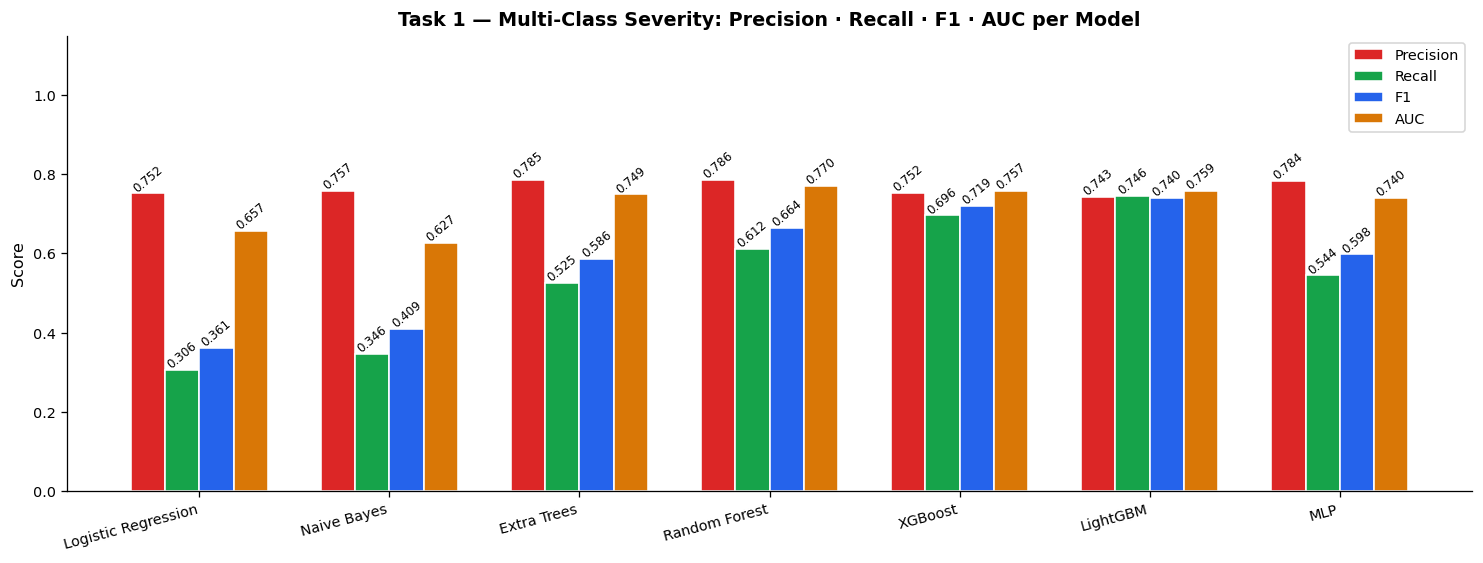

In [30]:
# ── Task 1: all-metrics bar chart ─────────────────────────────────────────────
plot_metrics_bar(
    res_t1,
    ["Precision","Recall","F1","AUC"],
    "Task 1 — Multi-Class Severity: Precision · Recall · F1 · AUC per Model",
    palette=["#DC2626","#16A34A","#2563EB","#D97706"],
)

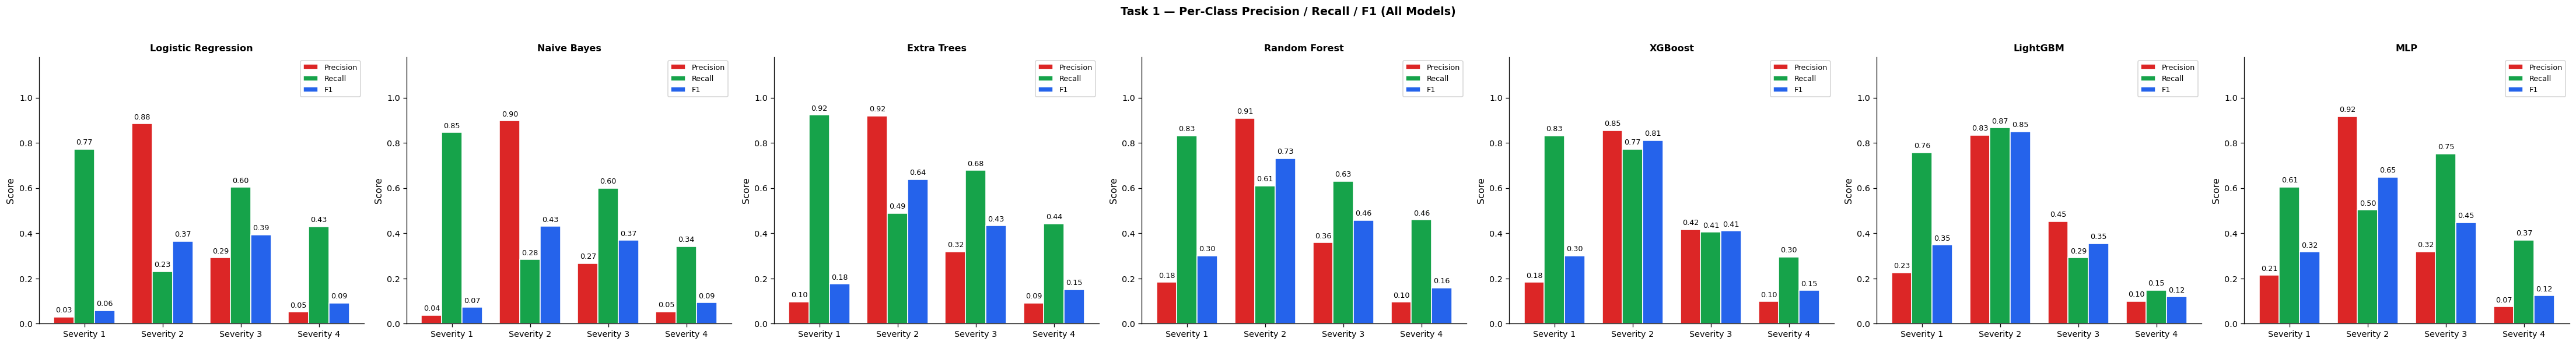

In [31]:
# ── Task 1: per-class P/R/F1 for EVERY model ─────────────────────────────────
plot_per_class_pr(
    res_t1, yte1,
    ["Severity 1","Severity 2","Severity 3","Severity 4"],
    "Task 1 — Per-Class Precision / Recall / F1 (All Models)"
)

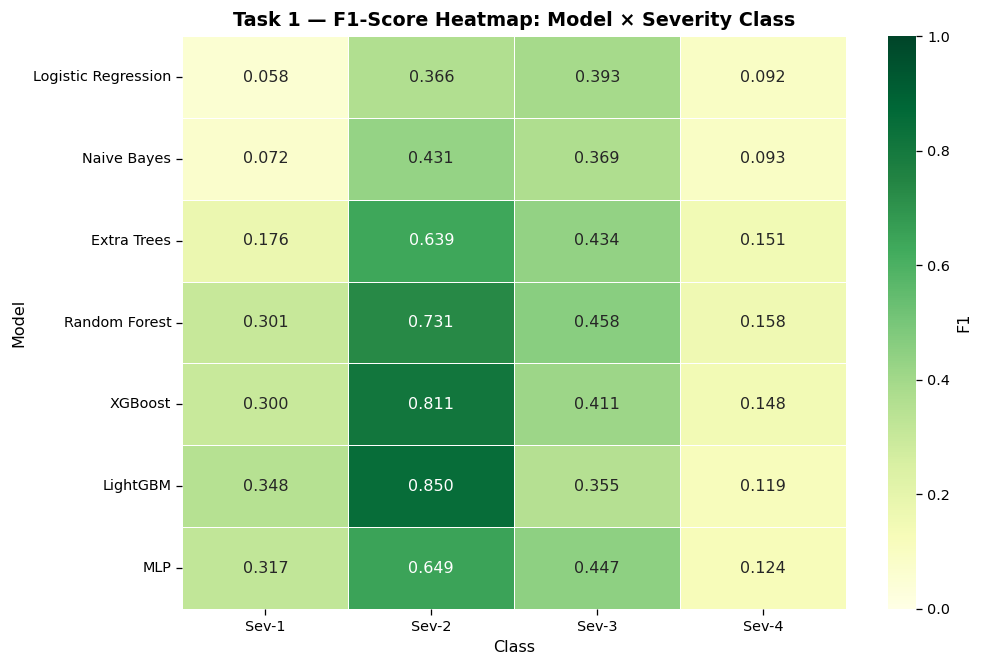

In [32]:
# ── Task 1: F1 heatmap across all models and classes ─────────────────────────
plot_f1_heatmap(
    res_t1, yte1,
    ["Sev-1","Sev-2","Sev-3","Sev-4"],
    "Task 1 — F1-Score Heatmap: Model × Severity Class"
)

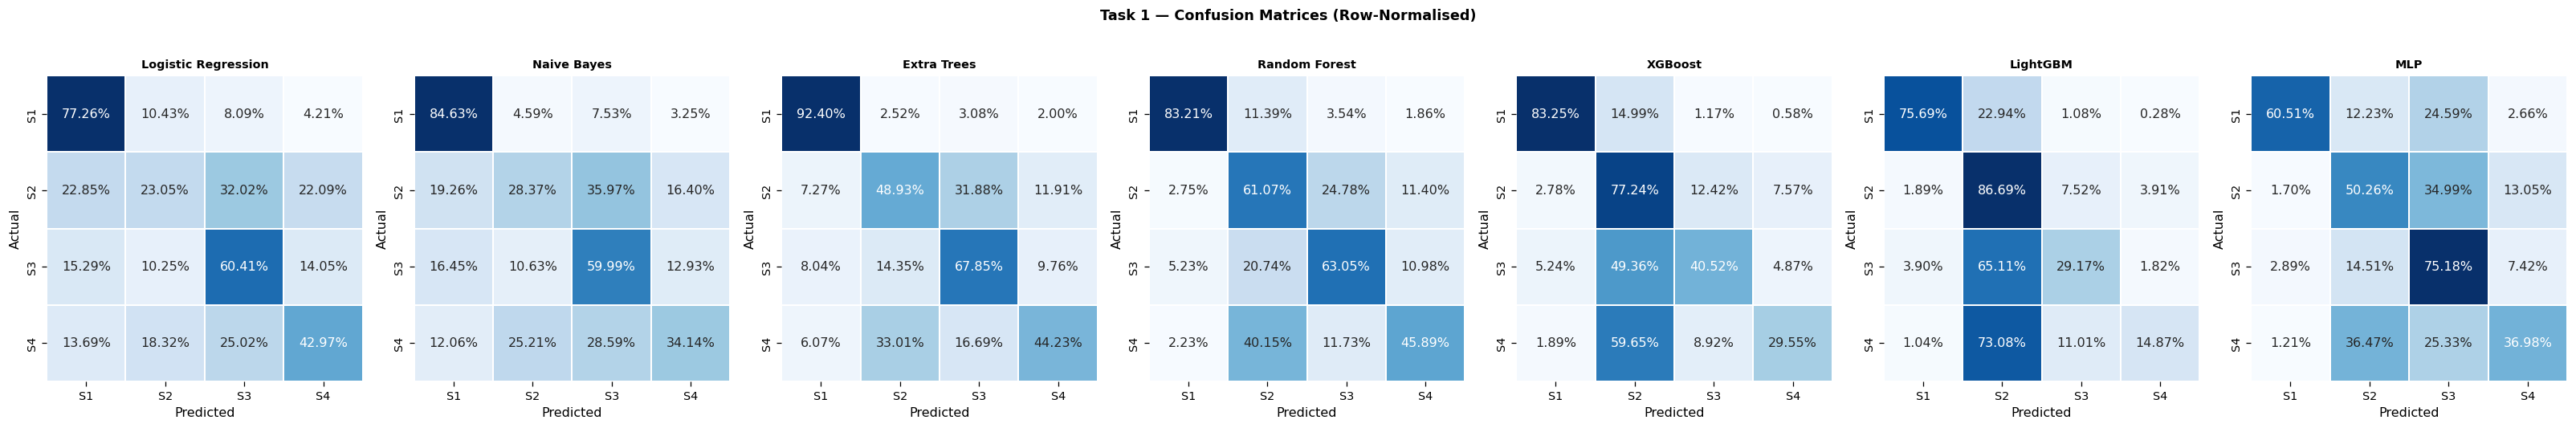

In [33]:
# ── Task 1: confusion matrices ────────────────────────────────────────────────
plot_cm_grid(res_t1, yte1, ["S1","S2","S3","S4"],
             "Task 1 — Confusion Matrices (Row-Normalised)")

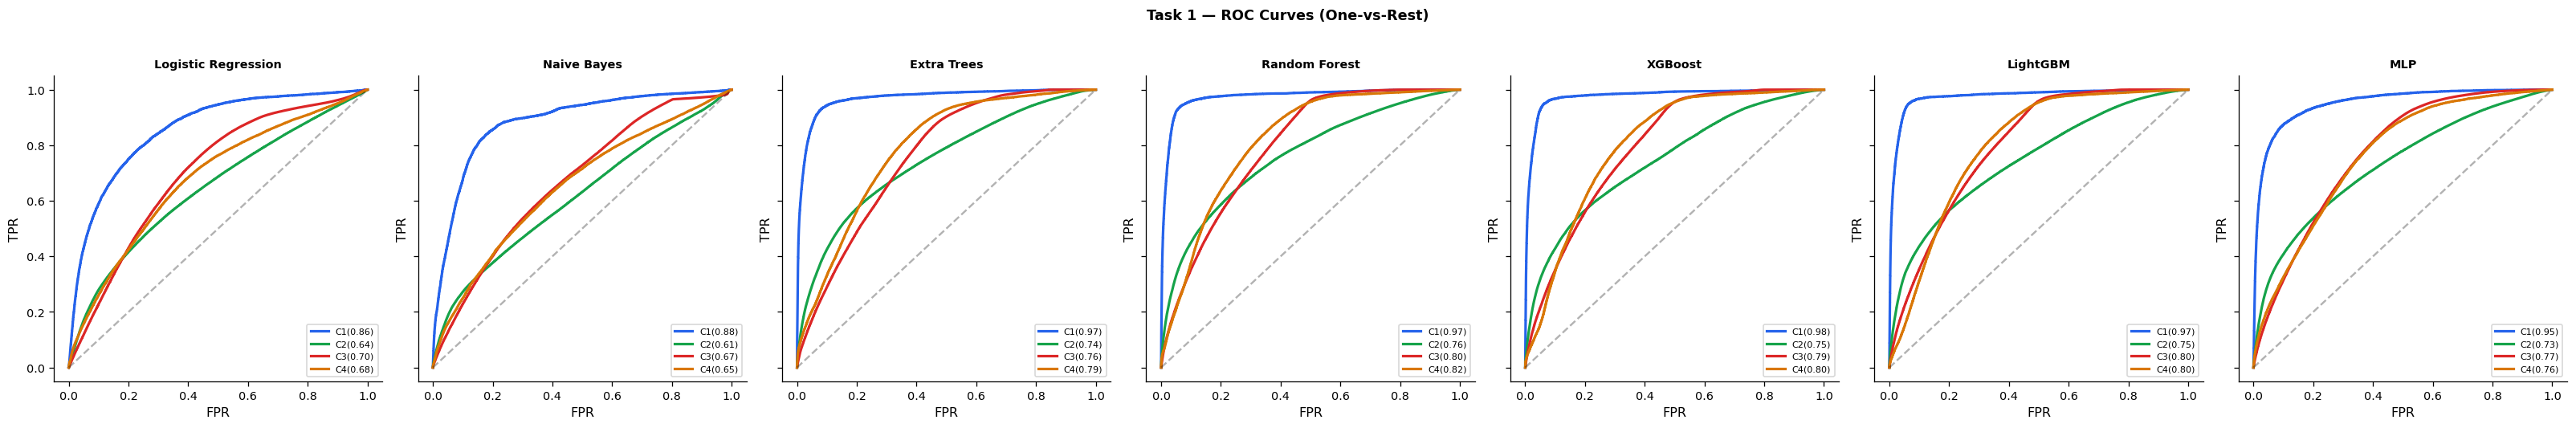

In [34]:
# ── Task 1: ROC curves (OvR) ─────────────────────────────────────────────────
plot_roc_grid(res_t1, yte1, 4, "Task 1 — ROC Curves (One-vs-Rest)")

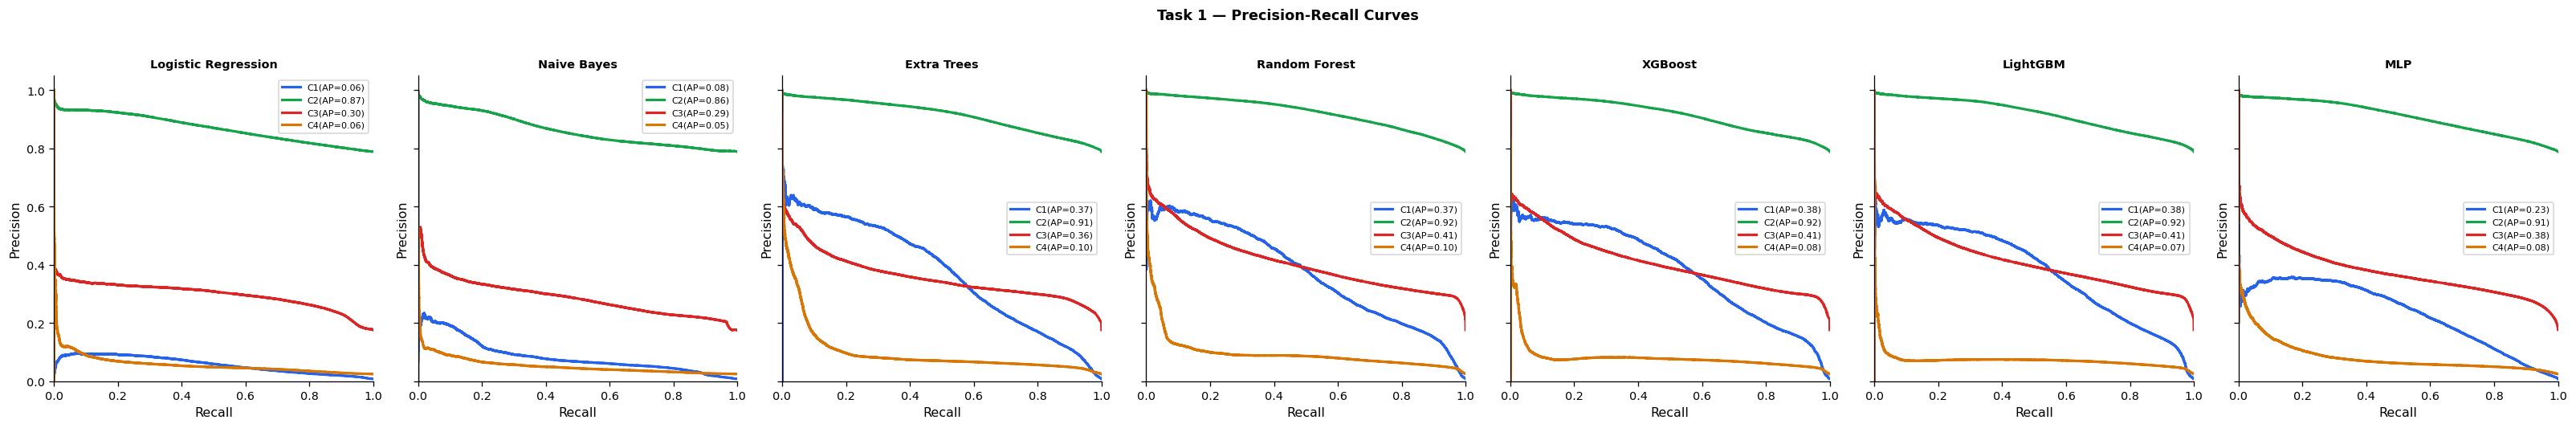

In [35]:
# ── Task 1: Precision-Recall curves ──────────────────────────────────────────
plot_pr_grid(res_t1, yte1, 4, "Task 1 — Precision-Recall Curves")

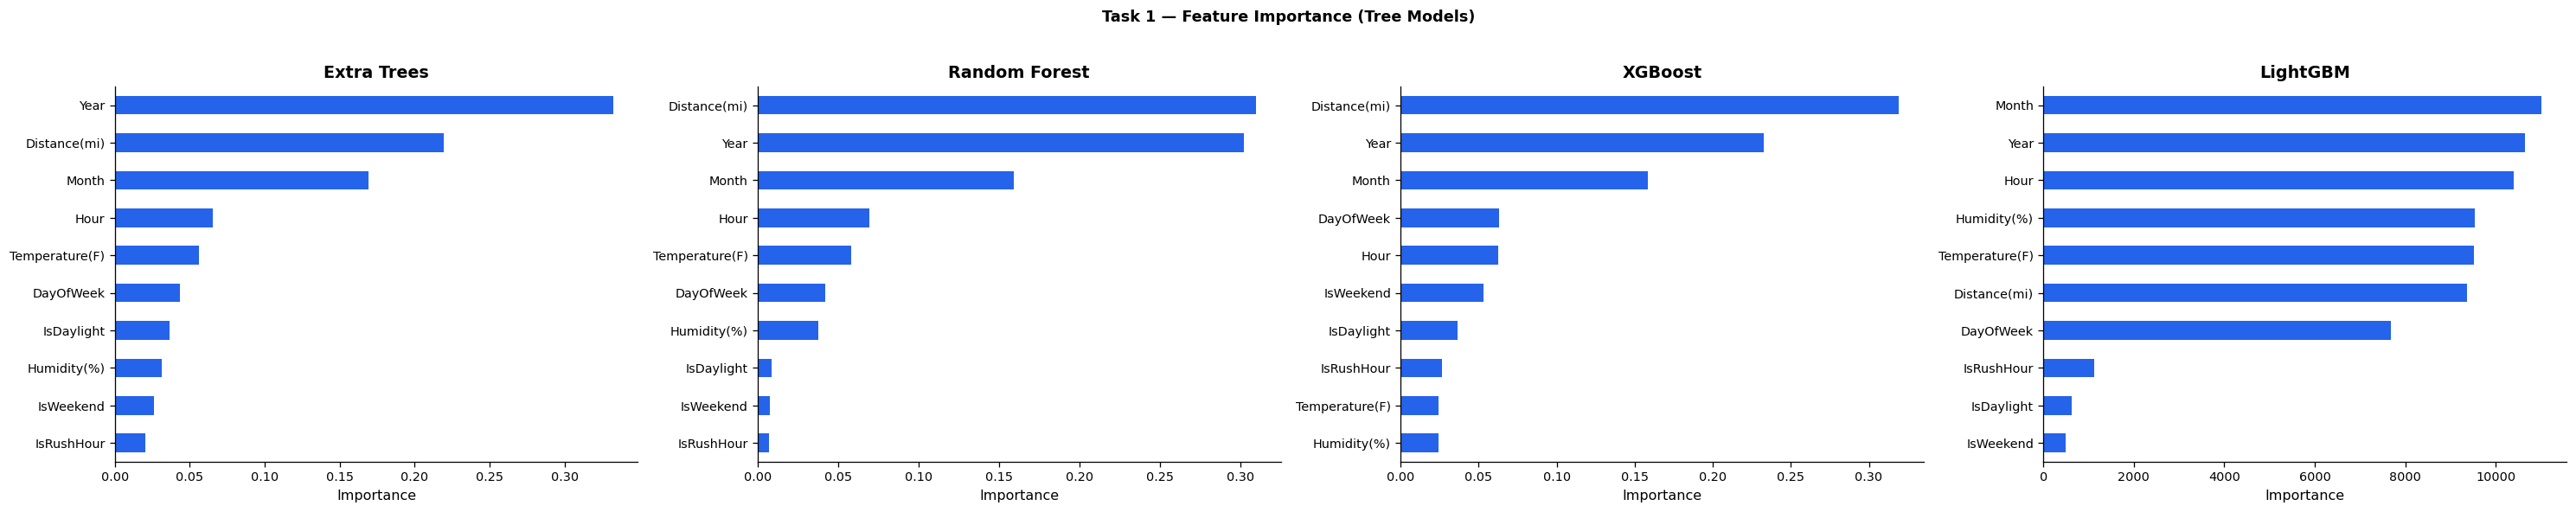

In [36]:
# ── Task 1: feature importance ────────────────────────────────────────────────
plot_fi_grid(res_t1, feats1, "Task 1 — Feature Importance (Tree Models)")

In [37]:
# ── Task 1: full classification report for best model ─────────────────────────
best_t1 = t1_df["F1"].idxmax()
print(f"\n{'='*60}")
print(f"  Best model for Task 1: {best_t1}")
print(f"  Precision (weighted) : {res_t1[best_t1]['Precision']:.4f}")
print(f"  Recall    (weighted) : {res_t1[best_t1]['Recall']:.4f}")
print(f"  F1        (weighted) : {res_t1[best_t1]['F1']:.4f}")
print(f"  ROC-AUC              : {res_t1[best_t1]['AUC']:.4f}")
print(f"{'='*60}\n")
print(classification_report(
    yte1, res_t1[best_t1]["y_pred"],
    target_names=["Severity-1","Severity-2","Severity-3","Severity-4"]))


  Best model for Task 1: LightGBM
  Precision (weighted) : 0.7434
  Recall    (weighted) : 0.7460
  F1        (weighted) : 0.7400
  ROC-AUC              : 0.7586

              precision    recall  f1-score   support

  Severity-1       0.23      0.76      0.35      9231
  Severity-2       0.83      0.87      0.85    854910
  Severity-3       0.45      0.29      0.35    191514
  Severity-4       0.10      0.15      0.12     27390

    accuracy                           0.75   1083045
   macro avg       0.40      0.52      0.42   1083045
weighted avg       0.74      0.75      0.74   1083045



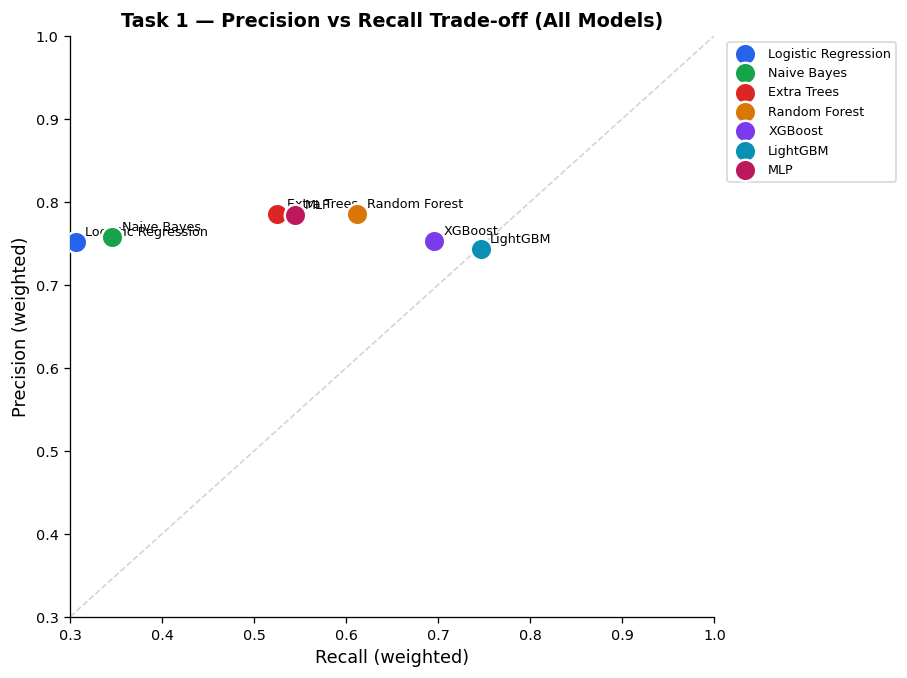

In [38]:
# ── Task 1: Precision vs Recall scatter (model comparison) ────────────────────
fig, ax = plt.subplots(figsize=(8,6))
for (name,v), clr in zip(res_t1.items(), PALETTE):
    ax.scatter(v["Recall"], v["Precision"], s=180, color=clr,
               label=name, zorder=4, edgecolors="white", linewidth=1.5)
    ax.annotate(name, (v["Recall"], v["Precision"]),
                textcoords="offset points", xytext=(6,4), fontsize=8)
ax.set_xlabel("Recall (weighted)", fontsize=11)
ax.set_ylabel("Precision (weighted)", fontsize=11)
ax.set_title("Task 1 — Precision vs Recall Trade-off (All Models)",
             fontweight="bold", fontsize=12)
ax.set_xlim(0.3, 1.0); ax.set_ylim(0.3, 1.0)
ax.plot([0,1],[0,1],"--",color="lightgray",lw=1)
ax.legend(bbox_to_anchor=(1.01,1), loc="upper left", fontsize=8)
plt.tight_layout(); plt.savefig("t1_prc_scatter.png", bbox_inches="tight"); plt.show()

---
## 🎯 Task 2 — Binary Severity Classification (Severe vs Non-Severe)

**Target:** 0 = Non-Severe (Severity 1-2) · 1 = Severe (Severity 3-4)  
**Primary metrics:** ROC-AUC · Average Precision · Precision · Recall at optimal threshold  
**Models:** Logistic Regression · Naive Bayes · Extra Trees · Random Forest · XGBoost · LightGBM · MLP  
**Imbalance handling:** SMOTE + class-weight penalties


In [39]:
print("━"*68)
print("  TASK 2 — BINARY SEVERE vs NON-SEVERE")
print("━"*68)

Xtr2, Xval2, Xte2, ytr2, yval2, yte2, feats2 = get_arrays("IsSevere")
print(f"  Class balance — Non-Severe: {(ytr2==0).sum():,} | Severe: {(ytr2==1).sum():,} "
      f"| ratio: {(ytr2==0).sum()/(ytr2==1).sum():.1f}:1")

scale_pw = float((ytr2==0).sum()) / float((ytr2==1).sum())

Xsm2, ysm2 = apply_smote(Xtr2, ytr2, cap=120_000)
del Xtr2; gc.collect()

MODELS_T2 = {
    "Logistic Regression": LogisticRegression(
        max_iter=500, C=0.5, class_weight="balanced",
        solver="lbfgs", n_jobs=-1, random_state=42),
    "Naive Bayes": GaussianNB(),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=200, max_depth=15, min_samples_leaf=8,
        class_weight="balanced", n_jobs=-1, random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=15, min_samples_leaf=8,
        class_weight="balanced", n_jobs=-1, random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pw,
        tree_method="hist", n_jobs=-1, random_state=42, verbosity=0),
    "LightGBM": LGBMClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        num_leaves=63, subsample=0.8, colsample_bytree=0.8,
        is_unbalance=True, n_jobs=-1, random_state=42, verbose=-1),
    "MLP": MLPClassifier(
        hidden_layer_sizes=(256,128,64), activation="relu", solver="adam",
        alpha=1e-4, max_iter=200, batch_size=2048,
        early_stopping=True, n_iter_no_change=15, random_state=42, verbose=False),
}

res_t2 = train_classifiers("Task2", MODELS_T2, Xsm2, ysm2, Xte2, yte2, n_classes=2)
del Xsm2, ysm2; gc.collect()
print(f"\n💾  RAM after Task 2: df={mem_mb(df):.0f} MB")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  TASK 2 — BINARY SEVERE vs NON-SEVERE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Arrays built  Xtr=193MB  Xte=41MB
  Class balance — Non-Severe: 4,032,656 | Severe: 1,021,551 | ratio: 3.9:1
  SMOTE: 120,000 → 191,982 | 7 MB

  Model                           Acc   Prec    Rec     F1    AUC      s
  ──────────────────────────────────────────────────────────────────
  Logistic Regression          0.6545 0.7702 0.6545 0.6872 0.7058   1.5s
  Naive Bayes                  0.6003 0.7565 0.6003 0.6396 0.6712   0.0s
  Extra Trees                  0.6682 0.7914 0.6682 0.7002 0.7591   6.9s
  Random Forest                0.7185 0.7985 0.7185 0.7424 0.7855  18.9s
  XGBoost                      0.5999 0.8276 0.5999 0.6358 0.7816   2.0s
  LightGBM                     0.7990 0.7707 0.7990 0.7774 0.7823   2.1s
  MLP                          0.6897 0.7825 0.6897 0.7174 0.7512 172.2s

💾  RAM after Task 2: df

In [40]:
# Add Average Precision
for n,v in res_t2.items():
    v["AvgPrecision"] = (round(average_precision_score(yte2, v["y_prob"][:,1]),4)
                         if v["y_prob"] is not None else np.nan)

display(HTML("<h4>📊 Task 2 — Complete Results Table (sorted by AUC)</h4>"))
t2_df = styled_table(res_t2,
    ["Accuracy","Precision","Recall","F1","AUC","AvgPrecision","Time"],
    sort_by="AUC")

,Accuracy,Precision,Recall,F1,AUC,AvgPrecision,Time
Model,,,,,,,
Random Forest,0.718500,0.798500,0.718500,0.742400,0.785500,0.454500,18.9s
LightGBM,0.799000,0.770700,0.799000,0.777400,0.782300,0.452600,2.1s
XGBoost,0.599900,0.827600,0.599900,0.635800,0.781600,0.450600,2.0s
Extra Trees,0.668200,0.791400,0.668200,0.700200,0.759100,0.422500,6.9s
MLP,0.689700,0.782500,0.689700,0.717400,0.751200,0.411000,172.2s
Logistic Regression,0.654500,0.770200,0.654500,0.687200,0.705800,0.345500,1.5s
Naive Bayes,0.600300,0.756500,0.600300,0.639600,0.671200,0.331600,0.0s


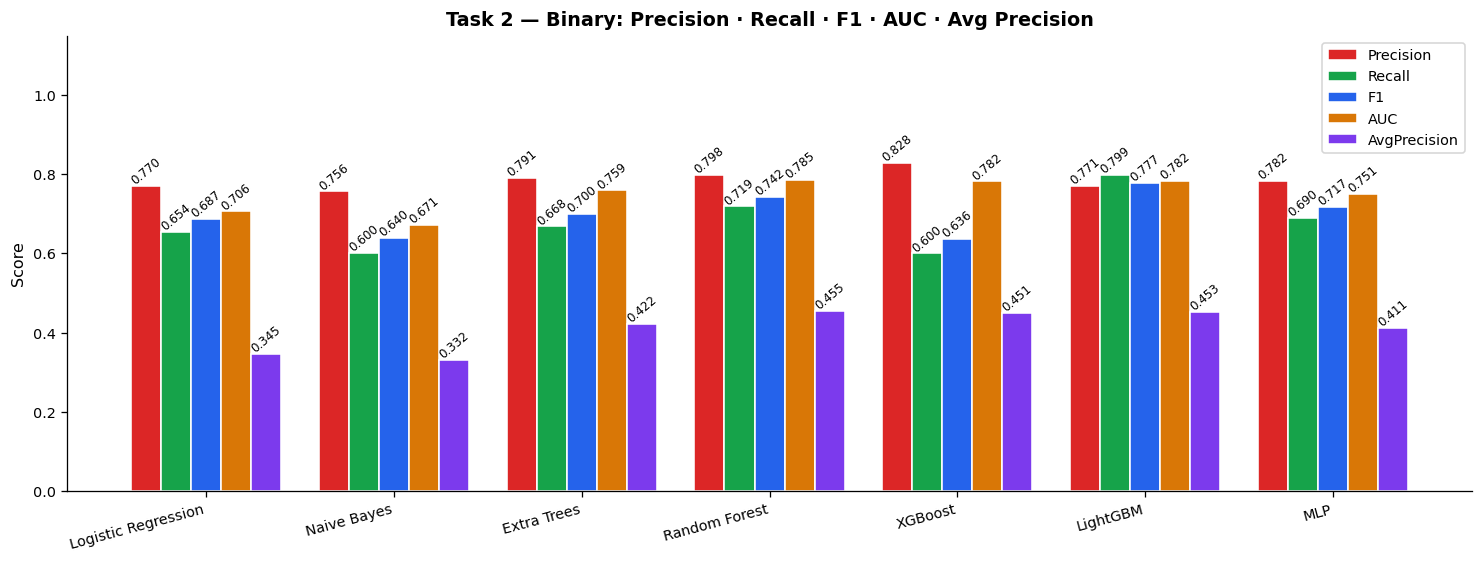

In [41]:
plot_metrics_bar(
    res_t2,
    ["Precision","Recall","F1","AUC","AvgPrecision"],
    "Task 2 — Binary: Precision · Recall · F1 · AUC · Avg Precision",
    palette=["#DC2626","#16A34A","#2563EB","#D97706","#7C3AED"],
)

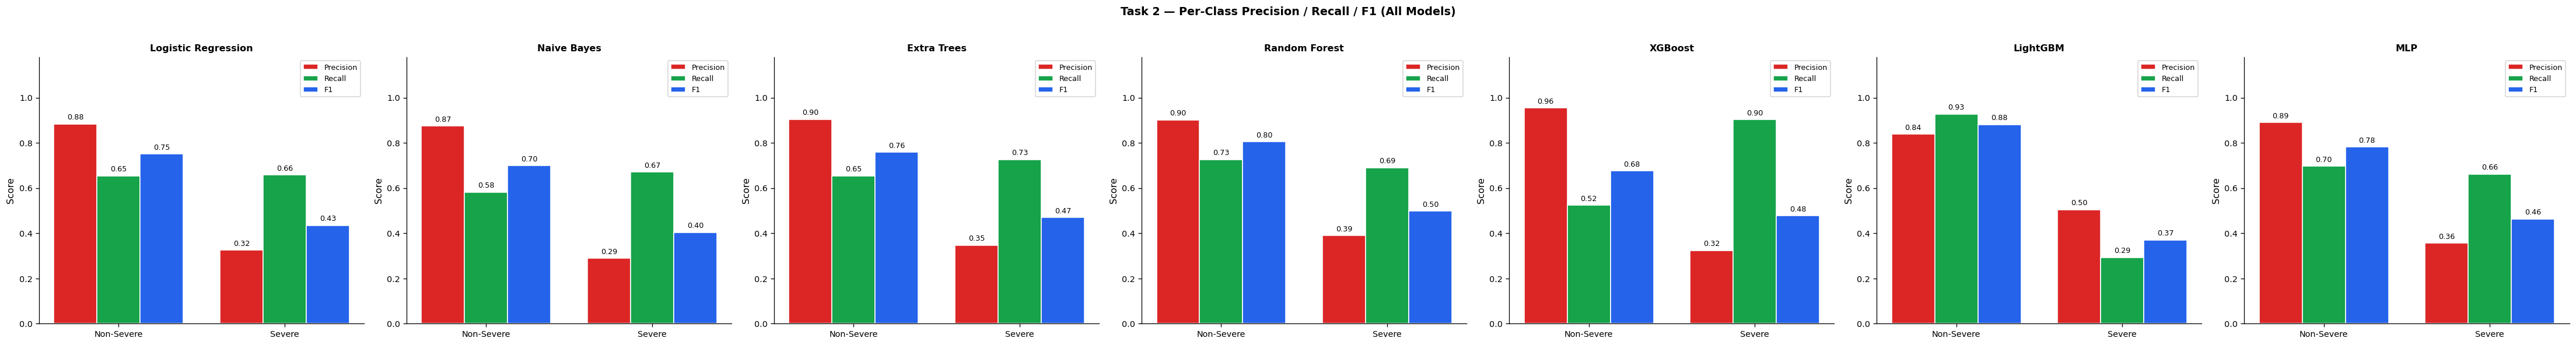

In [42]:
# ── Task 2: per-class P/R/F1 ─────────────────────────────────────────────────
plot_per_class_pr(
    res_t2, yte2,
    ["Non-Severe","Severe"],
    "Task 2 — Per-Class Precision / Recall / F1 (All Models)"
)

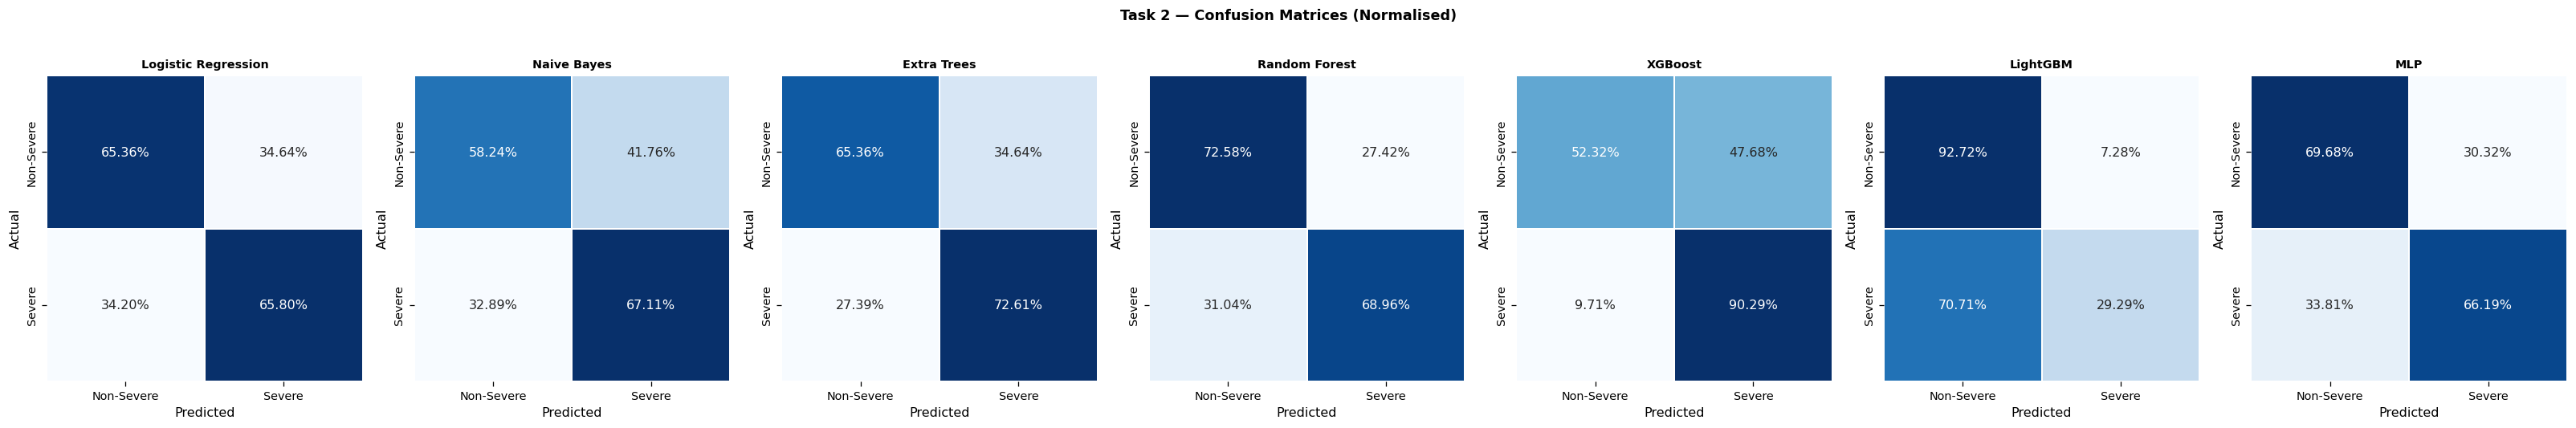

In [43]:
plot_cm_grid(res_t2, yte2, ["Non-Severe","Severe"],
             "Task 2 — Confusion Matrices (Normalised)")

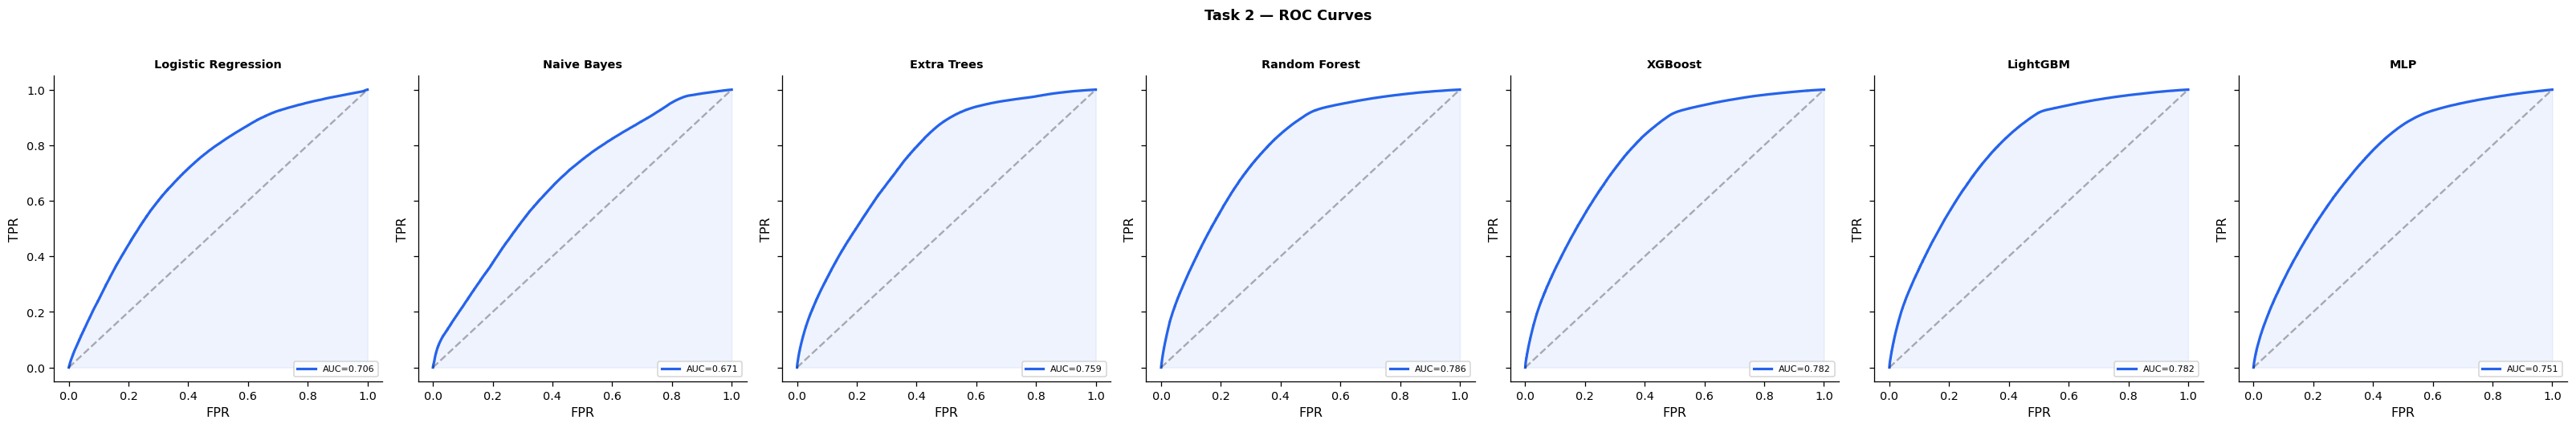

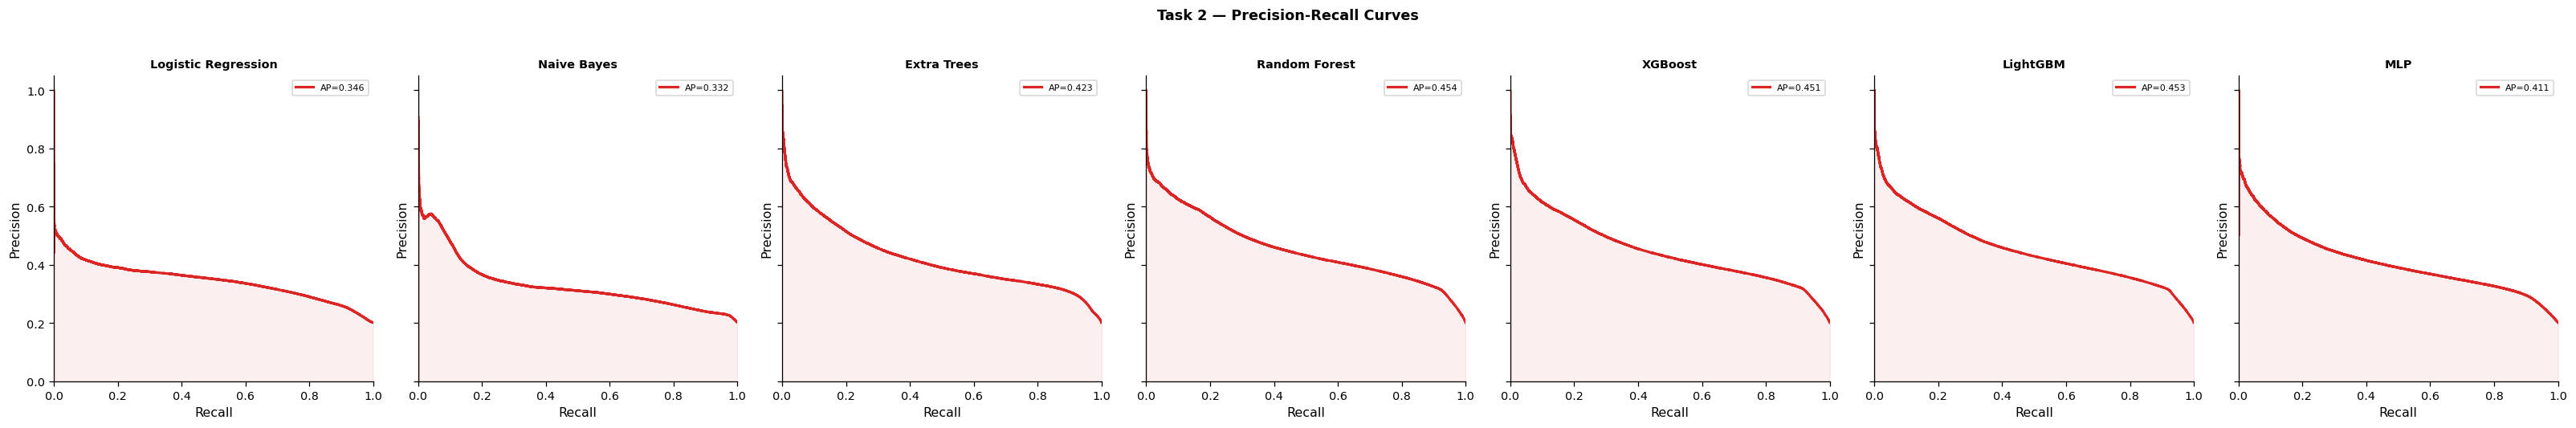

In [44]:
plot_roc_grid(res_t2, yte2, 2, "Task 2 — ROC Curves")
plot_pr_grid (res_t2, yte2, 2, "Task 2 — Precision-Recall Curves")

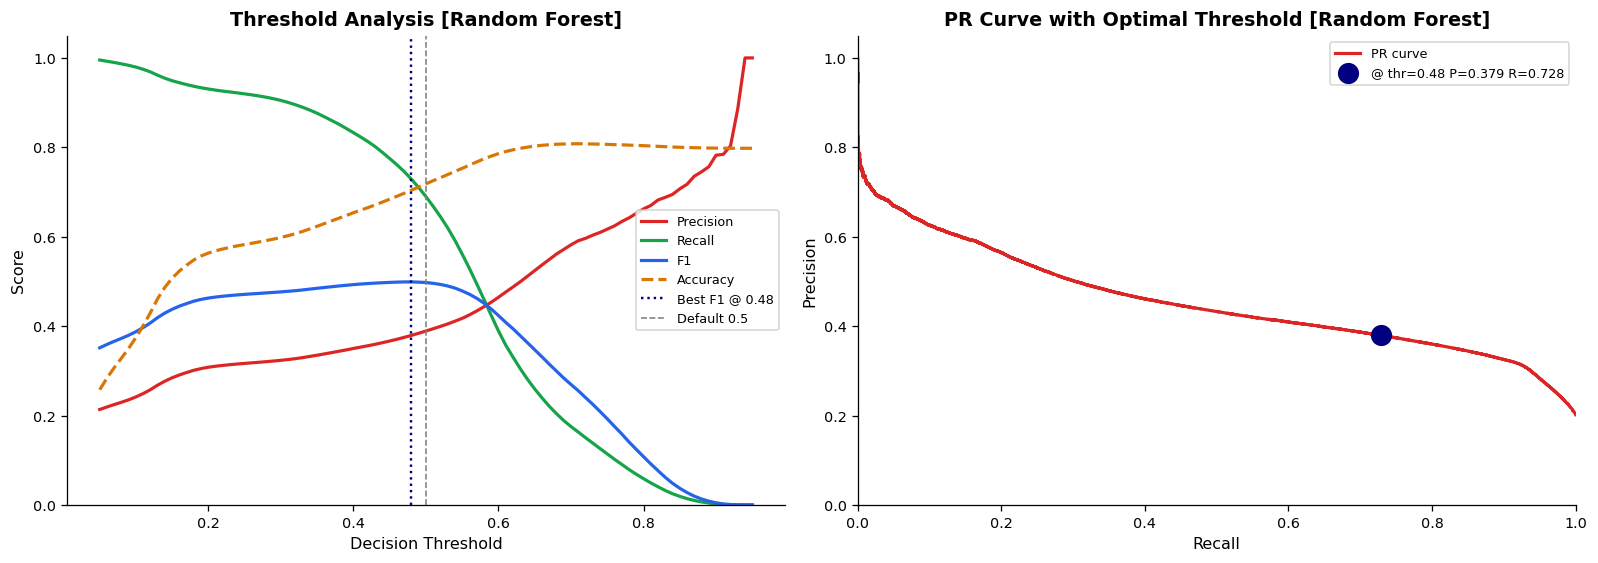

Optimal threshold: 0.48  Precision=0.3794  Recall=0.7285  F1=0.4989

Full classification report — Random Forest

              precision    recall  f1-score   support

  Non-Severe       0.90      0.73      0.80    864141
      Severe       0.39      0.69      0.50    218904

    accuracy                           0.72   1083045
   macro avg       0.65      0.71      0.65   1083045
weighted avg       0.80      0.72      0.74   1083045



In [45]:
# ── Task 2: threshold analysis for best model ─────────────────────────────────
best_t2 = t2_df["AUC"].idxmax()
if res_t2[best_t2]["y_prob"] is not None:
    probs = res_t2[best_t2]["y_prob"][:,1]
    thrs  = np.linspace(0.05, 0.95, 91)
    P, R, F1_l, ACC = [], [], [], []
    for thr in thrs:
        yp = (probs>=thr).astype(int)
        P.append  (precision_score(yte2,yp,zero_division=0))
        R.append  (recall_score   (yte2,yp,zero_division=0))
        F1_l.append(f1_score      (yte2,yp,zero_division=0))
        ACC.append (accuracy_score (yte2,yp))

    best_thr = thrs[int(np.argmax(F1_l))]
    fig, axes = plt.subplots(1,2,figsize=(14,5))

    axes[0].plot(thrs,P,   color="#DC2626",lw=2,label="Precision")
    axes[0].plot(thrs,R,   color="#16A34A",lw=2,label="Recall")
    axes[0].plot(thrs,F1_l,color="#2563EB",lw=2,label="F1")
    axes[0].plot(thrs,ACC, color="#D97706",lw=2,label="Accuracy",linestyle="--")
    axes[0].axvline(best_thr,color="navy",linestyle=":",lw=1.5,
                    label=f"Best F1 @ {best_thr:.2f}")
    axes[0].axvline(0.5,color="gray",linestyle="--",lw=1,label="Default 0.5")
    axes[0].set_xlabel("Decision Threshold"); axes[0].set_ylabel("Score")
    axes[0].set_title(f"Threshold Analysis [{best_t2}]",fontweight="bold")
    axes[0].legend(); axes[0].set_ylim(0,1.05)

    # P-R tradeoff at best threshold
    yp_opt = (probs>=best_thr).astype(int)
    prec_opt = precision_score(yte2,yp_opt,zero_division=0)
    rec_opt  = recall_score   (yte2,yp_opt,zero_division=0)
    prec_c,rec_c,_ = precision_recall_curve(yte2,probs)
    axes[1].plot(rec_c,prec_c,color="#DC2626",lw=2,label="PR curve")
    axes[1].scatter([rec_opt],[prec_opt],s=150,color="navy",zorder=5,
                    label=f"@ thr={best_thr:.2f} P={prec_opt:.3f} R={rec_opt:.3f}")
    axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
    axes[1].set_title(f"PR Curve with Optimal Threshold [{best_t2}]",fontweight="bold")
    axes[1].legend(); axes[1].set_xlim([0,1]); axes[1].set_ylim([0,1.05])

    plt.tight_layout()
    plt.savefig("t2_threshold.png",bbox_inches="tight"); plt.show()
    print(f"Optimal threshold: {best_thr:.2f}  "
          f"Precision={prec_opt:.4f}  Recall={rec_opt:.4f}  F1={max(F1_l):.4f}")

print(f"\nFull classification report — {best_t2}\n")
print(classification_report(yte2,res_t2[best_t2]["y_pred"],
      target_names=["Non-Severe","Severe"]))

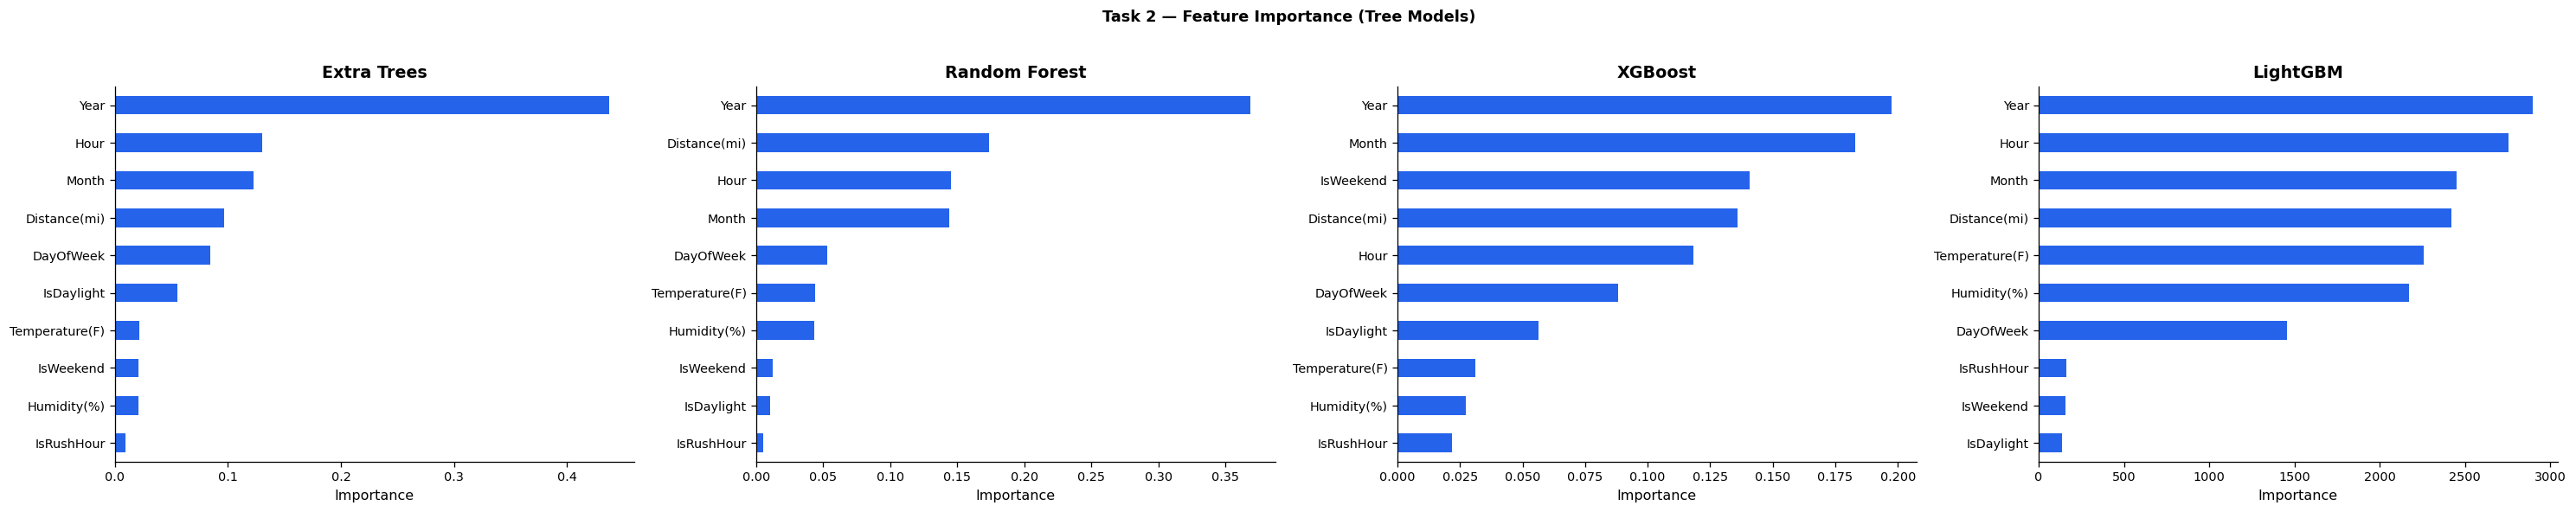

In [46]:
plot_fi_grid(res_t2, feats2, "Task 2 — Feature Importance (Tree Models)")

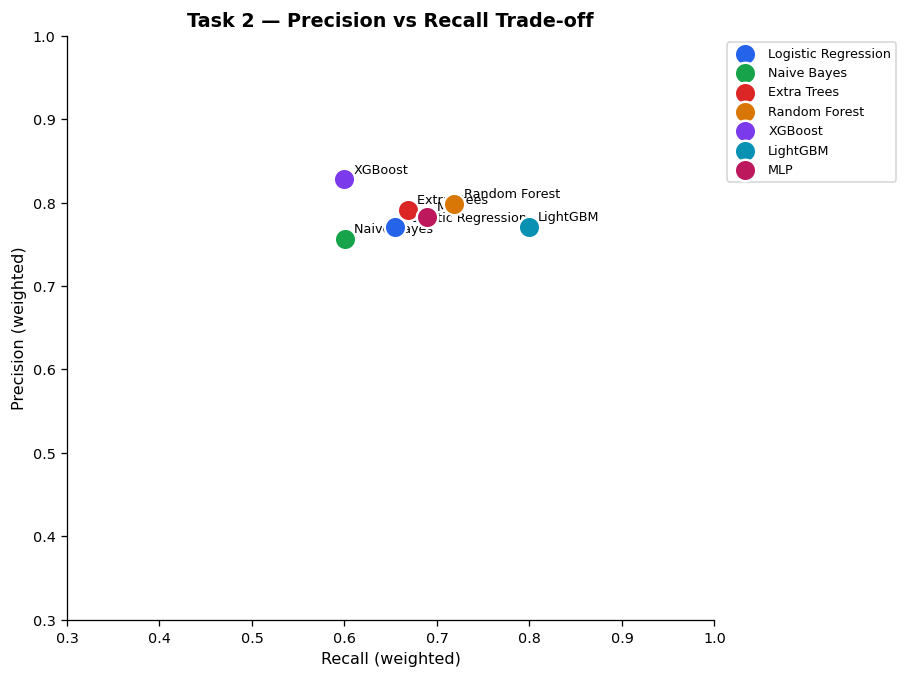

In [47]:
# ── Task 2: Precision vs Recall scatter ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(8,6))
for (name,v),clr in zip(res_t2.items(),PALETTE):
    ax.scatter(v["Recall"],v["Precision"],s=180,color=clr,
               label=name,zorder=4,edgecolors="white",linewidth=1.5)
    ax.annotate(name,(v["Recall"],v["Precision"]),
                textcoords="offset points",xytext=(6,4),fontsize=8)
ax.set_xlabel("Recall (weighted)"); ax.set_ylabel("Precision (weighted)")
ax.set_title("Task 2 — Precision vs Recall Trade-off",fontweight="bold",fontsize=12)
ax.set_xlim(0.3,1.0); ax.set_ylim(0.3,1.0)
ax.legend(bbox_to_anchor=(1.01,1),loc="upper left",fontsize=8)
plt.tight_layout(); plt.savefig("t2_prc_scatter.png",bbox_inches="tight"); plt.show()

---
## 🎯 Task 3 — Accident Duration Regression

**Target:** Accident duration in minutes (continuous, 0–1440)  
**Primary metrics:** MAE · RMSE · R² · MAPE  
**Models:** Ridge · Lasso · Extra Trees · Random Forest · XGBoost · LightGBM · MLP  
**Note:** Severity is included as a predictor (it is not the target here)


In [48]:
print("━"*68)
print("  TASK 3 — ACCIDENT DURATION REGRESSION")
print("━"*68)

if "Duration_min" not in df.columns:
    print("⚠️  Duration_min column missing. Check ingestion step.")
else:
    Xtr3, Xval3, Xte3, ytr3, yval3, yte3, feats3 = get_arrays(
        "Duration_min", extra_feats=["Severity"])

    print(f"  Target stats:")
    for stat,val in [("Mean",ytr3.mean()),("Median",float(np.median(ytr3))),
                     ("Std",ytr3.std()),("Min",ytr3.min()),("Max",ytr3.max())]:
        print(f"    {stat:<8}: {val:>8.1f} min")

    MODELS_T3 = {
        "Ridge": Ridge(alpha=10.0),
        "Lasso": Lasso(alpha=0.5, max_iter=2000),
        "Extra Trees": ExtraTreesRegressor(
            n_estimators=200, max_depth=15, min_samples_leaf=10,
            n_jobs=-1, random_state=42),
        "Random Forest": RandomForestRegressor(
            n_estimators=200, max_depth=15, min_samples_leaf=10,
            n_jobs=-1, random_state=42),
        "XGBoost": XGBRegressor(
            n_estimators=300, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            tree_method="hist", n_jobs=-1, random_state=42, verbosity=0),
        "LightGBM": LGBMRegressor(
            n_estimators=300, max_depth=6, learning_rate=0.05,
            num_leaves=63, subsample=0.8, colsample_bytree=0.8,
            n_jobs=-1, random_state=42, verbose=-1),
        "MLP": MLPRegressor(
            hidden_layer_sizes=(256,128,64), activation="relu", solver="adam",
            alpha=1e-4, max_iter=200, batch_size=2048,
            early_stopping=True, n_iter_no_change=15, random_state=42, verbose=False),
    }

    res_t3 = train_regressors("Task3", MODELS_T3, Xtr3, ytr3, Xte3, yte3)
    del Xtr3; gc.collect()
    print(f"\n💾  RAM after Task 3: df={mem_mb(df):.0f} MB")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  TASK 3 — ACCIDENT DURATION REGRESSION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Arrays built  Xtr=212MB  Xte=45MB
  Target stats:
    Mean    :    100.9 min
    Median  :     60.0 min
    Std     :    133.6 min
    Min     :      1.2 min
    Max     :   1440.0 min

  Model                             MAE     RMSE       R²    MAPE%      s
  ──────────────────────────────────────────────────────────────────
  Ridge                           70.35   131.37   0.0339  106.21%   0.4s
  Lasso                           70.50   131.39   0.0337  106.46%   0.7s
  Extra Trees                     42.63   103.81   0.3968   59.71% 1079.4s
  Random Forest                   41.29   103.11   0.4049   56.89% 1421.0s
  XGBoost                         44.59   105.79   0.3735   62.16%  58.1s
  LightGBM                        44.23   105.53   0.3766   61.68%  52.5s
  MLP                             42.83   103

In [49]:
if "res_t3" in dir():
    display(HTML("<h4>📊 Task 3 — Complete Regression Results Table (sorted by R²)</h4>"))
    t3_df = styled_table(res_t3,
        ["MAE","RMSE","R2","MAPE","Time"], sort_by="R2")

,MAE,RMSE,R2,MAPE,Time
Model,,,,,
Random Forest,41.290000,103.110000,0.404900,56.890000,1421.0s
MLP,42.830000,103.190000,0.404000,60.820000,6200.6s
Extra Trees,42.630000,103.810000,0.396800,59.710000,1079.4s
LightGBM,44.230000,105.530000,0.376600,61.680000,52.5s
XGBoost,44.590000,105.790000,0.373500,62.160000,58.1s
Ridge,70.350000,131.370000,0.033900,106.209999,0.4s
Lasso,70.500000,131.390000,0.033700,106.459999,0.7s


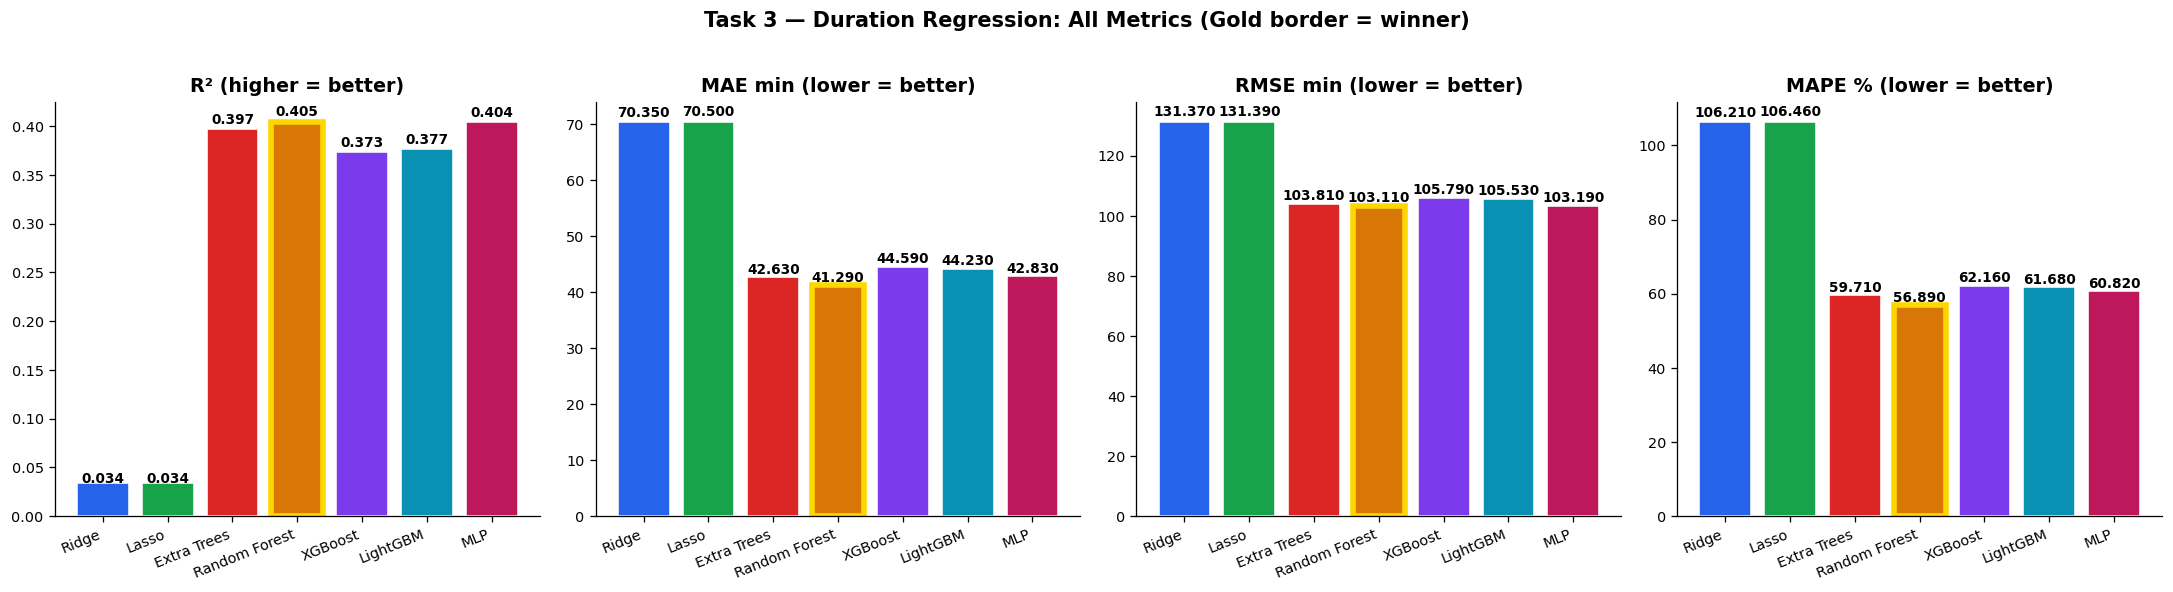

In [50]:
if "res_t3" in dir():
    # ── Metrics bar chart ─────────────────────────────────────────────────────
    names = list(res_t3.keys())
    fig, axes = plt.subplots(1,4,figsize=(19,5))
    for ax,(metric,label,hi) in zip(axes,[
        ("R2",  "R² (higher = better)",   True),
        ("MAE", "MAE min (lower = better)",False),
        ("RMSE","RMSE min (lower = better)",False),
        ("MAPE","MAPE % (lower = better)", False),
    ]):
        vals  = [res_t3[m][metric] for m in names]
        bars  = ax.bar(names, vals, color=PALETTE[:len(names)], edgecolor="white")
        best  = vals.index(max(vals) if hi else min(vals))
        bars[best].set_edgecolor("gold"); bars[best].set_linewidth(3.5)
        for b,v in zip(bars,vals):
            ax.text(b.get_x()+b.get_width()/2, b.get_height()*1.015,
                    f"{v:.3f}", ha="center", fontsize=8.5, fontweight="bold")
        ax.set_title(label, fontweight="bold")
        ax.set_xticklabels(names, rotation=22, ha="right")
    plt.suptitle("Task 3 — Duration Regression: All Metrics (Gold border = winner)",
                 fontweight="bold", y=1.02, fontsize=13)
    plt.tight_layout()
    plt.savefig("t3_metrics.png", bbox_inches="tight"); plt.show()

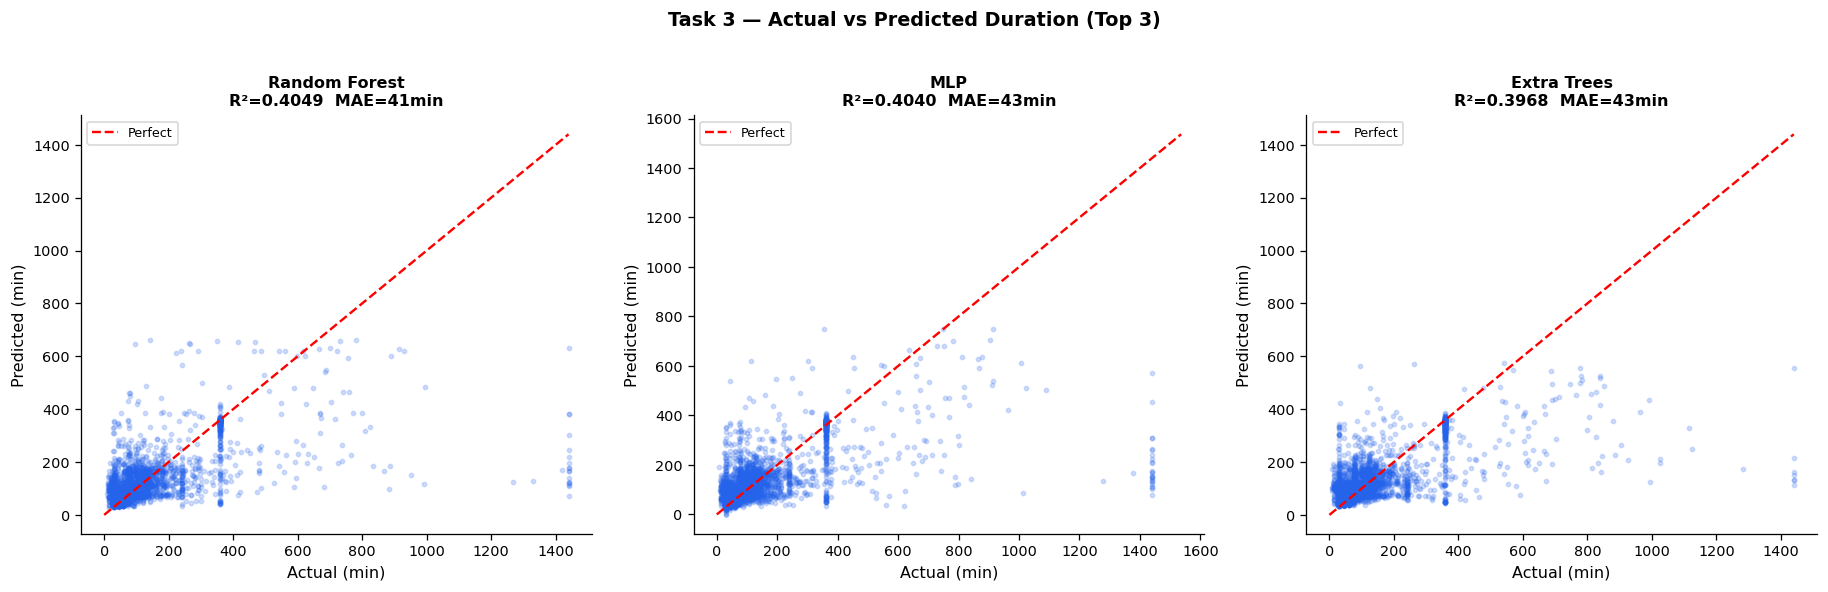

In [51]:
if "res_t3" in dir():
    # ── Actual vs Predicted – top 3 models ───────────────────────────────────
    top3 = t3_df.head(3).index.tolist()
    rng  = np.random.default_rng(0)
    fig, axes = plt.subplots(1,3,figsize=(16,5))
    for ax,name in zip(axes,top3):
        yp   = res_t3[name]["y_pred"]
        sidx = rng.choice(len(yte3), min(5000,len(yte3)), replace=False)
        ax.scatter(yte3[sidx], yp[sidx], alpha=0.2, s=7, color="#2563EB")
        lim = [0, float(max(yte3.max(), yp.max()))]
        ax.plot(lim,lim,"r--",lw=1.5,label="Perfect")
        ax.set_title(f"{name}\nR²={res_t3[name]['R2']:.4f}  MAE={res_t3[name]['MAE']:.0f}min",
                     fontweight="bold",fontsize=10)
        ax.set_xlabel("Actual (min)"); ax.set_ylabel("Predicted (min)"); ax.legend()
    plt.suptitle("Task 3 — Actual vs Predicted Duration (Top 3)",
                 fontweight="bold",y=1.02); plt.tight_layout()
    plt.savefig("t3_actual_pred.png",bbox_inches="tight"); plt.show()

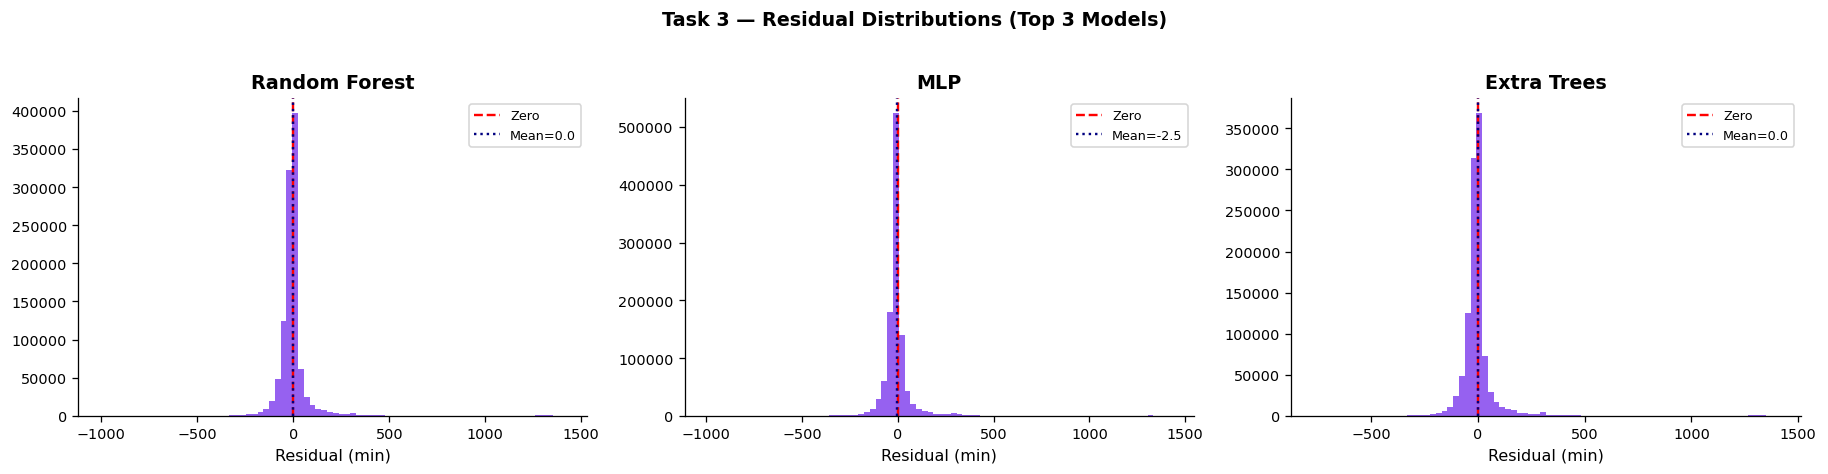

In [52]:
if "res_t3" in dir():
    # ── Residual distributions ────────────────────────────────────────────────
    top3 = t3_df.head(3).index.tolist()
    fig, axes = plt.subplots(1,3,figsize=(16,4))
    for ax,name in zip(axes,top3):
        resid = yte3 - res_t3[name]["y_pred"]
        ax.hist(resid, bins=80, color="#7C3AED", edgecolor="none", alpha=0.8)
        ax.axvline(0,          color="red",  lw=1.5, linestyle="--", label="Zero")
        ax.axvline(resid.mean(),color="navy",lw=1.5, linestyle=":",
                   label=f"Mean={resid.mean():.1f}")
        ax.set_title(f"{name}", fontweight="bold")
        ax.set_xlabel("Residual (min)"); ax.legend(fontsize=8)
    plt.suptitle("Task 3 — Residual Distributions (Top 3 Models)",
                 fontweight="bold",y=1.02)
    plt.tight_layout(); plt.savefig("t3_residuals.png",bbox_inches="tight"); plt.show()

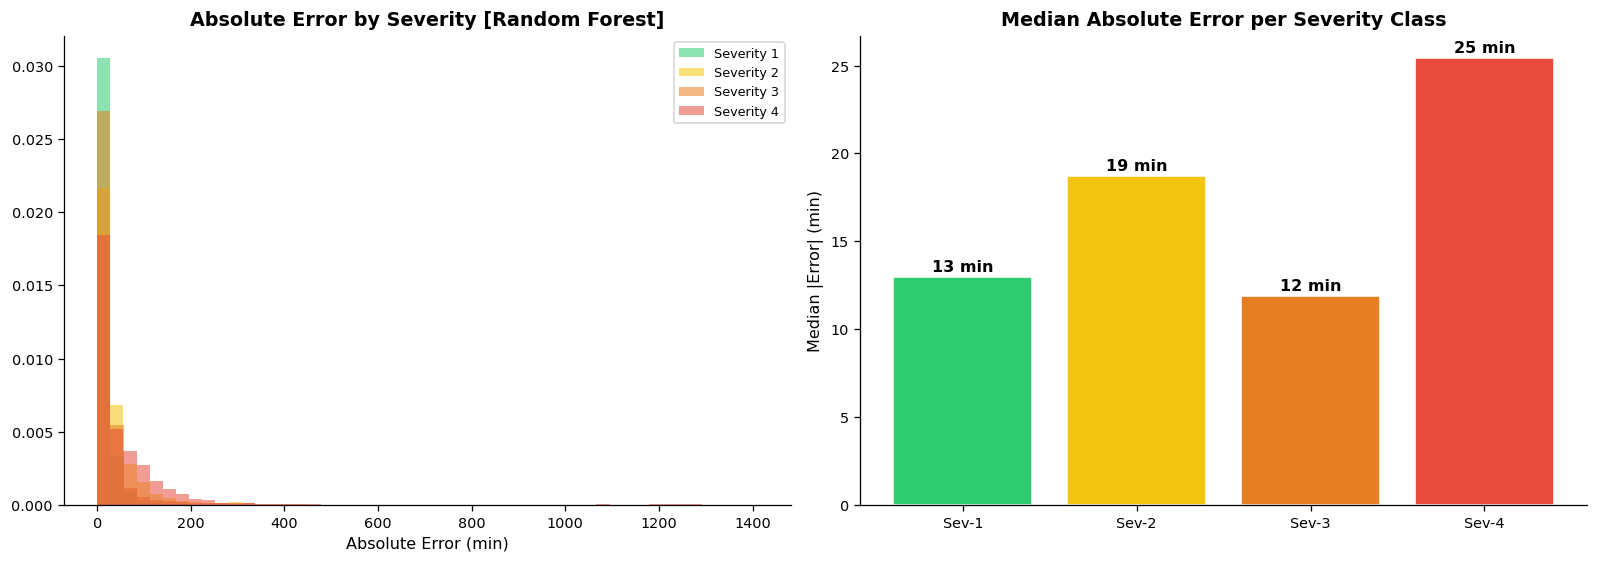

In [53]:
if "res_t3" in dir():
    # ── Prediction error segmented by Severity ────────────────────────────────
    best_t3  = t3_df["R2"].idxmax()
    yp_best  = res_t3[best_t3]["y_pred"]
    abs_err  = np.abs(yte3 - yp_best)
    sev_test = df.iloc[idx_te]["Severity"].values

    fig, axes = plt.subplots(1,2,figsize=(14,5))
    for sev in sorted(np.unique(sev_test)):
        mask = sev_test==sev
        axes[0].hist(abs_err[mask], bins=50, alpha=0.55, density=True,
                     label=f"Severity {sev}", color=SEV_COLOR.get(int(sev),"gray"))
    axes[0].set_title(f"Absolute Error by Severity [{best_t3}]",fontweight="bold")
    axes[0].set_xlabel("Absolute Error (min)"); axes[0].legend()

    med_err = [np.median(abs_err[sev_test==s]) for s in sorted(np.unique(sev_test))]
    bars = axes[1].bar([f"Sev-{s}" for s in sorted(np.unique(sev_test))], med_err,
                        color=[SEV_COLOR.get(int(s),"gray") for s in sorted(np.unique(sev_test))],
                        edgecolor="white")
    for b,v in zip(bars,med_err):
        axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+0.3,
                     f"{v:.0f} min", ha="center", fontsize=10, fontweight="bold")
    axes[1].set_title("Median Absolute Error per Severity Class",fontweight="bold")
    axes[1].set_ylabel("Median |Error| (min)")

    plt.tight_layout(); plt.savefig("t3_err_by_sev.png",bbox_inches="tight"); plt.show()

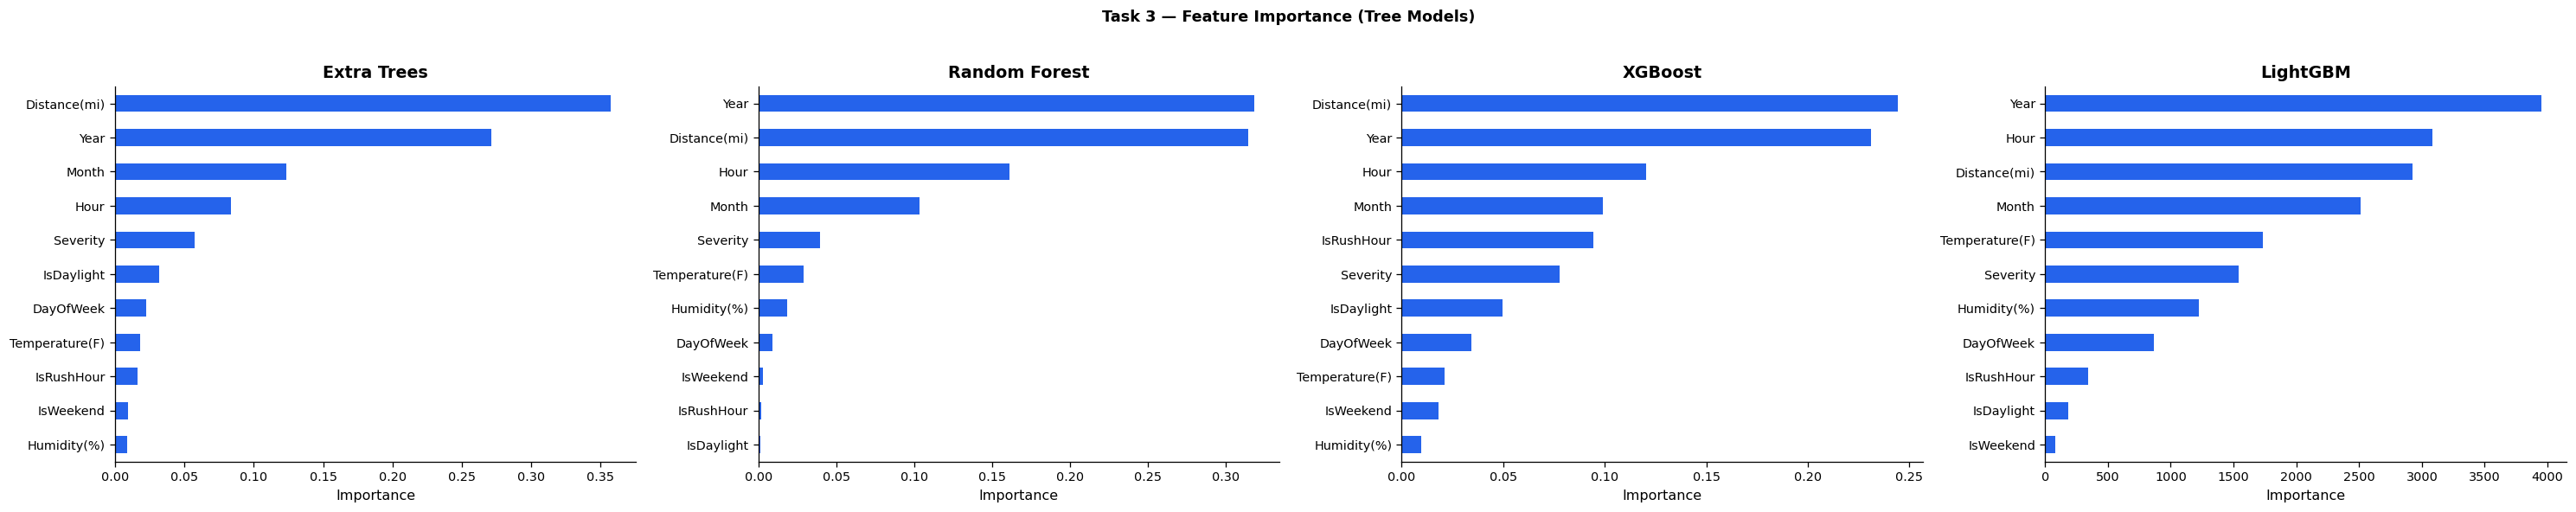

In [54]:
if "res_t3" in dir():
    plot_fi_grid(res_t3, feats3, "Task 3 — Feature Importance (Tree Models)")

---
## 🏆 Grand Summary — Cross-Task Results & Final Comparison

In [55]:
print("="*72)
print("  GRAND SUMMARY — ALL THREE TASKS")
print("="*72)

model_order = ["Logistic Regression","Naive Bayes","Extra Trees",
               "Random Forest","XGBoost","LightGBM","MLP"]
reg_alias   = {"Logistic Regression":"Ridge","Naive Bayes":"Lasso",
               "Extra Trees":"Extra Trees"}

rows = []
for m in model_order:
    row = {"Model":m}
    if m in res_t1:
        row["T1 Prec"]  = res_t1[m]["Precision"]
        row["T1 Rec"]   = res_t1[m]["Recall"]
        row["T1 F1"]    = res_t1[m]["F1"]
    if m in res_t2:
        row["T2 Prec"]  = res_t2[m]["Precision"]
        row["T2 Rec"]   = res_t2[m]["Recall"]
        row["T2 AUC"]   = res_t2[m]["AUC"]
    rname = reg_alias.get(m, m)
    if "res_t3" in dir() and rname in res_t3:
        row["T3 MAE"]   = res_t3[rname]["MAE"]
        row["T3 R²"]    = res_t3[rname]["R2"]
    rows.append(row)

grand_df = pd.DataFrame(rows).set_index("Model").fillna(np.nan)
hi = [c for c in grand_df.columns if "Prec" in c or "Rec" in c
      or "F1" in c or "AUC" in c or "R²" in c]
lo = [c for c in grand_df.columns if "MAE" in c]
display(HTML("<h4>📊 Grand Cross-Task Summary Table</h4>"))
display(grand_df.style
    .background_gradient(cmap="YlGn",     subset=hi)
    .background_gradient(cmap="YlOrRd_r", subset=lo)
    .format({c:"{:.4f}" for c in grand_df.select_dtypes(float).columns})
)

  GRAND SUMMARY — ALL THREE TASKS


,T1 Prec,T1 Rec,T1 F1,T2 Prec,T2 Rec,T2 AUC,T3 MAE,T3 R²
Model,,,,,,,,
Logistic Regression,0.7516,0.3062,0.3610,0.7702,0.6545,0.7058,70.3500,0.0339
Naive Bayes,0.7573,0.3459,0.4086,0.7565,0.6003,0.6712,70.5000,0.0337
Extra Trees,0.7852,0.5253,0.5862,0.7914,0.6682,0.7591,42.6300,0.3968
Random Forest,0.7857,0.6123,0.6644,0.7985,0.7185,0.7855,41.2900,0.4049
XGBoost,0.7524,0.6959,0.7194,0.8276,0.5999,0.7816,44.5900,0.3735
LightGBM,0.7434,0.7460,0.7400,0.7707,0.7990,0.7823,44.2300,0.3766
MLP,0.7838,0.5442,0.5975,0.7825,0.6897,0.7512,42.8300,0.4040


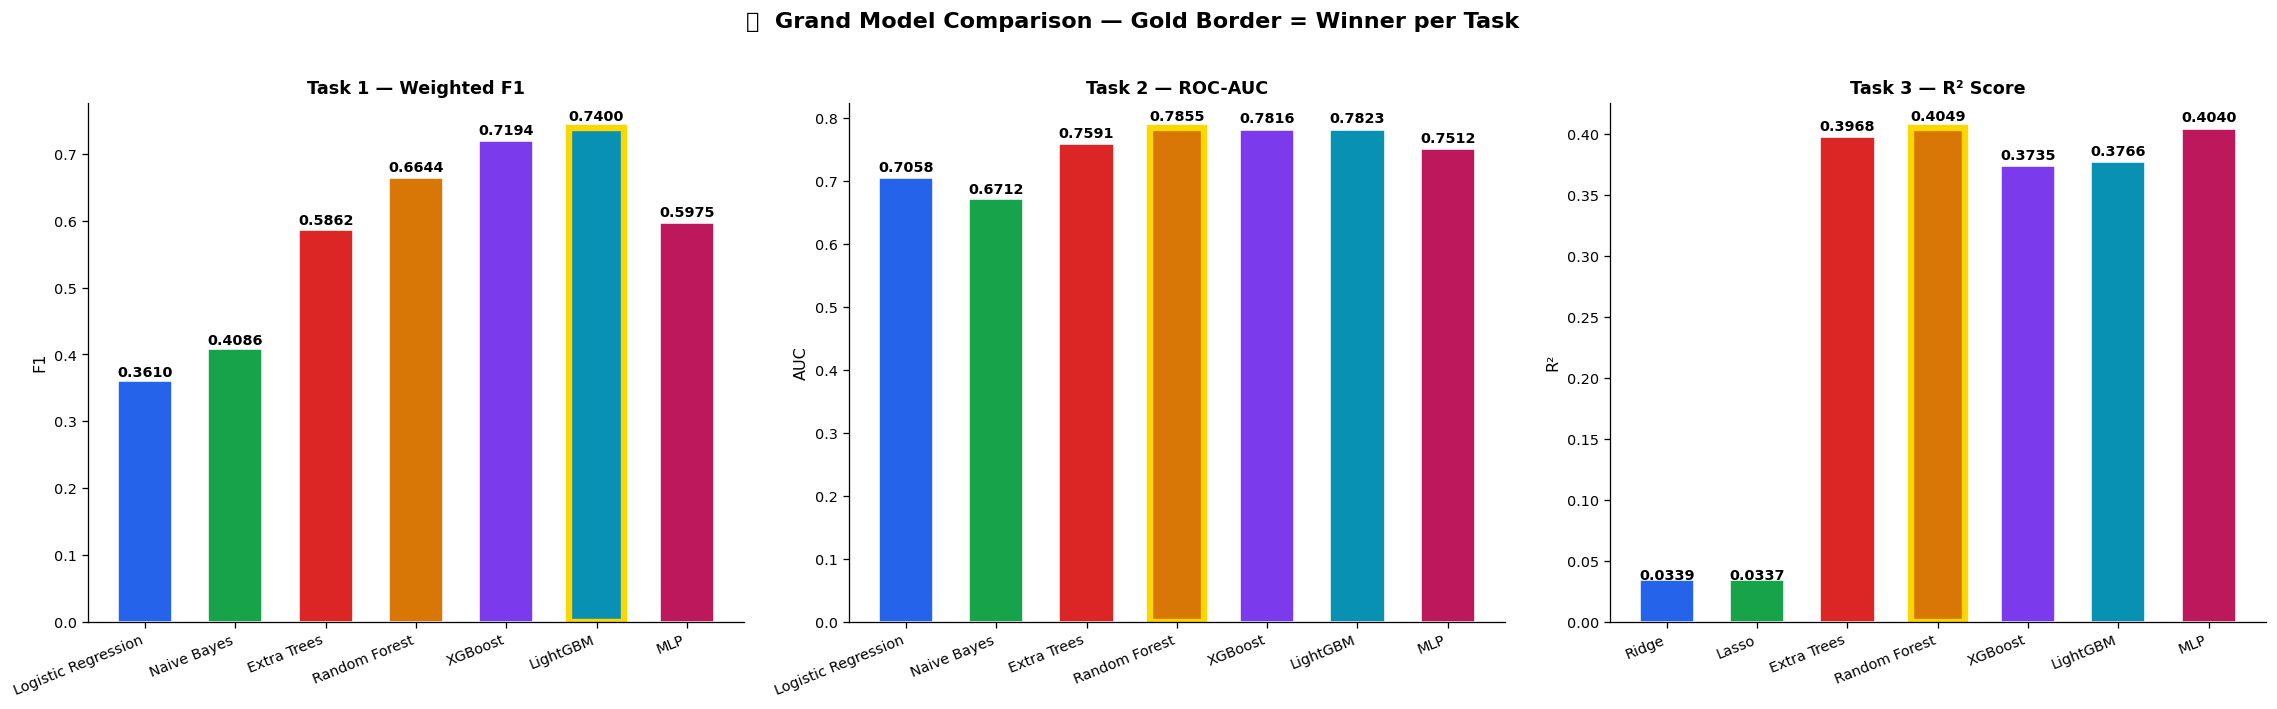

In [56]:
# ── Grand 3-panel winner chart ────────────────────────────────────────────────
def winner_bars(ax, res, metric, title, ylabel, higher=True):
    names = list(res.keys())
    vals  = [res[m].get(metric,0) for m in names]
    bars  = ax.bar(names, vals, color=PALETTE[:len(names)], edgecolor="white", width=0.6)
    best  = vals.index(max(vals) if higher else min(vals))
    bars[best].set_edgecolor("gold"); bars[best].set_linewidth(4)
    for b,v in zip(bars,vals):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()*1.015 if v>0 else 0.01,
                f"{v:.4f}", ha="center", fontsize=9, fontweight="bold")
    ax.set_title(title, fontweight="bold", fontsize=11)
    ax.set_ylabel(ylabel); ax.set_xticklabels(names, rotation=22, ha="right")

fig, axes = plt.subplots(1,3,figsize=(20,6))
winner_bars(axes[0], res_t1, "F1",  "Task 1 — Weighted F1",      "F1")
winner_bars(axes[1], res_t2, "AUC", "Task 2 — ROC-AUC",          "AUC")
if "res_t3" in dir():
    winner_bars(axes[2], res_t3, "R2","Task 3 — R² Score",        "R²")
else:
    axes[2].text(0.5,0.5,"Task 3 N/A",ha="center",va="center")

plt.suptitle("🏆  Grand Model Comparison — Gold Border = Winner per Task",
             fontweight="bold",fontsize=14,y=1.02)
plt.tight_layout(); plt.savefig("grand_winners.png",bbox_inches="tight"); plt.show()

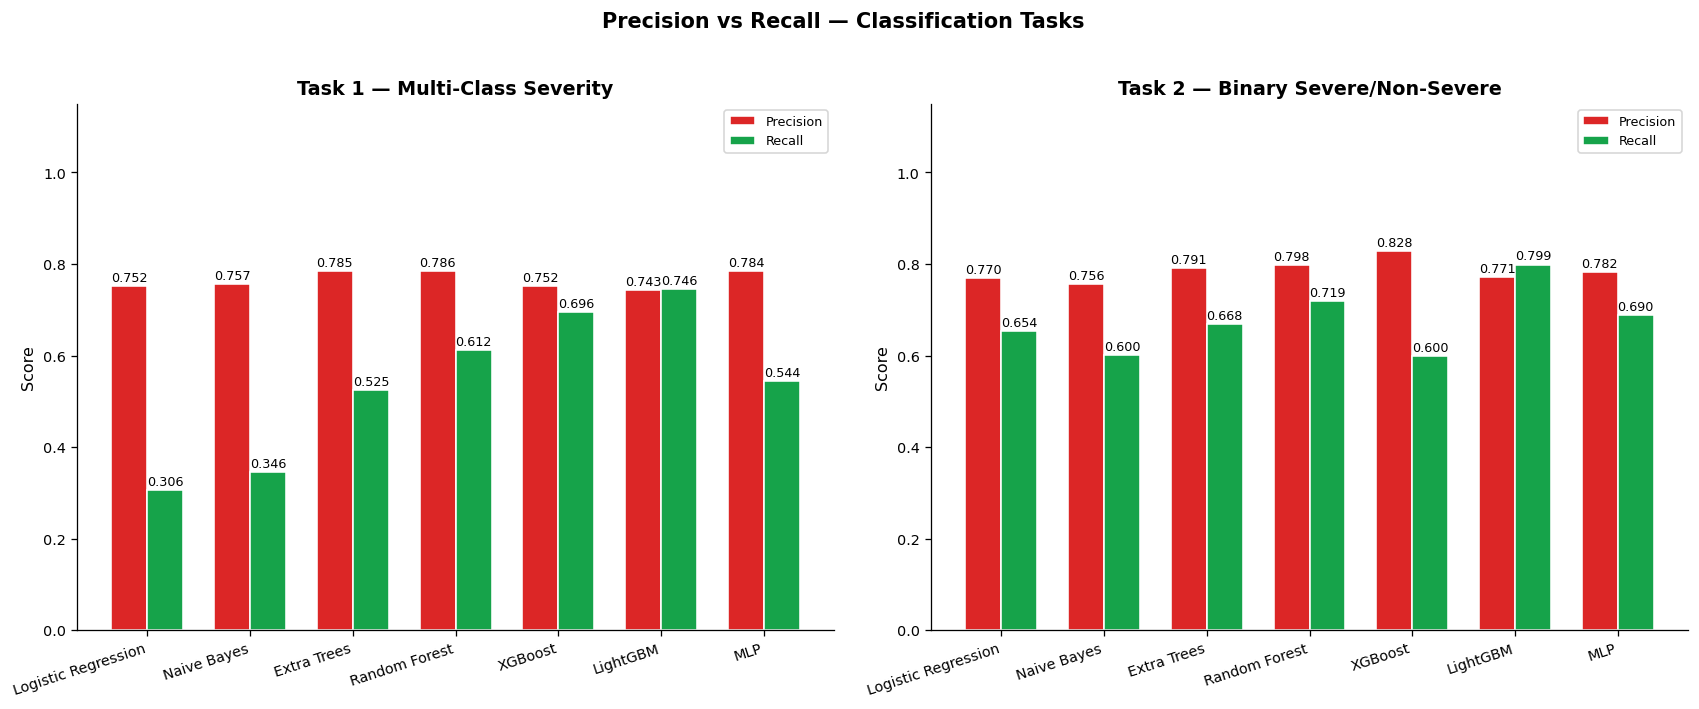

In [57]:
# ── Precision vs Recall: Tasks 1 & 2 side-by-side ────────────────────────────
fig, axes = plt.subplots(1,2,figsize=(15,6))
for ax,(res,title) in zip(axes,[
    (res_t1,"Task 1 — Multi-Class Severity"),
    (res_t2,"Task 2 — Binary Severe/Non-Severe"),
]):
    names = list(res.keys())
    x     = np.arange(len(names)); w = 0.35
    prec  = [res[m]["Precision"] for m in names]
    rec   = [res[m]["Recall"]    for m in names]
    ax.bar(x-w/2, prec, w, label="Precision", color="#DC2626", edgecolor="white")
    ax.bar(x+w/2, rec,  w, label="Recall",    color="#16A34A", edgecolor="white")
    for i,(p,r) in enumerate(zip(prec,rec)):
        ax.text(i-w/2, p+0.01, f"{p:.3f}", ha="center", fontsize=8)
        ax.text(i+w/2, r+0.01, f"{r:.3f}", ha="center", fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(names, rotation=18, ha="right")
    ax.set_ylim(0,1.15); ax.set_ylabel("Score"); ax.legend()
    ax.set_title(title, fontweight="bold")

plt.suptitle("Precision vs Recall — Classification Tasks",
             fontweight="bold",fontsize=13,y=1.02)
plt.tight_layout(); plt.savefig("grand_pr_compare.png",bbox_inches="tight"); plt.show()

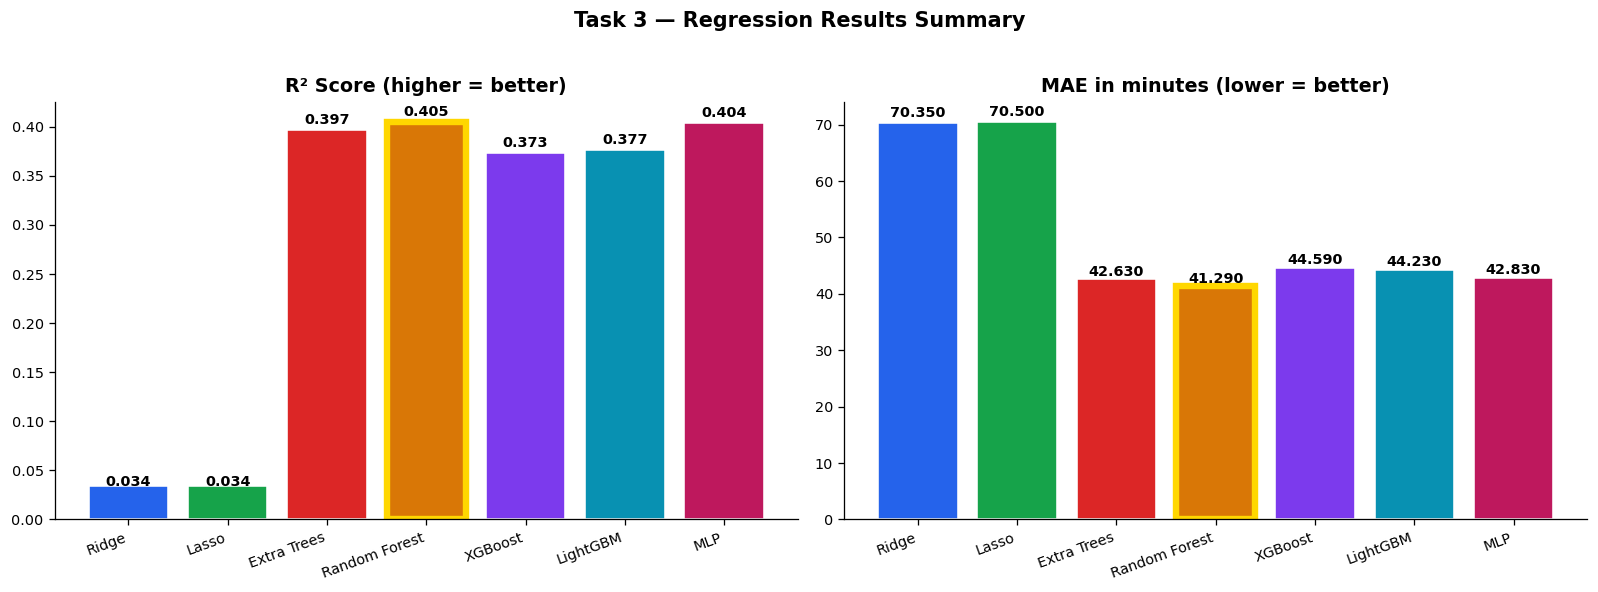

In [58]:
# ── Regression comparison: MAE & R² ─────────────────────────────────────────
if "res_t3" in dir():
    names = list(res_t3.keys())
    fig, axes = plt.subplots(1,2,figsize=(14,5))
    for ax,(metric,label,hi) in zip(axes,[
        ("R2",  "R² Score (higher = better)",   True),
        ("MAE", "MAE in minutes (lower = better)",False),
    ]):
        vals  = [res_t3[m][metric] for m in names]
        bars  = ax.bar(names, vals, color=PALETTE[:len(names)], edgecolor="white")
        best  = vals.index(max(vals) if hi else min(vals))
        bars[best].set_edgecolor("gold"); bars[best].set_linewidth(4)
        for b,v in zip(bars,vals):
            ax.text(b.get_x()+b.get_width()/2, b.get_height()*1.015,
                    f"{v:.3f}", ha="center", fontsize=9, fontweight="bold")
        ax.set_title(label, fontweight="bold")
        ax.set_xticklabels(names, rotation=20, ha="right")
    plt.suptitle("Task 3 — Regression Results Summary",
                 fontweight="bold",y=1.02,fontsize=13)
    plt.tight_layout(); plt.savefig("grand_regression.png",bbox_inches="tight"); plt.show()

In [59]:
# ── Final winners + RAM report ────────────────────────────────────────────────
best_t1 = t1_df["F1"].idxmax()
best_t2 = t2_df["AUC"].idxmax()

print("\n" + "═"*68)
print("  🏆  FINAL RESULTS SUMMARY")
print("═"*68)

print(f"\n  Task 1 — Multi-Class Severity Prediction")
print(f"  {'─'*44}")
print(f"  🥇 Best model         : {best_t1}")
print(f"     Precision (weighted): {res_t1[best_t1]['Precision']:.4f}")
print(f"     Recall    (weighted): {res_t1[best_t1]['Recall']:.4f}")
print(f"     F1        (weighted): {res_t1[best_t1]['F1']:.4f}")
print(f"     ROC-AUC             : {res_t1[best_t1]['AUC']:.4f}")
print(f"     Accuracy            : {res_t1[best_t1]['Accuracy']:.4f}")

print(f"\n  Task 2 — Binary Severe vs Non-Severe")
print(f"  {'─'*44}")
print(f"  🥇 Best model         : {best_t2}")
print(f"     Precision (weighted): {res_t2[best_t2]['Precision']:.4f}")
print(f"     Recall    (weighted): {res_t2[best_t2]['Recall']:.4f}")
print(f"     F1        (weighted): {res_t2[best_t2]['F1']:.4f}")
print(f"     ROC-AUC             : {res_t2[best_t2]['AUC']:.4f}")
print(f"     Avg Precision       : {res_t2[best_t2].get('AvgPrecision','N/A')}")

if "res_t3" in dir():
    best_t3 = t3_df["R2"].idxmax()
    print(f"\n  Task 3 — Duration Regression")
    print(f"  {'─'*44}")
    print(f"  🥇 Best model         : {best_t3}")
    print(f"     MAE               : {res_t3[best_t3]['MAE']:.2f} min")
    print(f"     RMSE              : {res_t3[best_t3]['RMSE']:.2f} min")
    print(f"     R²                : {res_t3[best_t3]['R2']:.4f}")
    print(f"     MAPE              : {res_t3[best_t3]['MAPE']:.2f}%")

import psutil, os as _os
rss = psutil.Process(_os.getpid()).memory_info().rss / 1024**2
print(f"\n  💾  Process RAM used  : {rss:.0f} MB")
print(f"  💾  df footprint      : {mem_mb(df):.0f} MB")
print("═"*68)


════════════════════════════════════════════════════════════════════
  🏆  FINAL RESULTS SUMMARY
════════════════════════════════════════════════════════════════════

  Task 1 — Multi-Class Severity Prediction
  ────────────────────────────────────────────
  🥇 Best model         : LightGBM
     Precision (weighted): 0.7434
     Recall    (weighted): 0.7460
     F1        (weighted): 0.7400
     ROC-AUC             : 0.7586
     Accuracy            : 0.7460

  Task 2 — Binary Severe vs Non-Severe
  ────────────────────────────────────────────
  🥇 Best model         : Random Forest
     Precision (weighted): 0.7985
     Recall    (weighted): 0.7185
     F1        (weighted): 0.7424
     ROC-AUC             : 0.7855
     Avg Precision       : 0.4545

  Task 3 — Duration Regression
  ────────────────────────────────────────────
  🥇 Best model         : Random Forest
     MAE               : 41.29 min
     RMSE              : 103.11 min
     R²                : 0.4049
     MAPE             